# Roman 72-Day Persistence Study



In [1]:
import argparse
import asdf
import warnings
import copy
from datetime import datetime, timedelta
import gc
import glob
import json
import logging
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
import os
from pathlib import Path
import pandas as pd
import time
from typing import Dict, List, Tuple, Optional

import astropy
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.stats import SigmaClip, sigma_clipped_stats
from astropy.table import Table
from astropy.visualization import simple_norm
from astropy.table import Column as Col

import crds
import galsim
import romanisim
from romanisim import gaia, bandpass, catalog, log, wcs, persistence, parameters, ris_make_utils as ris
from romanisim.wcs import get_wcs
import romancal
from romancal.pipeline import ExposurePipeline
import roman_datamodels as rdm
from roman_datamodels.dqflags import pixel as dqflags

from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, ApertureStats

import os
from matplotlib import gridspec


logging.getLogger().setLevel(logging.WARNING)

import warnings
import matplotlib
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
# Suppress expected ASDF warning when saving NaN values (saturated pixel replacement)
warnings.filterwarnings('ignore', message='invalid value encountered in cast', category=RuntimeWarning)

print(" All imports loaded")


 All imports loaded


In [2]:
pip install --upgrade pysiaf

  Using cached pysiaf-0.28.0-py3-none-any.whl.metadata (9.3 kB)
Using cached pysiaf-0.28.0-py3-none-any.whl (73.9 MB)
  Attempting uninstall: pysiaf
    Found existing installation: pysiaf 0.25.0
    Uninstalling pysiaf-0.25.0:
      Successfully uninstalled pysiaf-0.25.0
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install numba

  Using cached numba-0.66.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.7 kB)
  Using cached llvmlite-0.48.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.0 kB)
Using cached numba-0.66.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.9 MB)
Using cached llvmlite-0.48.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (59.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numba]32m1/2 [numba]
Note: you may need to restart the kernel to use updated packages.


In [2]:
from romanisim import parameters
print(parameters.reference_data)

{'dark': 0.01, 'darkdecaysignal': None, 'distortion': None, 'flat': None, 'gain': 2, 'inverselinearity': None, 'linearity': None, 'integralnonlinearity': None, 'readnoise': 5.0, 'saturation': 55000}


#### Step 1: Set Variables

In [3]:
#Define star magnitude for catalog creation
MAG = 11

USE_SATURATION_REMOVAL = False  # Should match Cell 4 setting


RA, DEC = 79.922971, 30.034266


# Observation parameters
OBSERVATION_PERIOD_DAYS = 0.06
CADENCE_MINUTES = 12
CADENCE_SECONDS = CADENCE_MINUTES * 60  # 720 seconds
TOTAL_TIME_SECONDS = OBSERVATION_PERIOD_DAYS * 24 * 3600
N_EXPOSURES = int(TOTAL_TIME_SECONDS / CADENCE_SECONDS)  # 8,640 exposures
#N_EXPOSURES = 12

# Simulation parameters
SCA = 1
FILTER = 'F146'
FIELD_CENTER = [267.7848, -29.7196]  # RA, Dec of boresight pointing (used with boresight=False)

# ── Galaxia background (JCZ) ─────────────────────────────────────────────
# Set True to add background stars drawn from galaxia near each field center.
# Requires joyce_table_rotated_downsampled.csv in the working directory.
galaxia        = True
GALAXIA_RADIUS = 0.005555 * u.deg   # ~20" radius — stars near field center only
GALAXIA_N      = 400                # number of background stars per exposure

# ── Field slews ──────────────────────────────────────────────────────────
# Define a list of field centers to cycle through.
# Each field is observed for EXPOSURES_PER_FIELD exposures before slewing.
# Set FIELD_CENTERS = [FIELD_CENTER] to disable slewing (single field).
EXPOSURES_PER_FIELD = 1   # one full dither cycle per field
# FIELD_CENTERS and FIELD_IDS are computed from Joyce_Table_dnu.csv
# in cell 5 using Fieldid median RA/Dec — do not set them here.
# Per JCZ: field centers come from the median ICRS position of each
# Fieldid group in Joyce's simulation file, not hardcoded coordinates.

def get_field_center(exposure_num):
    """Return the field center [RA, Dec] for a given 1-based exposure number."""
    field_idx = (exposure_num - 1) // EXPOSURES_PER_FIELD % len(FIELD_CENTERS)   #
    return FIELD_CENTERS[field_idx]

def get_field_number(exposure_num):
    """Return the 1-based field number for a given exposure."""
    return (exposure_num - 1) // EXPOSURES_PER_FIELD % len(FIELD_CENTERS) + 1
MA_TABLE = 1002
SEED = 42
BASE_TIME = '2026-10-15T00:00:00'


# Ensemble pixel configuration
N_ENSEMBLE_PIXELS = 2000  # 40×40 section for professor's analysis
ENSEMBLE_MIN_RADIUS = 00  # Closer to star (10-20 px range)
ENSEMBLE_MAX_RADIUS = 20  # 60×60 region

# Directories
#MAGNITUDE_FOLDER = f'star_mag_{MAG:.2f}'
MAGNITUDE_FOLDER = f'star_mag_mix_{MAG:.2f}'
CATALOG_FILE_NAME = f'{MAGNITUDE_FOLDER}/star_mix{MAG:.2f}.ecsv'
RESULTS_DIR = f'./{MAGNITUDE_FOLDER}/analysis_results'
TEMP_L1_DIR = f'./{MAGNITUDE_FOLDER}/temp_l1_processing'
CHECKPOINT_FILE = f'./{MAGNITUDE_FOLDER}/checkpoint.json'
MULTI_PIXEL_CSV = os.path.join(RESULTS_DIR, 'multi_pixel_resultant1_unsat.csv' if USE_SATURATION_REMOVAL else 'multi_pixel_resultant1_sat.csv')

# ── Outlier diagnostic settings ───────────────────────────────────────────
# Set False to skip outlier images + CSV for faster production runs.
SAVE_OUTLIER_DIAGNOSTIC = True



In [4]:
# ============================================================================
# Step 1b: Compute Field Centers from Joyce's File using Fieldid
# ============================================================================
# Per JCZ: use the Fieldid column already in Joyce_Table_dnu.csv.
# Each star has a Fieldid (0-5). The median ICRS RA/Dec of each group
# is the field center and slew target — no k-means needed.
#
# Verified: fieldid median centers agree with k-means to within 1–240 arcsec
# (within the detector footprint of ~450 arcsec).

import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord, Galactic
import astropy.units as u
import os

assert os.path.exists('Joyce_Table_dnu.csv'), \
    f'Joyce_Table_dnu.csv not found. CWD={os.getcwd()}'

# Load Joyce file and convert galactic → ICRS
_jraw  = pd.read_csv('Joyce_Table_dnu.csv')
_jgal  = SkyCoord(l=_jraw['Lon'].values * u.deg,
                  b=_jraw['Lat'].values * u.deg, frame=Galactic())
_jraw['ra']  = _jgal.icrs.ra.deg
_jraw['dec'] = _jgal.icrs.dec.deg

# Compute median RA/Dec per Fieldid — this is the field center
_fieldid_centers = []
for fid in sorted(_jraw['Fieldid'].unique()):
    _sub = _jraw[_jraw['Fieldid'] == fid]
    _fieldid_centers.append((
        int(fid),
        float(_sub['ra'].median()),
        float(_sub['dec'].median()),
        len(_sub)
    ))

# Sort by RA for consistent field ordering
_fieldid_centers.sort(key=lambda x: x[1])

N_FIELDS      = len(_fieldid_centers)
FIELD_CENTERS = [[round(ra, 4), round(dec, 4)]
                 for _, ra, dec, _ in _fieldid_centers]
FIELD_IDS     = [fid for fid, _, _, _ in _fieldid_centers]
FIELD_CENTER  = FIELD_CENTERS[0]

# ── Per-field galaxia catalog settings ───────────────────────────────────
# One ECSV per field: primary+check_star sources + galaxia background.
# Generated once at startup. Same random background per field every run
# (seed = field number). Main loop selects the correct catalog per field.
FIELD_CATALOG_RADIUS_DEG = 1.0 / 36.0   # ~0.0278° radius for background draw
FIELD_CATALOG_DRAW_MULT  = 10            # draw 10× background stars per field
FIELD_CATALOG_DIR        = f'{MAGNITUDE_FOLDER}/field_catalogs'
FIELD_CATALOG_FILES      = [
    f'{FIELD_CATALOG_DIR}/field_{i+1:02d}_catalog.ecsv'
    for i in range(len(FIELD_CENTERS))
]


# Fixed boresight-to-detector-center offset for SCA01
DET_OFFSET_RA  = -0.0778
DET_OFFSET_DEC = +0.0356

# Primary star at detector center of Field 1
PRIMARY_RA  = FIELD_CENTERS[0][0] + DET_OFFSET_RA
PRIMARY_DEC = FIELD_CENTERS[0][1] + DET_OFFSET_DEC

FIELD_CATALOG_FILES = [
    f'{FIELD_CATALOG_DIR}/field_{i+1:02d}_catalog.ecsv'
    for i in range(N_FIELDS)
]

# Store full table with Fieldid for catalog generation cell
_jraw_full = _jraw

print(f'Field centers from Fieldid (N={N_FIELDS}):')
for i, (fid, ra, dec, n) in enumerate(_fieldid_centers):
    print(f'  Field {i+1} (Fieldid={fid}): RA={ra:.4f}  Dec={dec:.4f}  ({n:,} stars)')
print(f'\n  PRIMARY_RA  = {PRIMARY_RA:.4f}')
print(f'  PRIMARY_DEC = {PRIMARY_DEC:.4f}')
assert abs(PRIMARY_RA - 266.0) < 2.0, f'PRIMARY_RA={PRIMARY_RA} unexpected'
assert PRIMARY_DEC < 0, f'PRIMARY_DEC={PRIMARY_DEC} unexpected'
print(f'  ✓ Coordinates verified')


Field centers from Fieldid (N=6):
  Field 1 (Fieldid=5): RA=266.6186  Dec=-29.0503  (113,589 stars)
  Field 2 (Fieldid=0): RA=267.5840  Dec=-29.9269  (87,678 stars)
  Field 3 (Fieldid=1): RA=267.7198  Dec=-29.7323  (87,882 stars)
  Field 4 (Fieldid=2): RA=268.0638  Dec=-29.2222  (87,908 stars)
  Field 5 (Fieldid=3): RA=268.3024  Dec=-28.8726  (87,069 stars)
  Field 6 (Fieldid=4): RA=268.5374  Dec=-28.5201  (86,193 stars)

  PRIMARY_RA  = 266.5408
  PRIMARY_DEC = -29.0147
  ✓ Coordinates verified


#### Step 2: Create Catalog

In [5]:
# ============================================================================
# Step 2: Create Multi-Source Catalog
# ============================================================================
# Primary star is fixed at the sensor center: RA=79.922971, Dec=30.034266
# Additional stars are placed at known pixel offsets from the primary,
# converted to sky coordinates using the same pixel scale (0.11 arcsec/px).
#
# dx > 0 → East  (PA = 90°),  dy > 0 → North (PA = 0°)
# Keep sources on-detector: SCA is 4088×4088 science pixels,
# primary is near center (~2000, 2000), so stay within ~1800 px of center.
# ============================================================================

# ------------------------------------------------------------------
# Define sources: (name, dx_pixels, dy_pixels, magnitude)
# dx/dy are pixel offsets from the primary star.
# ------------------------------------------------------------------
PIXEL_SCALE = 0.11

# Two sources only:
#   primary     — the science target
#   check_star  — very bright (MAG-5), placed 500px East of primary.
#                 Use it to verify dithering: its persistence shadow
#                 should shift by the expected dither offset each exposure.
SOURCES = [
    # name,          north_px,  east_px,  mag
    ('primary',             0,        0,  MAG),
    ('check_star',          0,      500,  MAG - 5),   # 500px East, 5 mag brighter
]

def _pixel_offset_to_skycoord(base_ra, base_dec, north_px, east_px,
                               pixel_scale_arcsec=0.11):
    """
    Convert pixel offsets (north, east) from a base sky position to SkyCoord.
    Matches JCZ convention: north_px > 0 → North (PA=0°), east_px > 0 → East (PA=90°).
    Consistent with apply_dither_offset.
    """
    if north_px == 0 and east_px == 0:
        return SkyCoord(base_ra * u.deg, base_dec * u.deg, frame='icrs')
    pixel_scale_deg = pixel_scale_arcsec / 3600.0
    separation     = np.sqrt(north_px**2 + east_px**2) * pixel_scale_deg * u.deg
    position_angle = np.degrees(np.arctan2(east_px, north_px)) * u.deg
    origin = SkyCoord(base_ra * u.deg, base_dec * u.deg, frame='icrs')
    return origin.directional_offset_by(position_angle, separation)

# Note: PRIMARY_RA/DEC is the star's sky position.
# FIELD_CENTER is the boresight pointing passed to wcs.fill_in_parameters
# with boresight=False. They do NOT need to match — romanisim places the
# SCA01 aperture reference at FIELD_CENTER, and the star at PRIMARY_RA/DEC
# projects onto the detector based on the resulting WCS.

# ── Galaxia helper (JCZ) ─────────────────────────────────────────────────
def random_radec_in_circle_astropy(center, radius, size, rng=None):
    """
    Generate random SkyCoord points uniformly within a circular region. acceptable for small circles only.

    Parameters
    ----------
    center : SkyCoord
        Center coordinate.
    radius : Quantity (angle)
        Angular radius (e.g., 1*u.deg).
    size : int
        Number of points.
    rng : np.random.Generator (optional)

    Returns
    -------
    SkyCoord
        Random coordinates inside the circle.
    """
    if rng is None:
        rng = np.random.default_rng()

    R = radius.to(u.rad).value

    # Uniform spherical cap sampling
    cos_theta = rng.uniform(np.cos(R), 1, size=size)
    theta = np.arccos(cos_theta) * u.rad

    # Random position angle
    pa = rng.uniform(0, 2*np.pi, size=size) * u.rad

    # Offset from center
    coords = center.directional_offset_by(pa, theta)

    return coords
CENTER = SkyCoord(ra=PRIMARY_RA * u.deg, dec=PRIMARY_DEC * u.deg, frame='icrs')
                                                                                                                                

# Use _jraw_full from cell 5 (already loaded and converted)
import pandas as pd
from astropy.table import Table, vstack
_raw = _jraw_full

# H-band mag → F146 flux (maggies, following JCZ overguide approach)
_raw['F146'] = 10**(-0.4 * _raw['H'])

# Morphology columns — all stars are point sources
_raw['type']              = 'PSF'
_raw['n']                 = -1
_raw['half_light_radius'] = -1
_raw['pa']                = -1
_raw['ba']                = -1

cols = ['F146', 'type', 'n', 'half_light_radius', 'pa', 'ba', 'ra', 'dec']
galaxia_tab   = Table.from_pandas(_raw[cols])
# Explicitly set column units to avoid deg² corruption in newer astropy when SkyCoord.ra.deg values are stored as Angle arrays
galaxia_tab['ra'].unit  = 'deg'
galaxia_tab['dec'].unit = 'deg'
galaxia_tab['F146'].unit = ''
galaxia_tab_n = len(galaxia_tab)

print(f"  Joyce_Table_dnu.csv loaded: {galaxia_tab_n:,} stars")
print(f"  RA range:    {galaxia_tab['ra'].min():.3f} – {galaxia_tab['ra'].max():.3f} deg")
print(f"  Dec range:   {galaxia_tab['dec'].min():.3f} – {galaxia_tab['dec'].max():.3f} deg")
print(f"  H mag range: {_raw['H'].min():.1f} – {_raw['H'].max():.1f}")

# ── Build base source rows (primary + check_star) ─────────────────────────
# These are the same in every field catalog.
base_rows = []
for name, north_px, east_px, mag in SOURCES:
    coord = _pixel_offset_to_skycoord(PRIMARY_RA, PRIMARY_DEC, north_px, east_px, PIXEL_SCALE)
    flux  = 10**(-0.4 * mag)
    base_rows.append({
        'ra':                coord.ra.deg,
        'dec':               coord.dec.deg,
        'type':              'PSF',
        'n':                 -1,
        'half_light_radius': -1,
        'pa':                -1,
        'ba':                -1,
        'F146':              flux,
    })
    print(f"  {name:12s}  RA={coord.ra.deg:.6f}  Dec={coord.dec.deg:.6f}  "
          f"mag={mag:.1f}  flux={flux:.6f}")

base_cat = Table(rows=base_rows)

# ── Generate one catalog per field ────────────────────────────────────────
# Each catalog = base sources (primary + check_star) + galaxia background.
# Background is drawn once per field with a fixed seed so it is identical
# every time the pipeline runs — same background seen in every visit.
os.makedirs(f'star_mag_mix_{MAG:.2f}', exist_ok=True)
os.makedirs(FIELD_CATALOG_DIR, exist_ok=True)

# Per JCZ: each field catalog uses REAL star positions from Joyce's file
# for stars near that field's centroid. Draw 10x with replacement.
for field_idx, field_center in enumerate(FIELD_CENTERS):
    field_num = field_idx + 1
    rng_field = np.random.default_rng(seed=field_num)
    field_id  = FIELD_IDS[field_idx]   # Fieldid from Joyce's file

    # Start with base sources
    field_cat = base_cat.copy()

    if galaxia and 'galaxia_tab' in dir():
        # Step 1: Pre-filter by Fieldid (field boundaries from simulation)
        _fid_mask = _raw['Fieldid'].values == field_id
        _galaxia_fid = galaxia_tab[_fid_mask]
        _n_fid = int(np.sum(_fid_mask))

        # Step 2: Within Fieldid group, draw from near detector center
        # Detector center = field boresight + DET_OFFSET
        _det_ra  = field_center[0] + DET_OFFSET_RA
        _det_dec = field_center[1] + DET_OFFSET_DEC
        _center  = SkyCoord(ra=_det_ra * u.deg, dec=_det_dec * u.deg,
                            frame='icrs')
        _fid_coords = SkyCoord(
            ra=np.array(_galaxia_fid['ra'].tolist()) * u.deg,
            dec=np.array(_galaxia_fid['dec'].tolist()) * u.deg,
            frame='icrs'
        )
        _seps      = _center.separation(_fid_coords).deg
        _in_radius = _seps <= FIELD_CATALOG_RADIUS_DEG
        _n_radius  = int(np.sum(_in_radius))

        if _n_radius == 0:
            # Fallback: draw from full Fieldid group
            _pool = _galaxia_fid
            print(f"  Field {field_num:02d} (Fieldid={field_id}): "
                  f"no stars in radius — using full group ({_n_fid:,} stars)")
        else:
            _pool = _galaxia_fid[_in_radius]
            print(f"  Field {field_num:02d} (Fieldid={field_id}): "
                  f"{_n_radius:,} stars within {FIELD_CATALOG_RADIUS_DEG:.4f}° "
                  f"of detector center (from {_n_fid:,} in Fieldid group)")

        # Draw 10x from the field pool with replacement (real positions)
        # Cap draw at GALAXIA_N * FIELD_CATALOG_DRAW_MULT
        # Using full Fieldid group (87k stars) would be 870k sources — too many
        n_draw   = len(_pool) * FIELD_CATALOG_DRAW_MULT
        draw_idx = rng_field.choice(len(_pool), size=n_draw, replace=True)
        bg_tab   = _pool[draw_idx].copy()
        print(f"    Drew {n_draw:,} background stars "
              f"(Fieldid={field_id}, within {FIELD_CATALOG_RADIUS_DEG:.4f}°)")
        # Real RA/Dec from Joyce — no position reassignment
        
        coord_rnd = random_radec_in_circle_astropy(_center, FIELD_CATALOG_RADIUS_DEG*u.deg, n_draw, np.random.default_rng(seed=field_id))
        bg_tab['ra'] = coord_rnd.ra
        bg_tab['dec'] = coord_rnd.dec
        # Ensure ra/dec units are plain deg after vstack
        bg_tab['ra'].unit  = 'deg'
        bg_tab['dec'].unit = 'deg'
        print(field_id)
        print(bg_tab['ra'])
        field_cat = vstack([field_cat, bg_tab])
        field_cat['ra'].unit  = 'deg'
        field_cat['dec'].unit = 'deg'
    else:
        print(f"  Field {field_num:02d}: science sources only (galaxia=False)")

    out_path = FIELD_CATALOG_FILES[field_idx]
    field_cat.write(out_path, format='ascii.ecsv', overwrite=True)
    print(f"    → {out_path}  ({len(field_cat)} total rows)")

# Also write base catalog for backwards compatibility
base_cat.write(CATALOG_FILE_NAME, format='ascii.ecsv', overwrite=True)
print(f"\n  Base catalog ({len(base_cat)} sources) → {CATALOG_FILE_NAME}")
print(f"  {len(FIELD_CENTERS)} field catalogs written to {FIELD_CATALOG_DIR}/")


  Joyce_Table_dnu.csv loaded: 550,319 stars
  RA range:    266.278 – 268.887 deg
  Dec range:   -30.231 – -28.225 deg
  H mag range: 11.2 – 25.2
  primary       RA=266.540800  Dec=-29.014700  mag=11.0  flux=0.000040
  check_star    RA=266.558270  Dec=-29.014699  mag=6.0  flux=0.003981
  Field 01 (Fieldid=5): 963 stars within 0.0278° of detector center (from 113,589 in Fieldid group)
    Drew 9,630 background stars (Fieldid=5, within 0.0278°)
5
        ra        
       deg        
------------------
266.55343090592197
 266.5299192829826
 266.5629138794572
 266.5472413943589
266.53715734061257
266.55691459229473
266.56521723371816
 266.5336994239875
 266.5655274100602
               ...
 266.5626189850605
 266.5655253138008
 266.5459538879841
266.52932977426684
 266.5140697662322
266.55931755344665
266.57126564235887
 266.5311206845604
266.54662242584203
   266.51318013625
Length = 9630 rows
    → star_mag_mix_11.00/field_catalogs/field_01_catalog.ecsv  (9632 total rows)
  Field 02 (Fie

## Global Configuration

In [6]:
parameters.read_pattern[1002] = [
    [1],
    [2],
    [3, 4],
    [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
    [18, 19, 20, 21],
    [22]
]  # 6 resultants, 22 frames total                    # Resultant 5: 1 read


RESULTANT_TIMES = {
    0: 3.16247,   # JCZ changed these
    1: 6.32494,
    2: 12.64988,
    3: 53.762,
    4: 66.41188,
    5: 69.57435
}



# PERSISTENCE MODELING: Each exposure uses the previous L1 file to model
# detector persistence effects. The pipeline automatically passes the previous
# L1 file to romanisim for accurate persistence simulation across the time series.

# Output CSV files
L1_METRICS_CSV = os.path.join(RESULTS_DIR, f'l1_metrics_Mag_{MAG:.2f}.csv')
PHOTOMETRY_CSV = os.path.join(RESULTS_DIR, f'Photometry_Mag_{MAG:.2f}.csv')
PERSISTENCE_CSV = os.path.join(RESULTS_DIR, f'persistence_Mag_{MAG:.2f}.csv')
MULTI_PIXEL_CSV = os.path.join(RESULTS_DIR, 'multi_pixel_resultant1_unsat.csv' if USE_SATURATION_REMOVAL else 'multi_pixel_resultant1_sat.csv')

PIXELS_TO_TRACK = []  # Will be populated dynamically



# Source positions for photometry
# source_positions will be set dynamically after auto-detection
source_positions = []  # Will be populated during L2 processing

# ============================================================================
# PHOTOMETRIC CALIBRATION CONSTANTS
# ============================================================================

# Roman WFI F146 filter parameters
PIXEL_SCALE = 0.11  # arcsec/pixel
PHOTFLAM = 3.0151335e-20  # erg/cm^2/Angstrom/electron for F146
PHOTPLAM = 14539.0  # Pivot wavelength in Angstroms for F146
ZERO_POINT_AB = 28.08  # AB magnitude zero point for F146

# Conversion factor: DN to Jy
COUNTS_TO_JY = PIXEL_SCALE**2 * PHOTFLAM * PHOTPLAM / 3.34e4

# source_x/source_y are set dynamically each exposure via WCS projection.
# This fallback is only used if WCS projection fails.
source_y, source_x = 2044, 2044   # fallback — near detector center
peak_value = 55000
# Calibration constants
RESULTANT0_TIME = 3.16247
photmjsr = 0.240393
pixel_area = 2.8083e-13
photfnu = photmjsr * 1e6 * pixel_area

print(" Photometric constants loaded")


print(" Global configuration loaded")

 Photometric constants loaded
 Global configuration loaded


## Step 3: Load Functions

In [7]:
def get_asdf_file(file_path):
    """Open ASDF file."""
    return asdf.open(file_path, 'rb')

def get_roman_dm_file(file_path):
    """Open file with roman_datamodels."""
    with asdf.open(file_path, 'rb') as fb:
        f = rdm.open(fb).copy()
    return f

def get_metadata(file_path):
    """Extract metadata from file."""
    f = get_roman_dm_file(file_path)
    return f.meta

def get_data(file_path):
    """Extract data array from file."""
    f = get_roman_dm_file(file_path)
    return f.data

def get_data_quality_section(file_path):
    """Extract DQ array from file."""
    f = get_roman_dm_file(file_path)
    return f.dq

def get_list_of_asdf_files(directory):
    """Get list of ASDF files in directory, sorted by creation time."""
    dir_path = Path(directory)
    if not dir_path.is_dir():
        raise NotADirectoryError(f"{directory} is not a valid directory.")
    
    asdf_files = list(dir_path.glob('*.asdf'))
    asdf_files.sort(key=lambda x: os.path.getctime(x))
    return asdf_files

def plot_resultants_for_pixel(file, pixel_x, pixel_y):
    """Plot up-the-ramp samples for a specific pixel."""
    plt.figure(figsize=(6, 6), layout='tight')
    plt.title(f'Up-the-ramp samples for pixel {pixel_x}, {pixel_y}')
    plt.plot(file['data'][:, pixel_x, pixel_y])
    plt.xlabel('Resultant number', fontsize=16)
    plt.ylabel('Pixel value [DN]', fontsize=16)
    plt.show()

def get_saturated_pixel_count(file_path):
    """Get number of saturated pixels from DQ flags."""
    f = get_asdf_file(file_path)
    # L1 files do not have data quality flags
    if f['romanisim']['level'] == 1:
        return None
    bit = 1  # Saturation bit
    definition = str(dqflags(bit)).split('.')[1]
    n_pix = np.sum(np.bool_(f['dq'].flatten() & (1 << bit)))
    print(f'Bit value {bit} corresponds to {definition}')
    print(f'Number of {definition} pixels: {n_pix:,} ({n_pix / f["dq"].size:.2%})')
    return n_pix

def get_exposure_metadata(file_path):
    """Extract exposure metadata."""
    f = get_roman_dm_file(file_path)
    return f.meta.exposure

def get_exposure_start_time(file_path):
    """Get exposure start time."""
    f = get_roman_dm_file(file_path)
    start_time = Time(f.meta.exposure.start_time, format='isot', scale='utc')
    return start_time

def get_exposure_end_time(file_path):
    """Get exposure end time."""
    f = get_roman_dm_file(file_path)
    end_time = Time(f.meta.exposure.end_time, format='isot', scale='utc')
    return end_time

def get_effective_exposure_time(file_path):
    """Get effective exposure time."""
    f = get_roman_dm_file(file_path)
    effective_exposure_time = f.meta.exposure.effective_exposure_time * u.s
    return effective_exposure_time

def get_exposure_time(file_path):
    """Get exposure time."""
    f = get_roman_dm_file(file_path)
    exposure_time = f.meta.exposure.exposure_time * u.s
    return exposure_time

def get_frame_time(file_path):
    """Get frame time."""
    f = get_roman_dm_file(file_path)
    frame_time = f.meta.exposure.frame_time * u.s
    return frame_time

def get_number_of_resultants(file_path):
    """Get number of resultants."""
    f = get_roman_dm_file(file_path)
    return f.meta.exposure.nresultants

def get_dq_saturated_pixels(file_path):
    """Get DQ saturated pixels."""
    f = get_roman_dm_file(file_path)
    return f.pixels

def get_catalog(file_name):
    """Load catalog from file."""
    catalog = Table.read(file_name, format="ascii.ecsv")
    return catalog

def galactic_to_equatorial(l, b):
    """
    Convert galactic coordinates to equatorial (RA, Dec).
    
    Parameters:
    -----------
    l : float or array
        Galactic longitude in degrees
    b : float or array
        Galactic latitude in degrees
    
    Returns:
    --------
    ra, dec : float or array
        Right Ascension and Declination in degrees
    """
    l = np.asarray(l, dtype=float)
    b = np.asarray(b, dtype=float)
    
    valid_mask = np.isfinite(l) & np.isfinite(b)
    
    if not np.any(valid_mask):
        raise ValueError("No valid galactic coordinates found")
    
    coord = SkyCoord(l * u.degree, b * u.degree, frame='galactic')
    equatorial = coord.icrs
    
    return equatorial.ra.degree, equatorial.dec.degree

#### Ensemble Selection

In [8]:
def select_ensemble_pixels(star_y, star_x, max_radius=20, image_size=4088, **kwargs):
    """
    Return all pixels within max_radius of the star position.
    Returns list of pixel dicts with 'name', 'y', 'x', 'description'
    """
    pixels = []
    r2 = max_radius**2
    idx = 0

    # Define bounding box around star
    y_min = max(0, int(star_y - max_radius))
    y_max = min(image_size, int(star_y + max_radius + 1))
    x_min = max(0, int(star_x - max_radius))
    x_max = min(image_size, int(star_x + max_radius + 1))
    print(y_min)
    print(y_max)
    print(x_min)
    print(x_max)
    for y in range(y_min, y_max):
        for x in range(x_min, x_max):
            dy = y - star_y
            dx = x - star_x

            #if dy*dy + dx*dx <= r2: # JCZ take the whole square not a circle
            if True:
                distance = np.sqrt(dy*dy + dx*dx)
                pixels.append({
                    'name': f'psf_wing_{idx:06d}',
                    'y': y,
                    'x': x,
                    'description': f'{distance:.1f}px from center'
                })
                idx += 1

    return pixels

####  MULTI-RESULTANT CSV FILES

In [9]:
def get_multi_pixel_csv_files(results_dir, use_saturation_removal=True):
    """Get CSV file paths for all resultants."""
    mode = "unsat" if use_saturation_removal else "sat"
    csv_files = {}
    
    for resultant in range(len(RESULTANT_TIMES)): 
        filename = f'multi_pixel_resultant{resultant}_{mode}.csv'
        csv_files[resultant] = os.path.join(results_dir, filename)
    
    return csv_files

MULTI_PIXEL_CSV_FILES = get_multi_pixel_csv_files(RESULTS_DIR, USE_SATURATION_REMOVAL)
SINGLE_PIXEL_CSV = os.path.join(RESULTS_DIR, 'single_pixel_resultant1.csv')



#### INTERMEDIATE DATA EXTRACTION CONFIGURATION


In [10]:
# Enable/disable extraction of intermediate file data
EXTRACT_JUMPS = False         # DISABLED for speed
EXTRACT_WCS = False           # DISABLED for speed
EXTRACT_RAMP_QUALITY = False  # Ramp fit quality (Optional)
EXTRACT_DQ_FLAGS = False      # DQ flags summary (Optional)

print(" Intermediate data extraction configured")
print(f"  Jump detection: {EXTRACT_JUMPS}")
print(f"  WCS astrometry: {EXTRACT_WCS}")
print(f"  Ramp quality: {EXTRACT_RAMP_QUALITY}")
print(f"  DQ flags: {EXTRACT_DQ_FLAGS}")


 Intermediate data extraction configured
  Jump detection: False
  WCS astrometry: False
  Ramp quality: False
  DQ flags: False


#### ROMAN L1 GENERATION FUNCTION

#### GBTDS Dither Pattern


In [11]:
# ============================================================================
# GBTDS DITHER PATTERN UTILITIES
# ============================================================================
# Reference: GBTDS_DITHER_PLANING.pdf, Table 1
#
# 64 unique dither offsets, each held for 6 consecutive exposures.
# Pattern repeats every 384 exposures.
# Pixel scale: 0.11 arcsec/pixel.
#
# Verified anchors:
#   offset  1 → (0.000, 0.000)   exposures  1–6
#   offset  2 → (4.500, 0.000)   exposures  7–12
#   offset  3 → (0.000, 4.500)   exposures 13–18
#   offset 64 → (7.875, 7.875)   last offset in cycle

_DITHER_TABLE = np.array([
    [0.000, 0.000],  # offset  1
    [4.500, 0.000],  # offset  2
    [0.000, 4.500],  # offset  3
    [4.500, 4.500],  # offset  4
    [2.250, 0.000],  # offset  5
    [6.750, 0.000],  # offset  6
    [2.250, 4.500],  # offset  7
    [6.750, 4.500],  # offset  8
    [0.000, 2.250],  # offset  9
    [4.500, 2.250],  # offset 10
    [0.000, 6.750],  # offset 11
    [4.500, 6.750],  # offset 12
    [2.250, 2.250],  # offset 13
    [6.750, 2.250],  # offset 14
    [2.250, 6.750],  # offset 15
    [6.750, 6.750],  # offset 16
    [1.125, 0.000],  # offset 17
    [5.625, 0.000],  # offset 18
    [1.125, 4.500],  # offset 19
    [5.625, 4.500],  # offset 20
    [3.375, 0.000],  # offset 21
    [7.875, 0.000],  # offset 22
    [3.375, 4.500],  # offset 23
    [7.875, 4.500],  # offset 24
    [1.125, 2.250],  # offset 25
    [5.625, 2.250],  # offset 26
    [1.125, 6.750],  # offset 27
    [5.625, 6.750],  # offset 28
    [3.375, 2.250],  # offset 29
    [7.875, 2.250],  # offset 30
    [3.375, 6.750],  # offset 31
    [7.875, 6.750],  # offset 32
    [0.000, 1.125],  # offset 33
    [4.500, 1.125],  # offset 34
    [0.000, 5.625],  # offset 35
    [4.500, 5.625],  # offset 36
    [2.250, 1.125],  # offset 37
    [6.750, 1.125],  # offset 38
    [2.250, 5.625],  # offset 39
    [6.750, 5.625],  # offset 40
    [0.000, 3.375],  # offset 41
    [4.500, 3.375],  # offset 42
    [0.000, 7.875],  # offset 43
    [4.500, 7.875],  # offset 44
    [2.250, 3.375],  # offset 45
    [6.750, 3.375],  # offset 46
    [2.250, 7.875],  # offset 47
    [6.750, 7.875],  # offset 48
    [1.125, 1.125],  # offset 49
    [5.625, 1.125],  # offset 50
    [1.125, 5.625],  # offset 51
    [5.625, 5.625],  # offset 52
    [3.375, 1.125],  # offset 53
    [7.875, 1.125],  # offset 54
    [3.375, 5.625],  # offset 55
    [7.875, 5.625],  # offset 56
    [1.125, 3.375],  # offset 57
    [5.625, 3.375],  # offset 58
    [1.125, 7.875],  # offset 59
    [5.625, 7.875],  # offset 60
    [3.375, 3.375],  # offset 61
    [7.875, 3.375],  # offset 62
    [3.375, 7.875],  # offset 63
    [7.875, 7.875],  # offset 64
])

assert len(_DITHER_TABLE) == 64
assert tuple(_DITHER_TABLE[0])  == (0.000, 0.000), 'Offset 1 should be (0,0)'
assert tuple(_DITHER_TABLE[1])  == (4.500, 0.000), 'Offset 2 should be (4.5,0)'
assert tuple(_DITHER_TABLE[2])  == (0.000, 4.500), 'Offset 3 should be (0,4.5)'
assert tuple(_DITHER_TABLE[8])  == (0.000, 2.250), 'Offset 9 should be (0,2.25)'
assert tuple(_DITHER_TABLE[63]) == (7.875, 7.875), 'Offset 64 should be (7.875,7.875)'
assert len(set(map(tuple, _DITHER_TABLE))) == 64, 'All 64 offsets must be unique'

EXPOSURES_PER_DITHER = 6
N_DITHER_OFFSETS     = 64
DITHER_CYCLE_LENGTH  = EXPOSURES_PER_DITHER * N_DITHER_OFFSETS  # 384


def get_dither_offset(exposure_num):
    """Return (north_px, east_px) for a 1-based exposure number.
    col0 of dither table = North offset (moves Dec, Y pixels)
    col1 of dither table = East offset  (moves RA,  X pixels)
    """
    zero_based   = (exposure_num - 1) % DITHER_CYCLE_LENGTH
    offset_index = zero_based // EXPOSURES_PER_DITHER
    north_px, east_px = _DITHER_TABLE[offset_index]
    return float(north_px), float(east_px)


def apply_dither_offset(base_ra, base_dec, north_px, east_px,
                        pixel_scale_arcsec=0.11):
    """
    Shift boresight by (north_px, east_px) pixels.
    north_px > 0 → North (PA=0°, increases Dec)
    east_px  > 0 → East  (PA=90°, increases RA)
    """
    if north_px == 0.0 and east_px == 0.0:
        return base_ra, base_dec
    pixel_scale_deg = pixel_scale_arcsec / 3600.0
    separation     = np.sqrt(north_px**2 + east_px**2) * pixel_scale_deg * u.deg
    position_angle = np.degrees(np.arctan2(east_px, north_px)) * u.deg
    origin  = SkyCoord(base_ra * u.deg, base_dec * u.deg, frame='icrs')
    shifted = origin.directional_offset_by(position_angle, separation)
    return float(shifted.ra.deg), float(shifted.dec.deg)

def get_dithered_pointing(base_ra, base_dec, exposure_num,
                          pixel_scale_arcsec=0.11):
    """Return dithered (RA, Dec) for a given 1-based exposure number."""
    dx, dy = get_dither_offset(exposure_num)
    return apply_dither_offset(base_ra, base_dec, dx, dy, pixel_scale_arcsec)


# --- test ---
assert get_dither_offset(1)   == (0.0, 0.0)
assert get_dither_offset(7)   == (4.5, 0.0)
assert get_dither_offset(13)  == (0.0, 4.5)
assert get_dither_offset(385) == get_dither_offset(1), 'pattern must repeat every 384'
print(" Dither utilities loaded — all checks passed")


 Dither utilities loaded — all checks passed


In [12]:
def run_romanisim_simulationapi(
    catalog_file,
    filter_name='F146',
    sca=1,
    level=1,
    exposure_params=None,
    pointing=(270.0, -30.0),
    date='2026-06-15T12:00:00',
    output_directory='./L1_simulation_files',
    output_suffix="",
    previous_file=None,
    usecrds=True
):
    """Generate Roman L1 simulation file using romanisim."""
    
    detector = f'WFI{sca:02d}'
    output_filename = f"{output_directory}/roman_sim_{filter_name}_{detector}_L{level}{output_suffix}.asdf"
    
    # Get parameters from exposure_params dict
    ma_table_number = exposure_params.get('ma_table_number', 1002) if exposure_params else 1002
    seed = exposure_params.get('seed', 7) if exposure_params else 7
    
    # Set up argument parser (no add_args - not needed)
    parser = argparse.ArgumentParser()
    parser.set_defaults(
        usecrds=usecrds, 
        stpsf=True, 
        webbpsf=None,# kept for backward compat — new romanisim does  ('del args.webbpsf' internally; needs to exist)
        level=level, 
        filename=output_filename, 
        drop_extra_dq=True, 
        sca=sca, 
        bandpass=filter_name, 
        pretend_spectral=None
    )
    
    args = parser.parse_args([])
    
    # Set reference files to None for CRDS
    #for k in parameters.reference_data:
        #parameters.reference_data[k] = None
    
    # Set Galsim RNG object
    rng = galsim.UniformDeviate(seed)
    
    # Set persistence information
    if previous_file and os.path.exists(previous_file):
        persist = persistence.Persistence.read(previous_file)
    else:
        persist = persistence.Persistence()
    
    # Set metadata using romanisim's helper
    metadata = ris.set_metadata(
        date=date, 
        bandpass=filter_name, 
        sca=sca, 
        ma_table_number=ma_table_number, # JCZ adding this directly because otherwise it is not working by just giving ma_table_number
        usecrds=usecrds
    )
    
    # Update the WCS info
    # Use explicit import to avoid 'WCS instance has no fill_in_parameters'
    # error that occurs when wcs is shadowed by a WCS instance object.
    from romanisim.wcs import fill_in_parameters as _fill_in_parameters
    _fill_in_parameters(
        metadata,
        SkyCoord(pointing[0], pointing[1], unit='deg', frame='icrs'),
        boresight=False,
        pa_aper=0.0
    )
    
    # Load catalog
    cat = astropy.table.Table.read(catalog_file)
    # romanisim 0.13.1 trim_objlist does 'ra * u.deg' internally.
    # If the column already has unit='deg', this gives deg² → crash.
    # Fix: strip units from ra/dec so they are plain unitless floats.


    cat['ra']  = Col(np.array(cat['ra'],  dtype=float))
    cat['dec'] = Col(np.array(cat['dec'], dtype=float))
    # JCZ
    # adding in the read pattern directly
    # Read pattern from parameters.read_pattern — single source of truth
    metadata['exposure']['read_pattern'] = parameters.read_pattern[ma_table_number]
    print(f"  Using MA table {ma_table_number}: "
          f"{len(parameters.read_pattern[ma_table_number])} resultants")
    # Galaxia background is pre-baked into the per-field catalog at
    # generation time (cell 5). No on-the-fly draw needed here.
    # Run the simulation
    ris.simulate_image_file(args, metadata, cat, rng, persist)
    
    return output_filename

print(" L1 generation function loaded")

 L1 generation function loaded


#### ROMAN L1 RESULTANT ANALYZER CLASS

In [13]:
class RomanL1ResultantAnalyzer:
    """
    Analyzer for individual resultants in Roman L1 files with proper MA table handling.
    Full implementation from Master notebook.
    """
    
    def __init__(self, l1_file_path: str):
        """
        Initialize with L1 file path.
        
        Parameters:
        -----------
        l1_file_path : str
            Path to L1 ASDF file
        """
        self.file_path = l1_file_path
        self.model = None
        
        # Data containers
        self.ramp_data = None  # (resultants, y, x)
        self.ref_pixels = None
        self.resultants = {}
        self.exposure_metadata = {}
        
        # MA table and timing information
        self.ma_table_info = {}
        self.read_pattern = []
        self.resultant_times = None
        self.frame_times = None
        
        # Processed data
        self.slopes = None
        self.slope_errors = None
        self.corrected_ramp = None
        self.saturation_mask = None
        
        # Read noise per detector (actual Roman WFI values)
        # These are the measured read noise values for each WFI detector
        self.sca_read_noise = {
            'WFI01': 17.49, 'WFI02': 14.20, 'WFI03': 14.70, 'WFI04': 15.76,
            'WFI05': 13.64, 'WFI06': 13.65, 'WFI07': 13.21, 'WFI08': 12.49,
            'WFI09': 12.39, 'WFI10': 15.75, 'WFI11': 13.94, 'WFI12': 13.73,
            'WFI13': 16.17, 'WFI14': 13.46, 'WFI15': 13.46, 'WFI16': 13.49,
            'WFI17': 12.64, 'WFI18': 12.42,
        }
        
        # Exposure time from MA table
        self.exposure_time = None
    
    def load_l1_file(self):
        """Load the L1 file and extract comprehensive metadata."""
        print(f"Loading L1 file: {self.file_path}")
        
        self.model = rdm.open(str(self.file_path))
        self.ramp_data = self.model.data
        
        # Extract detailed exposure metadata
        meta = self.model.meta
        exposure = meta.exposure
        
        self.exposure_metadata = {
            'type': exposure.type,
            'start_time': exposure.start_time,
            'mid_time': exposure.mid_time,
            'end_time': exposure.end_time,
            'nresultants': exposure.nresultants,
            'frame_time': exposure.frame_time,
            'exposure_time': exposure.exposure_time,
            'effective_exposure_time': exposure.effective_exposure_time,
            'ma_table_name': exposure.ma_table_name,
            'ma_table_number': exposure.ma_table_number,
            'truncated': exposure.truncated,
            'data_problem': exposure.data_problem,
            'detector': meta.instrument.detector,
            'optical_element': meta.instrument.optical_element,
            'read_noise': self.sca_read_noise.get(meta.instrument.detector, 5.0)
        }
        
        # Store exposure time
        self.exposure_time = exposure.exposure_time
        
        # Extract the actual read pattern (MA table structure)
        self.read_pattern = exposure.read_pattern
        

        print(f"Found MA table read pattern with {len(self.read_pattern)} resultants")
        
        # Process the MA table information
        self._process_ma_table()

        # Override metadata exposure_time with the value derived from the read
        # pattern. romanisim writes frame_time as 2× the true single-frame time,
        # making exposure.exposure_time 2× too large (139s instead of 69.57s).
        # resultant_times[-1] is correct: last_frame_number × true_frame_time.
        if self.resultant_times is not None and len(self.resultant_times) > 0:
            self.exposure_time = float(self.resultant_times[-1])

        print(f"Loaded ramp data: {self.ramp_data.shape}")
        print(f"MA table {self.exposure_metadata.get('ma_table_number', '?')}: "
              f"{len(self.read_pattern)} resultants")
    
    def _process_ma_table(self):
        """Process the MA table read pattern to understand timing."""
        frame_time = self.exposure_metadata['frame_time']
        
        # Calculate timing for each resultant based on the read pattern
        self.resultant_times = []
        self.frame_times = []
        
        for i, read_group in enumerate(self.read_pattern):
            # Each read_group is a list of frame numbers
            if len(read_group) > 0:
                last_frame_number = max(read_group)
                resultant_time = last_frame_number * frame_time
                
                self.resultant_times.append(resultant_time)
                self.frame_times.append(read_group)
                
                print(f"  Resultant {i}: frames {read_group}, time = {resultant_time:.2f}s")
        
        self.resultant_times = np.array(self.resultant_times)
        
        # Store MA table analysis
        self.ma_table_info = {
            'total_frames': max([max(group) for group in self.read_pattern if group]),
            'total_time': self.resultant_times[-1] if len(self.resultant_times) > 0 else 0,
            'resultant_count': len(self.read_pattern),
            'frame_time': frame_time
        }
        
        print(f"  MA table: {self.ma_table_info['total_frames']} frames, "
              f"{self.ma_table_info['total_time']:.2f}s total")

    def extract_all_resultants(self):
        """Extract individual resultant arrays with proper MA table context."""
        print("Extracting individual resultants with MA table context...")

        for i in range(self.exposure_metadata["nresultants"]):
            resultant_name = f"resultant_{i:02d}"
            self.resultants[resultant_name] = self.ramp_data[i, :, :].copy()
            
            # Get information about this resultant from MA table
            if i < len(self.read_pattern):
                read_group = self.read_pattern[i]
                n_frames_averaged = len(read_group) 
                resultant_time = self.resultant_times[i] if i < len(self.resultant_times) else 0
            else:
                n_frames_averaged = 1
                resultant_time = 0
            
            # Basic statistics
            valid_mask = np.isfinite(self.resultants[resultant_name])
            if np.any(valid_mask):
                mean_val = np.mean(self.resultants[resultant_name][valid_mask])
                median_val = np.median(self.resultants[resultant_name][valid_mask])
                print(f"  {resultant_name}: time={resultant_time:.2f}s, "
                           f"frames_avg={n_frames_averaged}, "
                           f"mean={mean_val:.1f} DN, median={median_val:.1f} DN")
        
        print(f"Extracted {len(self.resultants)} resultants")
        return self.resultants

    
    def casertano_weighted_fit(self, times, counts, read_noise=10.0):
        """
        Implement Casertano (2022) optimal weighting scheme.
        
        Adapts weighting based on signal-to-noise ratio:
        - Low S/N: Equal weighting (read noise dominated)
        - High S/N: Endpoints only (Poisson dominated)
        - Intermediate: Smooth transition
        """
        N = len(times)
        if N < 2:
            return 0.0, np.inf
        
        # Convert to float64 to prevent overflow
        counts = np.asarray(counts, dtype=np.float64)
        times = np.asarray(times, dtype=np.float64)
        
        # Calculate signal-to-noise ratio
        S_max = counts[-1] - counts[0]
        if S_max <= 0:
            S_max = np.abs(counts[-1] - counts[0]) + 1.0
        
        S = S_max / np.sqrt(read_noise**2 + S_max)
        
        # Calculate optimal weights based on S/N
        weights = self.calculate_casertano_weights(times, S, read_noise)
        
        # Apply weighted least squares
        W = weights
        t_bar = times - times[0]  # Relative times
        
        # Auxiliary sums (Casertano method)
        F0 = np.sum(W)
        F1 = np.sum(W * t_bar)
        F2 = np.sum(W * t_bar**2)
        
        D = F0 * F2 - F1**2
        if abs(D) < 1e-15:
            return 0.0, np.inf
        
        # Coefficients and slope calculation
        K = (F0 * t_bar - F1) / D
        slope = np.sum(K * counts)
        
        # Calculate uncertainty
        tau = times - times[0]
        V_S = np.sum(K**2 * tau) + np.sum([2 * K[i] * K[j] * t_bar[i] 
                                        for i in range(N) for j in range(i+1, N)])
        V_R = np.sum(K**2) * read_noise**2
        V_total = V_S * abs(slope) + V_R
        slope_error = np.sqrt(max(V_total, 0))
        
        return slope, slope_error
    
    def calculate_casertano_weights(self, times, S, read_noise):
        """
        Calculate optimal weights based on S/N ratio.
        
        Parameters:
        -----------
        S : float
            Signal-to-noise ratio
        
        Returns:
        --------
        weights : array
            Optimal weights for each resultant
        """
        N = len(times)
        
        # Low S/N: equal weighting (read noise dominated)
        if S < 0.1:
            return np.ones(N)
        
        # High S/N: first and last samples only (Poisson dominated)
        elif S > 10.0:
            weights = np.zeros(N)
            weights[0] = 1.0   # First
            weights[-1] = 1.0  # Last
            return weights
        
        # Intermediate S/N: smooth transition
        else:
            equal_weights = np.ones(N)
            endpoint_weights = np.zeros(N)
            endpoint_weights[0] = 1.0
            endpoint_weights[-1] = 1.0
            
            # Sigmoid transition parameter
            alpha = 1.0 / (1.0 + np.exp(-2 * (S - 2)))
            weights = (1 - alpha) * equal_weights + alpha * endpoint_weights
            
            return weights
    
    def reference_pixel_correction(self, method='median_subtract'):
        """Apply reference pixel correction using 4-pixel border."""
        # Convert to float64 for calculations
        self.corrected_ramp = self.ramp_data.astype(np.float64)
        
        if method == 'none':
            return
        
        for i in range(self.corrected_ramp.shape[0]):
            resultant = self.corrected_ramp[i, :, :]
            
            # Extract reference pixels from 4-pixel border
            ref_pixels = np.concatenate([
                resultant[:4, :].flatten(),      # Top 4 rows
                resultant[-4:, :].flatten(),     # Bottom 4 rows
                resultant[4:-4, :4].flatten(),   # Left 4 cols
                resultant[4:-4, -4:].flatten()   # Right 4 cols
            ])
            
            valid_ref = ref_pixels[np.isfinite(ref_pixels)]
            
            if len(valid_ref) > 0:
                if method == 'median_subtract':
                    correction = np.median(valid_ref)
                else:  # mean_subtract
                    correction = np.mean(valid_ref)
                
                # Apply correction to science region
                self.corrected_ramp[i, 4:-4, 4:-4] -= correction
    
    def fit_up_the_ramp_slopes(self, method='casertano', read_noise=10.0):
        """
        Fit slopes using Casertano optimal weighting.
        
        This is the Master notebook's full implementation.
        """
        data_to_fit = self.corrected_ramp if self.corrected_ramp is not None else self.ramp_data.astype(np.float64)
        ny, nx = data_to_fit.shape[1:]
        self.slopes = np.zeros((ny, nx))
        self.slope_errors = np.zeros((ny, nx))
        
        print(f"Fitting slopes with Casertano weighting (read_noise={read_noise:.1f} DN)...")
        
        for y in range(ny):
            for x in range(nx):
                times = self.resultant_times
                counts = data_to_fit[:, y, x]
                
                # Use Casertano optimal weighting
                slope, error = self.casertano_weighted_fit(times, counts, read_noise)
                
                self.slopes[y, x] = slope
                self.slope_errors[y, x] = error
        
        return self.slopes, self.slope_errors




#### Pixel Saturation

In [14]:
def get_saturated_pixels_and_neighbors(data, threshold): # Not used - no saturation replacement
    """
    Get saturated pixels and their 8 neighbors (FAST VECTORIZED - MASTER LOGIC).
    
    Matches Master notebook behavior:
    - Finds core saturated pixels
    - Adds 8 neighbors (3×3 box)
    - Prints core count like Master
    
    Parameters:
    -----------
    data : np.ndarray
        2D image data
    threshold : float
        Saturation threshold in DN
    
    Returns:
    --------
    saturated_pixels : list of tuples
        List of (y, x) coordinates including neighbors
    """
    from scipy import ndimage
    
    # Find core saturated pixels (vectorized - FAST!)
    saturated_mask = data >= threshold
    pixel_count = np.sum(saturated_mask)  # Core count
    
    if pixel_count == 0:
        print(f'  Core saturated pixels: 0')
        print(f'  Total with neighbors: 0')
        return []
    
    # Dilate to include 8 neighbors (vectorized - FAST!)
    structure = np.array([[1, 1, 1],
                         [1, 1, 1],
                         [1, 1, 1]], dtype=bool)
    
    dilated_mask = ndimage.binary_dilation(saturated_mask, structure=structure)
    
    # Convert mask to list of coordinates
    coords = np.where(dilated_mask)
    saturated_pixels = list(zip(coords[0], coords[1]))
    
    # Print like Master notebook
    print(f'  Core saturated pixels: {pixel_count}')
    print(f'  Total with neighbors: {len(saturated_pixels)}')
    
    return saturated_pixels

def replace_saturated_pixels(data, indices, replacement_value=np.nan): # Not used - no saturation replacement
    """
    Replace saturated pixels with specified value.
    
    From Master notebook - typically replaces with NaN for clean photometry.
    
    Parameters:
    -----------
    data : 2D array
        Data to modify
    indices : list of tuples
        Pixel coordinates to replace
    replacement_value : float
        Value to use (default: np.nan)
#    
    Returns:
    --------
    modified_data : 2D array
        Data with saturated pixels replaced
    """
    modified_data = data.copy()
    for index in indices:
        modified_data[index] = replacement_value
    
    return modified_data



def update_unsaturated_resultant(file_name, resultants_data): # Not used - no saturation replacement
    """
    Updates all resultants in the L1 file at once.
    
    From Master notebook - replaces saturated pixels in L1 BEFORE pipeline.
    
    Parameters:
    -----------
    file_name : str
        Path to the L1 ASDF file
    resultants_data : list of 2D arrays
        Modified resultant data, one for each resultant
    """
    with rdm.open(file_name) as model:
        new_model = model.copy()
        for i, data in enumerate(resultants_data):
            new_model.data[i, :, :] = data
        new_model.save(file_name.replace('.asdf', '_unsat.asdf'))
        return file_name.replace('.asdf', '_unsat.asdf')



In [15]:
def get_saturated_pixels_from_dq_with_neighbors(dq_array, saturation_threshold=55000):
    """
    Get saturated pixels from DQ flags OR threshold, with neighbors.
    
    Combines DQ flag method with threshold check for robustness.
    
    Parameters:
    -----------
    dq_array : 2D array
        DQ flags from L2
    saturation_threshold : float
        DN threshold for saturation (default 65000)
    
    Returns:
    --------
    coords : list of tuples
        Saturated pixel coordinates with neighbors
    n_core : int
        Core saturated pixels
    """
    from scipy import ndimage
    
    # Get saturated from DQ bit 1
    saturated_bit = 1
    saturated_mask = (dq_array & (1 << saturated_bit)) > 0
    
    n_core = np.sum(saturated_mask)
    
    # Dilate to include neighbors
    structure = np.ones((3, 3), dtype=bool)
    expanded_mask = ndimage.binary_dilation(saturated_mask, structure=structure)
    
    # Convert to coordinates
    coords = list(zip(*np.where(expanded_mask)))
    
    return coords, n_core


In [16]:
def save_exposure_diagnostic(file_num, l1_filepath, l2_filepath, wcs_positions,
                              magnitude_folder, results_dir):
    """
    Save a diagnostic image for a single exposure.
    Saved to: {results_dir}/diagnostic_exp_{file_num:04d}.png
    """
    import matplotlib
    matplotlib.use('Agg')  # non-interactive backend — no display needed
    import matplotlib.pyplot as plt

    out_path = os.path.join(results_dir,
                            f'diagnostic_exp_{file_num:04d}.png')

    try:
        # ── Load L1 resultant 0 ───────────────────────────────────────────
        with asdf.open(l1_filepath) as af:
            r0 = af['roman']['data'][0].astype(np.float64)

        n_src  = len(wcs_positions)
        n_cols = max(n_src, 1)
        fig    = plt.figure(figsize=(5 * (n_cols + 1), 10))
        ax_full = fig.add_subplot(2, 1, 1)
        ax_cuts = [fig.add_subplot(2, n_cols, n_cols + i + 1)
                   for i in range(n_cols)]

        # ── Full image ────────────────────────────────────────────────────
        _finite   = r0[np.isfinite(r0)]
        vmin_full = float(np.nanpercentile(_finite, 50))
        vmax_full = float(np.nanpercentile(_finite, 99.9))
        ax_full.imshow(r0, cmap='viridis', origin='lower',
                       vmin=vmin_full, vmax=vmax_full)
        colors = plt.cm.Set1(np.linspace(0, 0.8, max(n_src, 1)))
        for i, (px, py, ra, dec, mag) in enumerate(wcs_positions):
            name = SOURCES[i][0] if i < len(SOURCES) else f'src{i+1}'
            ax_full.plot(px, py, '.', color=colors[i], markersize=14,
                         label=f'{name} ({px:.0f},{py:.0f})')
        ax_full.set_title(
            f'L1 Resultant 0 — Exp {file_num:04d}  '
            f'Field {get_field_number(file_num)}/{len(FIELD_CENTERS)}',
            fontsize=12)
        ax_full.set_xlabel('X (pixels)')
        ax_full.set_ylabel('Y (pixels)')
        ax_full.legend(fontsize=8, loc='upper right')

        # ── Per-source cutouts ────────────────────────────────────────────
        CUTOUT_HALF = 40
        for i, (px, py, ra, dec, mag) in enumerate(wcs_positions):
            ax   = ax_cuts[i]
            name = SOURCES[i][0] if i < len(SOURCES) else f'src{i+1}'
            cx, cy = int(round(px)), int(round(py))
            x0 = max(0, cx - CUTOUT_HALF); x1 = min(r0.shape[1], cx + CUTOUT_HALF)
            y0 = max(0, cy - CUTOUT_HALF); y1 = min(r0.shape[0], cy + CUTOUT_HALF)
            cutout = r0[y0:y1, x0:x1]
            if cutout.size == 0:
                ax.set_title(f'{name} — off detector')
                continue
            vmin_c = float(np.nanpercentile(cutout, 10))
            vmax_c = float(np.nanpercentile(cutout, 99.9))
            imc = ax.imshow(cutout, cmap='viridis', origin='lower',
                            vmin=vmin_c, vmax=vmax_c)
            ax.plot(px - x0, py - y0, 'r+', markersize=14, markeredgewidth=1.5)
            ax.set_title(
                f'{name}  mag={mag:.1f}\n'
                f'({cx},{cy})  peak={np.nanmax(cutout):.0f} DN',
                fontsize=9)
            ax.set_xlabel('X (px)')
            ax.set_ylabel('Y (px)')
            plt.colorbar(imc, ax=ax, label='DN', fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.savefig(out_path, dpi=120, bbox_inches='tight')
        plt.close(fig)
        print(f"  Diagnostic saved: {os.path.basename(out_path)}")

    except Exception as e:
        print(f"  Diagnostic failed for exp {file_num}: {e}")
        plt.close('all')

#### Single Pixel Variance withing One File

In [17]:
# ============================================================================
# ORIGINAL VARIANCE FUNCTIONS (across resultants within ONE file)
# ============================================================================

def calculate_single_pixel_variance(analyzer, pixel_y, pixel_x):
    """
    Calculate variance of a single pixel across all resultants.
    
    Parameters:
    -----------
    analyzer : RomanL1ResultantAnalyzer
        The analyzer object containing the ramp data
    pixel_y : int
        Y coordinate of pixel
    pixel_x : int
        X coordinate of pixel
    
    Returns:
    --------
    variance : float
        Variance of the pixel values across all resultants
    pixel_data : dict
        Dictionary containing pixel values for each resultant
    """
    
    pixel_data = {}
    values = []
    
    # Extract value for each resultant
    for i in range(analyzer.ramp_data.shape[0]):
        value = analyzer.ramp_data[i, pixel_y, pixel_x]
        pixel_data[f'resultant_{i}'] = value
        if np.isfinite(value):  # Exclude NaN/inf values
            values.append(value)
    
    # Calculate variance
    variance = np.var(values) if len(values) > 0 else np.nan
    
    return variance, pixel_data


def plot_single_pixel_with_variance(analyzer, pixel_y, pixel_x, filename=None):
    """Plot DN value vs resultant for a single pixel and show variance."""
    
    variance, pixel_data = calculate_single_pixel_variance(analyzer, pixel_y, pixel_x)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    resultants = range(len(pixel_data))
    values_list = [pixel_data[f'resultant_{i}'] for i in resultants]
    
    # Plot 1: DN vs Resultant number
    ax1.plot(resultants, values_list, 'o-', markersize=8)
    ax1.set_xlabel('Resultant Number')
    ax1.set_ylabel('DN Value')
    ax1.set_title(f'Pixel [{pixel_y}, {pixel_x}] - DN vs Resultant\nVariance = {variance:.2f} DN²')
    ax1.grid(True, alpha=0.3)
    
    # Add mean line
    mean_val = np.nanmean(values_list)
    ax1.axhline(mean_val, color='red', linestyle='--', alpha=0.5, label=f'Mean = {mean_val:.2f}')
    ax1.legend()
    
    # Plot 2: DN vs Time
    if analyzer.resultant_times is not None:
        ax2.plot(analyzer.resultant_times, values_list, 'o-', markersize=8)
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('DN Value')
        ax2.set_title(f'Pixel [{pixel_y}, {pixel_x}] - DN vs Time\nVariance = {variance:.2f} DN²')
        ax2.grid(True, alpha=0.3)
        ax2.axhline(mean_val, color='red', linestyle='--', alpha=0.5, label=f'Mean = {mean_val:.2f}')
        ax2.legend()
    
    # Add filename to suptitle if provided
    if filename:
        fig.suptitle(filename, y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    return variance, pixel_data

def plot_multiple_pixels_variance(analyzer, pixel_coords, filename=None):
    """
    Plot DN values for multiple pixels and compare their variances.
    
    Parameters:
    -----------
    analyzer : RomanL1ResultantAnalyzer
    pixel_coords : list of tuples
        List of (y, x) coordinates to plot
    filename : str, optional
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    variances = {}
    
    for pixel_y, pixel_x in pixel_coords:
        variance, pixel_data = calculate_single_pixel_variance(analyzer, pixel_y, pixel_x)
        resultants = range(len(pixel_data))
        values_list = [pixel_data[f'resultant_{i}'] for i in resultants]
        
        label = f'[{pixel_y}, {pixel_x}] (var={variance:.2f})'
        variances[(pixel_y, pixel_x)] = variance
        
        # Plot 1: DN vs Resultant
        ax1.plot(resultants, values_list, 'o-', label=label, markersize=6, alpha=0.7)
        
        # Plot 2: DN vs Time
        if analyzer.resultant_times is not None:
            ax2.plot(analyzer.resultant_times, values_list, 'o-', label=label, markersize=6, alpha=0.7)
    
    ax1.set_xlabel('Resultant Number')
    ax1.set_ylabel('DN Value')
    ax1.set_title('Multiple Pixels - DN vs Resultant')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    if analyzer.resultant_times is not None:
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('DN Value')
        ax2.set_title('Multiple Pixels - DN vs Time')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    if filename:
        fig.suptitle(filename, y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    print("\nPixel Variances:")
    for coords, var in variances.items():
        print(f"  Pixel {coords}: {var:.2f} DN²")
    
    return variances

#### Source Detection

In [18]:
from photutils.detection import DAOStarFinder

def detect_source_position(data, search_radius=500, central_region=True):
    """
    Detect the brightest source in the image (primary star).
    Returns the position of the single brightest peak — used for ensemble
    pixel selection and as a fallback when DAOStarFinder finds nothing.
    """
    if central_region:
        cy, cx = data.shape[0] // 2, data.shape[1] // 2
        y0 = max(0, cy - search_radius)
        y1 = min(data.shape[0], cy + search_radius)
        x0 = max(0, cx - search_radius)
        x1 = min(data.shape[1], cx + search_radius)
        region = data[y0:y1, x0:x1]
        max_val = np.nanmax(region)
        loc = np.where(region == max_val)
        return y0 + loc[0][0], x0 + loc[1][0], max_val
    else:
        max_val = np.nanmax(data)
        loc = np.where(data == max_val)
        return loc[0][0], loc[1][0], max_val


def detect_all_sources(data, fwhm=3.0, threshold_sigma=10.0,
                        bkg_inner_r=60, bkg_outer_r=120,
                        max_sources=20):
    """
    Detect point sources in the image using DAOStarFinder.
    Returns positions sorted brightest-first so index 0 is always
    the primary star.

    The background sigma is estimated from an annulus well outside the
    bright primary PSF (bkg_inner_r to bkg_outer_r pixels from image
    centre), avoiding the PSF wings and diffraction rings that would
    otherwise inflate the threshold and cause thousands of false detections.

    Parameters
    ----------
    data : np.ndarray
        2D calibrated (L2) slope image.
    fwhm : float
        Expected PSF FWHM in pixels (~1.5–2.5 for Roman WFI F146).
    threshold_sigma : float
        Detection threshold in background sigma units.
        Use >= 10 for Roman slope images to avoid PSF-wing false positives.
    bkg_inner_r : int
        Inner radius (pixels) of the background estimation annulus.
        Must be beyond the bright star's PSF wings (~50 px for mag 20).
    bkg_outer_r : int
        Outer radius (pixels) of the background estimation annulus.
    max_sources : int
        Cap on returned sources — guards against runaway detections.

    Returns
    -------
    list of (x, y) tuples in photutils order, brightest first.
    Falls back to the single-brightest-peak method if nothing is found.
    """
    ny, nx = data.shape
    cy, cx = ny // 2, nx // 2

    # --- Background estimation from an annulus around image centre ---
    yy, xx = np.ogrid[:ny, :nx]
    r = np.sqrt((xx - cx)**2 + (yy - cy)**2)
    bkg_mask = (r >= bkg_inner_r) & (r < bkg_outer_r) & np.isfinite(data)

    if bkg_mask.sum() < 100:
        # Annulus empty (tiny image or all NaN) — fall back to global stats
        finite_data = data[np.isfinite(data)]
        if finite_data.size == 0:
            return []
        _, median, std = sigma_clipped_stats(finite_data)
    else:
        _, median, std = sigma_clipped_stats(data[bkg_mask])

    if std <= 0:
        sy, sx, _ = detect_source_position(data)
        return [(float(sx), float(sy))]

    # --- Run DAOStarFinder on background-subtracted image ---
    daofind = DAOStarFinder(fwhm=fwhm, threshold=threshold_sigma * std)
    sources = daofind(data - median)

    if sources is None or len(sources) == 0:
        sy, sx, _ = detect_source_position(data)
        return [(float(sx), float(sy))]

    sources.sort('peak')
    sources.reverse()

    if len(sources) > max_sources:
        print(f"  WARNING: DAOStarFinder found {len(sources)} sources — "
              f"capped at {max_sources}. Consider raising threshold_sigma.")
        sources = sources[:max_sources]

    return [(float(row['xcentroid']), float(row['ycentroid'])) for row in sources]


def catalog_to_pixel_positions(catalog_file, wcs_obj, image_shape):
    """
    Project catalog sky coordinates through the L2 WCS to pixel positions.
    Returns exactly one position per catalog source — no false positives.

    Parameters
    ----------
    catalog_file : str  — path to the ECSV catalog
    wcs_obj      : gwcs.WCS from l2_model.meta.wcs
    image_shape  : (ny, nx) — filters sources off the detector

    Returns
    -------
    list of (x_pix, y_pix, ra_deg, dec_deg, mag) tuples
    """
    from astropy.table import Table as _Table
    cat = _Table.read(catalog_file)
    ny, nx = image_shape
    positions = []
    for row in cat:
        ra_deg  = float(row['ra'])
        dec_deg = float(row['dec'])
        mag     = -2.5 * np.log10(float(row['F146'])) if float(row['F146']) > 0 else np.nan
        try:
            # Roman gWCS requires a SkyCoord, not separate ra/dec floats
            _coord  = SkyCoord(ra_deg * u.deg, dec_deg * u.deg, frame='icrs')
            _result = wcs_obj.world_to_pixel(_coord)
            if hasattr(_result, '__len__') and len(_result) == 2:
                x_pix, y_pix = float(_result[0]), float(_result[1])
            else:
                x_pix, y_pix = float(_result.x), float(_result.y)
            if 0 <= x_pix < nx and 0 <= y_pix < ny:
                positions.append((x_pix, y_pix, ra_deg, dec_deg, mag))
        except Exception as e:
            print(f"  WCS projection failed for RA={ra_deg:.4f}: {e}")
    return positions


print(" Source detection functions loaded — detect_source_position, detect_all_sources, catalog_to_pixel_positions")


 Source detection functions loaded — detect_source_position, detect_all_sources, catalog_to_pixel_positions


#### Pixel Tracking variance

In [19]:
# ============================================================================
# SINGLE PIXEL RESULTANT 1 VARIANCE TRACKING
# ============================================================================

def calculate_single_pixel_resultant1(analyzer, pixel_y, pixel_x):
    """
    Extract the value of a single pixel at RESULTANT 1 ONLY.
    
    Parameters:
    -----------
    analyzer : RomanL1ResultantAnalyzer
        The analyzer object containing the ramp data
    pixel_y : int
        Y coordinate of pixel
    pixel_x : int
        X coordinate of pixel
    
    Returns:
    --------
    resultant1_value : float
        Pixel value at resultant 1 (DN)
    """
    # Resultant 1 is at index 0
    resultant1_value = analyzer.ramp_data[0, pixel_y, pixel_x]
    
    return resultant1_value


def save_pixel_resultant1_to_csv(file_number, pixel_y, pixel_x, resultant1_value, 
                                  csv_filename, timestamp_sec=None):
    """
    Save single pixel resultant 1 data to CSV file.
    
    Parameters:
    -----------
    file_number : int
        Current file number being processed
    pixel_y : int
        Y coordinate of pixel
    pixel_x : int
        X coordinate of pixel
    resultant1_value : float
        Pixel value at resultant 1 (DN)
    csv_filename : str
        Path to CSV file
    timestamp_sec : float, optional
        Timestamp in seconds
    """
    # Create data dictionary
    data = {
        'file_number': file_number,
        'pixel_y': pixel_y,
        'pixel_x': pixel_x,
        'resultant_DN': resultant1_value,
        'timestamp_sec': timestamp_sec if timestamp_sec is not None else file_number
    }
    
    # Append to CSV
    df = pd.DataFrame([data])
    
    # Check if file exists to determine if we need header
    file_exists = os.path.exists(csv_filename)
    df.to_csv(csv_filename, mode='a', header=not file_exists, index=False)


def dn_to_jy(dn_values, photfnu):
    """Convert DN to Janskys."""
    return np.array(dn_values) * photfnu


def jy_to_magnitude(jy_values, ZERO_POINT_AB):
    """Convert Janskys to AB magnitudes."""
    jy_values = np.array(jy_values)
    with np.errstate(divide='ignore', invalid='ignore'):
        magnitudes = -2.5 * np.log10(jy_values) + ZERO_POINT_AB 
    return magnitudes


def plot_single_pixel_resultant1_variance(csv_filename, output_dir='./analysis_results',
                                          photfnu = None, mag_zero_point = None):
    """
    Plot single pixel resultant 1 variance in DN, Jy, and Magnitude.
    Run this AFTER your pipeline completes.
    """
    # Fall back to globals if not provided
    if output_dir is None:
        output_dir = RESULTS_DIR
    if photfnu is None:
        photfnu = photmjsr * 1e6 * PIXEL_AREA
    if mag_zero_point is None:
        mag_zero_point = ZERO_POINT_AB

    
    # Load data
    if not os.path.exists(csv_filename):
        print(f" ERROR: CSV file not found: {csv_filename}")
        return
    
    df = pd.read_csv(csv_filename)
    
    if df.empty:
        print(f" ERROR: CSV file is empty: {csv_filename}")
        return
    
    print(f" Loaded {len(df)} measurements from {csv_filename}")
    
    # Get pixel coordinates
    pixel_y = df['pixel_y'].iloc[0]
    pixel_x = df['pixel_x'].iloc[0]
    
    # Extract data
    file_numbers = df['file_number'].values
    dn_values = df['resultant_DN'].values
    
    # Convert to Jy and Magnitude
    jy_values = dn_to_jy(dn_values, photfnu)
    mag_values = jy_to_magnitude(jy_values, mag_zero_point)
    
    # Calculate statistics
    dn_mean = np.mean(dn_values)
    dn_std = np.std(dn_values)
    dn_var = np.var(dn_values)
    
    jy_mean = np.mean(jy_values)
    jy_std = np.std(jy_values)
    jy_var = np.var(jy_values)
    
    mag_mean = np.mean(mag_values[np.isfinite(mag_values)])
    mag_std = np.std(mag_values[np.isfinite(mag_values)])
    mag_var = np.var(mag_values[np.isfinite(mag_values)])
    
    # Create figure with 3 rows, 3 columns
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    fig.suptitle(f'Single Pixel Resultant 1 Variance Analysis\n' + 
                 f'Pixel ({pixel_y}, {pixel_x}) - {len(df)} Exposures',
                 fontsize=16, fontweight='bold', y=0.995)
    
    # ROW 1: DN
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax1.plot(file_numbers, dn_values, 'b-', linewidth=1, alpha=0.6)
    ax1.plot(file_numbers, dn_values, 'bo', markersize=3, alpha=0.5)
    ax1.axhline(dn_mean, color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {dn_mean:.2f} DN')
    ax1.fill_between(file_numbers, dn_mean - dn_std, dn_mean + dn_std,
                      alpha=0.2, color='red', label=f'±1σ = {dn_std:.2f} DN')
    ax1.set_xlabel('File Number', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Resultant 1 Value (DN)', fontsize=11, fontweight='bold')
    ax1.set_title(f'DN Time Series - Variance = {dn_var:.2f} DN²', 
                  fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9)
    
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.hist(dn_values, bins=30, color='blue', alpha=0.7, edgecolor='black', 
             orientation='horizontal')
    ax2.axhline(dn_mean, color='red', linestyle='--', linewidth=2)
    ax2.set_ylabel('DN Value', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Frequency', fontsize=11, fontweight='bold')
    ax2.set_title('DN Distribution', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # ROW 2: Flux
    ax3 = fig.add_subplot(gs[1, 0:2])
    ax3.plot(file_numbers, jy_values, 'g-', linewidth=1, alpha=0.6)
    ax3.plot(file_numbers, jy_values, 'go', markersize=3, alpha=0.5)
    ax3.axhline(jy_mean, color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {jy_mean:.2e} Jy')
    ax3.fill_between(file_numbers, jy_mean - jy_std, jy_mean + jy_std,
                      alpha=0.2, color='red', label=f'±1σ = {jy_std:.2e} Jy')
    ax3.set_xlabel('File Number', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Flux (Jy)', fontsize=11, fontweight='bold')
    ax3.set_title(f'Flux Time Series - Variance = {jy_var:.2e} Jy²', 
                  fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=9)
    ax3.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.hist(jy_values, bins=30, color='green', alpha=0.7, edgecolor='black', 
             orientation='horizontal')
    ax4.axhline(jy_mean, color='red', linestyle='--', linewidth=2)
    ax4.set_ylabel('Flux (Jy)', fontsize=11, fontweight='bold')
    ax4.set_xlabel('Frequency', fontsize=11, fontweight='bold')
    ax4.set_title('Flux Distribution', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    # ROW 3: Magnitude
    ax5 = fig.add_subplot(gs[2, 0:2])
    finite_mask = np.isfinite(mag_values)
    ax5.plot(file_numbers[finite_mask], mag_values[finite_mask], 'r-', 
             linewidth=1, alpha=0.6)
    ax5.plot(file_numbers[finite_mask], mag_values[finite_mask], 'ro', 
             markersize=3, alpha=0.5)
    ax5.axhline(mag_mean, color='blue', linestyle='--', linewidth=2, 
                label=f'Mean = {mag_mean:.3f} mag')
    ax5.fill_between(file_numbers[finite_mask], mag_mean - mag_std, mag_mean + mag_std,
                      alpha=0.2, color='blue', label=f'±1σ = {mag_std:.3f} mag')
    ax5.set_xlabel('File Number', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Magnitude (AB)', fontsize=11, fontweight='bold')
    ax5.set_title(f'Magnitude Time Series - Variance = {mag_var:.4f} mag²', 
                  fontsize=12, fontweight='bold')
    ax5.invert_yaxis()
    ax5.grid(True, alpha=0.3)
    ax5.legend(fontsize=9)
    
    ax6 = fig.add_subplot(gs[2, 2])
    ax6.hist(mag_values[finite_mask], bins=30, color='red', alpha=0.7, 
             edgecolor='black', orientation='horizontal')
    ax6.axhline(mag_mean, color='blue', linestyle='--', linewidth=2)
    ax6.set_ylabel('Magnitude (AB)', fontsize=11, fontweight='bold')
    ax6.set_xlabel('Frequency', fontsize=11, fontweight='bold')
    ax6.set_title('Magnitude Distribution', fontsize=12, fontweight='bold')
    ax6.invert_yaxis()
    ax6.grid(True, alpha=0.3, axis='y')
    
    # Save plot
    os.makedirs(output_dir, exist_ok=True)
    output_file = os.path.join(output_dir, 
                               f'single_pixel_resultant1_variance_y{pixel_y}_x{pixel_x}.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\n Saved plot: {output_file}")
    
    output_file_pdf = output_file.replace('.png', '.pdf')
    plt.savefig(output_file_pdf, dpi=300, bbox_inches='tight')
    print(f" Saved PDF: {output_file_pdf}")
    
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print("SINGLE PIXEL RESULTANT 1 VARIANCE SUMMARY")
    print("="*70)
    print(f"Pixel: ({pixel_y}, {pixel_x})")
    print(f"Number of exposures: {len(df)}")
    print(f"\nDN (Data Numbers):")
    print(f"  Mean:     {dn_mean:.3f} DN")
    print(f"  Std Dev:  {dn_std:.3f} DN")
    print(f"  Variance: {dn_var:.3f} DN²")
    print(f"  Range:    {np.min(dn_values):.3f} - {np.max(dn_values):.3f} DN")
    print(f"  CV:       {(dn_std/dn_mean*100):.2f}%")
    print(f"\nFlux (Janskys):")
    print(f"  Mean:     {jy_mean:.3e} Jy")
    print(f"  Std Dev:  {jy_std:.3e} Jy")
    print(f"  Variance: {jy_var:.3e} Jy²")
    print(f"  CV:       {(jy_std/jy_mean*100):.2f}%")
    print(f"\nMagnitude (AB):")
    print(f"  Mean:     {mag_mean:.4f} mag")
    print(f"  Std Dev:  {mag_std:.4f} mag")
    print(f"  Variance: {mag_var:.6f} mag²")
    print(f"  Range:    {np.min(mag_values[finite_mask]):.4f} - {np.max(mag_values[finite_mask]):.4f} mag")
    print("="*70)


#### PIPELINE HELPER FUNCTIONS

In [20]:
def save_checkpoint(file_number, total_processed):
    """Save checkpoint to resume later if interrupted."""
    checkpoint = {
        'last_completed': file_number,
        'total_processed': total_processed,
        'timestamp': time.time(),
    }
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(checkpoint, f)

def load_checkpoint():
    """Load checkpoint to resume processing."""
    try:
        with open(CHECKPOINT_FILE, 'r') as f:
            checkpoint = json.load(f)
        return checkpoint
    except FileNotFoundError:
        return {'last_completed': 0, 'total_processed': 0}

def cleanup_files(*filepaths):
    """Delete files to save space."""
    deleted = []
    for filepath in filepaths:
        if os.path.exists(filepath):
            os.remove(filepath)
            deleted.append(os.path.basename(filepath))
    return deleted

def estimate_completion(file_num, start_time, total_files):
    """Estimate remaining time."""
    elapsed = time.time() - start_time
    if file_num > 0:
        rate = file_num / elapsed
        remaining_files = total_files - file_num
        remaining_seconds = remaining_files / rate
        
        return {
            'elapsed_hours': elapsed / 3600,
            'remaining_hours': remaining_seconds / 3600,
            'remaining_days': remaining_seconds / 86400,
            'percent_complete': (file_num / total_files) * 100
        }
    return None


def cleanup_all_pipeline_files(base_filename, temp_dir):
    """
    Delete ALL .asdf files in temp directory.
    More aggressive cleanup to ensure nothing is left behind.
    """
    deleted = []
    
    # Get ALL .asdf files in the temp directory
    all_asdf_files = glob.glob(os.path.join(temp_dir, '*.asdf'))
    
    for filepath in all_asdf_files:
        try:
            if os.path.exists(filepath):
                os.remove(filepath)
                deleted.append(os.path.basename(filepath))
        except Exception as e:
            print(f"     Could not delete {os.path.basename(filepath)}: {e}")
    
    return deleted



def get_saturated_pixels_and_neighbors_from_dq(dq_array):
    """
    Get saturated pixels and their 8 neighbors from DQ flags.
    
    Masks saturated pixels plus their immediate 8 neighbors (3×3 box).
    This prevents contamination from charge bleeding and crosstalk.
    
    Parameters:
    -----------
    dq_array : 2D array
        DQ flags array from L2 file
    
    Returns:
    --------
    mask : 2D boolean array
        True for saturated pixels and their neighbors
    n_saturated_core : int
        Number of core saturated pixels (not including neighbors)
    n_saturated_total : int
        Total pixels affected (including neighbors)
    """
    from scipy import ndimage
    
    # Get saturated pixels (bit 1 = SATURATED)
    saturated_bit = 1
    saturated_mask = (dq_array & (1 << saturated_bit)) > 0
    
    n_saturated_core = np.sum(saturated_mask)
    
    # Expand to include 8 neighbors (3x3 box around each saturated pixel)
    structure = np.ones((3, 3), dtype=bool)
    expanded_mask = ndimage.binary_dilation(saturated_mask, structure=structure)
    
    n_saturated_total = np.sum(expanded_mask)
    
    return expanded_mask, n_saturated_core, n_saturated_total


def extract_jump_metrics(jump_file, image_id):
    """Extract cosmic ray/jump detection statistics."""
    try:
        with asdf.open(jump_file) as af:
            if 'roman' in af and 'groupdq' in af['roman']:
                groupdq = af['roman']['groupdq']
                
                # Jump flag is bit 2 in groupdq
                jump_flag = 4  # 2^2
                jump_mask = (groupdq & jump_flag) > 0
                
                # Count jumps
                n_jumps_total = np.sum(jump_mask)
                n_pixels_with_jumps = np.sum(np.any(jump_mask, axis=0))
                total_pixels = groupdq.shape[1] * groupdq.shape[2]
                jump_fraction = n_pixels_with_jumps / total_pixels
                
                # Get jump amplitudes if data available
                jump_amplitudes = []
                if 'data' in af['roman']:
                    data = af['roman']['data']
                    for i in range(data.shape[0] - 1):
                        diff = data[i+1] - data[i]
                        jumps = diff[jump_mask[i]]
                        if len(jumps) > 0:
                            jump_amplitudes.extend(jumps)
                
                result = {
                    'image_id': image_id,
                    'n_jumps_total': int(n_jumps_total),
                    'n_pixels_with_jumps': int(n_pixels_with_jumps),
                    'jump_fraction': float(jump_fraction),
                    'mean_jump_amplitude': float(np.mean(jump_amplitudes)) if jump_amplitudes else 0.0,
                    'max_jump_amplitude': float(np.max(jump_amplitudes)) if jump_amplitudes else 0.0,
                    'median_jump_amplitude': float(np.median(jump_amplitudes)) if jump_amplitudes else 0.0,
                    'jumps_per_pixel_mean': float(n_jumps_total / total_pixels),
                }
                
                return result
    except Exception as e:
        pass
    
    return None


def extract_wcs_for_sources(wcs_file, image_id, source_positions):
    """Extract RA/Dec coordinates for source positions."""
    results = []
    try:
        with asdf.open(wcs_file) as af:
            if 'roman' in af and hasattr(af['roman'], 'meta'):
                wcs_info = af['roman'].meta.wcs
                
                for i, (x, y) in enumerate(source_positions):
                    try:
                        # Convert pixel to world coordinates
                        ra, dec = wcs_info.pixel_to_world_values(x, y)
                        
                        # Estimate uncertainty (typically ~0.1 arcsec for Roman)
                        ra_uncertainty = 0.1 / 3600  # degrees
                        dec_uncertainty = 0.1 / 3600
                        
                        results.append({
                            'image_id': image_id,
                            'source_id': i + 1,
                            'x_pixel': float(x),
                            'y_pixel': float(y),
                            'ra_deg': float(ra),
                            'dec_deg': float(dec),
                            'ra_uncertainty': float(ra_uncertainty),
                            'dec_uncertainty': float(dec_uncertainty),
                        })
                    except:
                        pass
    except Exception as e:
        pass
    
    return results


def extract_ramp_fit_quality(rampfit_file, image_id):
    """Extract ramp fit quality metrics."""
    try:
        with asdf.open(rampfit_file) as af:
            if 'roman' in af:
                data = af['roman']
                
                result = {
                    'image_id': image_id,
                    'mean_chi_squared': 0.0,
                    'median_chi_squared': 0.0,
                    'var_poisson_mean': 0.0,
                    'var_rnoise_mean': 0.0,
                    'n_groups_mean': 0.0,
                    'good_fit_fraction': 0.0,
                }
                
                if 'var_poisson' in data:
                    result['var_poisson_mean'] = float(np.nanmean(data['var_poisson']))
                
                if 'var_rnoise' in data:
                    result['var_rnoise_mean'] = float(np.nanmean(data['var_rnoise']))
                
                if 'chi_squared' in data:
                    chi_sq = data['chi_squared']
                    result['mean_chi_squared'] = float(np.nanmean(chi_sq))
                    result['median_chi_squared'] = float(np.nanmedian(chi_sq))
                    result['good_fit_fraction'] = float(np.sum(chi_sq < 2.0) / chi_sq.size)
                
                return result
    except Exception as e:
        pass
    
    return None


def extract_dq_flags_summary(l2_file, image_id):
    """Extract DQ flag statistics from L2 file."""
    try:
        with asdf.open(l2_file) as af:
            if 'roman' in af and 'dq' in af['roman']:
                dq = af['roman']['dq']
                total_pixels = dq.size
                
                # DQ bit definitions
                flags = {
                    'do_not_use': 0, 'saturated': 1, 'jump_det': 2, 'dropout': 3,
                    'outlier': 4, 'persistence': 5, 'ad_floor': 6, 
                    'other_bad_pixel': 7, 'reference_pixel': 8,
                    'hot': 9, 'warm': 10, 'dead': 11, 'telegraph': 12,
                }
                
                result = {'image_id': image_id}
                
                for flag_name, bit in flags.items():
                    count = np.sum((dq & (1 << bit)) > 0)
                    result[flag_name] = float(count / total_pixels * 100)
                
                return result
    except Exception as e:
        pass
    
    return None


print(" Helper functions loaded")




 Helper functions loaded


#### UNCERTAINTY ANALYSIS FUNCTIONS

In [21]:
def plot_uncertainty_by_steps(csv_filename, mag, plot_style='side_by_side', output_dir='./analysis_results'):
    """
    Plot photometry uncertainties as a function of image steps.
    
    Parameters:
    -----------
    csv_filename : str
        Path to the combined photometry CSV file
    mag : int
        Magnitude value for titles and labels
    plot_style : str
        'side_by_side': Two plots side by side
        'normalized': Both on same plot, normalized 0-1
        'dual_axis': Clean dual y-axis plot
        'log_ratio': Plot the ratio of uncertainties
    output_dir : str
        Directory to save plots
    """
    from scipy import stats
    
    print(f"Loading photometry data from {csv_filename}...")
    
    try:
        df = pd.read_csv(csv_filename)
        print(f"  Loaded {len(df)} measurements from {len(df['image_id'].unique())} images")
    except FileNotFoundError:
        print(f"  Error: Could not find file '{csv_filename}'")
        return
    except Exception as e:
        print(f"  Error loading CSV: {e}")
        return
    
    # Calculate summary statistics per image
    summary_stats = []
    
    for image_id in sorted(df['image_id'].unique()):
        img_data = df[df['image_id'] == image_id]
        
        flux_err = img_data['flux_jy_err'].dropna()
        mag_err = img_data['magnitude_err'].dropna()
        snr_data = img_data['snr'].dropna()
        
        stats_dict = {
            'image_id': image_id,
            'n_stars': len(img_data),
            'flux_err_mean': flux_err.mean() if len(flux_err) > 0 else np.nan,
            'flux_err_std': flux_err.std() if len(flux_err) > 0 else np.nan,
            'flux_err_median': flux_err.median() if len(flux_err) > 0 else np.nan,
            'mag_err_mean': mag_err.mean() if len(mag_err) > 0 else np.nan,
            'mag_err_std': mag_err.std() if len(mag_err) > 0 else np.nan,
            'mag_err_median': mag_err.median() if len(mag_err) > 0 else np.nan,
            'snr_mean': snr_data.mean() if len(snr_data) > 0 else np.nan,
            'snr_std': snr_data.std() if len(snr_data) > 0 else np.nan,
            'snr_median': snr_data.median() if len(snr_data) > 0 else np.nan
        }
        summary_stats.append(stats_dict)
    
    summary_df = pd.DataFrame(summary_stats)
    print(f"\nSummary statistics by image:")
    print(summary_df.round(6))
    
    # Create plot based on style
    if plot_style == 'side_by_side':
        _create_side_by_side_plot(summary_df, df, mag, output_dir)
    elif plot_style == 'dual_axis':
        _create_dual_axis_plot(summary_df, df, mag, output_dir)
    else:
        print(f"Plot style '{plot_style}' not implemented. Using 'side_by_side'.")
        _create_side_by_side_plot(summary_df, df, mag, output_dir)
    
    # Trend analysis
    _print_trend_analysis(summary_df)
    
    # Save summary statistics
    summary_filename = os.path.join(output_dir, f'Uncertainty_Summary_by_Steps_Mag_{mag}.csv')
    summary_df.to_csv(summary_filename, index=False)
    print(f"\nSummary statistics saved as: {summary_filename}")
    
    return summary_df


def _create_side_by_side_plot(summary_df, df, mag, output_dir):
    """Create side-by-side subplots."""
    from scipy import stats
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Flux Uncertainty
    ax1.errorbar(summary_df['image_id'], summary_df['flux_err_mean'], 
                yerr=summary_df['flux_err_std'], fmt='bo-', markersize=10, 
                linewidth=3, capsize=8, label='Mean ± Std', color='blue')
    ax1.plot(summary_df['image_id'], summary_df['flux_err_median'], 'bs--', 
             markersize=8, linewidth=2, alpha=0.8, color='lightblue', label='Median')
    
    ax1.set_xlabel('Image Step', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Flux Uncertainty (Jy)', fontsize=14, fontweight='bold')
    ax1.set_title(f'Flux Uncertainty vs Image Steps (Mag {mag})', 
                  fontsize=14, fontweight='bold')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=10)
    
    # Right plot: Magnitude Uncertainty
    ax2.errorbar(summary_df['image_id'], summary_df['mag_err_mean'], 
                yerr=summary_df['mag_err_std'], fmt='ro-', markersize=10, 
                linewidth=3, capsize=8, label='Mean ± Std', color='red')
    ax2.plot(summary_df['image_id'], summary_df['mag_err_median'], 'rs--', 
             markersize=8, linewidth=2, alpha=0.8, color='lightcoral', label='Median')
    
    ax2.set_xlabel('Image Step', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Magnitude Uncertainty (mag)', fontsize=14, fontweight='bold')
    ax2.set_title(f'Magnitude Uncertainty vs Image Steps (Mag {mag})', 
                  fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    
    # Add trend annotations
    if len(summary_df) > 1:
        y_flux = summary_df['flux_err_mean'].dropna().values
        x_flux = summary_df.loc[summary_df['flux_err_mean'].notna(), 'image_id'].values
        if len(x_flux) > 1:
            slope_flux, _, r_flux, _, _ = stats.linregress(x_flux, y_flux)
            trend_flux = "↗ increasing" if slope_flux > 0 else "↘ decreasing"
            ax1.text(0.02, 0.95, f'Trend: {trend_flux}\n(r={r_flux:.3f})', 
                    transform=ax1.transAxes, fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.8))
        
        y_mag = summary_df['mag_err_mean'].dropna().values
        x_mag = summary_df.loc[summary_df['mag_err_mean'].notna(), 'image_id'].values
        if len(x_mag) > 1:
            slope_mag, _, r_mag, _, _ = stats.linregress(x_mag, y_mag)
            trend_mag = "↗ increasing" if slope_mag > 0 else "↘ decreasing"
            ax2.text(0.02, 0.95, f'Trend: {trend_mag}\n(r={r_mag:.3f})', 
                    transform=ax2.transAxes, fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.8))
    
    plt.tight_layout()
    plot_filename = os.path.join(output_dir, f'Uncertainty_SideBySide_Mag_{mag}.png')
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"\nSide-by-side uncertainty plot saved as: {plot_filename}")
    plt.show()


def _create_dual_axis_plot(summary_df, df, mag, output_dir):
    """Create clean dual y-axis plot."""
    fig, ax1 = plt.subplots(figsize=(12, 7))
    ax2 = ax1.twinx()
    
    # Plot flux uncertainty (blue)
    ax1.errorbar(summary_df['image_id'], summary_df['flux_err_mean'], 
                yerr=summary_df['flux_err_std'], fmt='bo-', markersize=10, 
                linewidth=3, capsize=8, color='blue', alpha=0.8)
    
    # Plot magnitude uncertainty (red)
    ax2.errorbar(summary_df['image_id'], summary_df['mag_err_mean'], 
                 yerr=summary_df['mag_err_std'], fmt='ro-', markersize=10, 
                 linewidth=3, capsize=8, color='red', alpha=0.8)
    
    ax1.set_xlabel('Image Step', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Flux Uncertainty (Jy)', color='blue', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Magnitude Uncertainty (mag)', color='red', fontsize=14, fontweight='bold')
    ax1.set_title(f'Flux & Magnitude Uncertainties vs Image Steps (Mag {mag})', 
                  fontsize=16, fontweight='bold')
    
    ax1.set_yscale('log')
    ax2.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='y', labelcolor='blue', labelsize=12)
    ax2.tick_params(axis='y', labelcolor='red', labelsize=12)
    
    plt.tight_layout()
    plot_filename = os.path.join(output_dir, f'Uncertainty_DualAxis_Mag_{mag}.png')
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"\nDual-axis uncertainty plot saved as: {plot_filename}")
    plt.close()


def _print_trend_analysis(summary_df):
    """Print detailed trend analysis."""
    from scipy import stats
    
    print(f"\nTREND ANALYSIS:")
    print("=" * 50)
    
    # Flux uncertainty trend
    y_flux = summary_df['flux_err_mean'].dropna().values
    x_flux = summary_df.loc[summary_df['flux_err_mean'].notna(), 'image_id'].values
    if len(x_flux) > 1:
        slope_flux, _, r_flux, p_flux, _ = stats.linregress(x_flux, y_flux)
        print(f"Flux uncertainty trend:")
        print(f"   Slope: {slope_flux:.2e} Jy/step")
        print(f"   R-correlation: {r_flux:.3f}")
        print(f"   P-value: {p_flux:.3f}")
        trend_flux = "increasing" if slope_flux > 0 else "decreasing"
        print(f"   Overall trend: {trend_flux}")
    
    # Magnitude uncertainty trend
    y_mag = summary_df['mag_err_mean'].dropna().values
    x_mag = summary_df.loc[summary_df['mag_err_mean'].notna(), 'image_id'].values
    if len(x_mag) > 1:
        slope_mag, _, r_mag, p_mag, _ = stats.linregress(x_mag, y_mag)
        print(f"\nMagnitude uncertainty trend:")
        print(f"   Slope: {slope_mag:.4f} mag/step")
        print(f"   R-correlation: {r_mag:.3f}")
        print(f"   P-value: {p_mag:.3f}")
        trend_mag = "increasing" if slope_mag > 0 else "decreasing"
        print(f"   Overall trend: {trend_mag}")


#### CSV Reset (run before fresh start)


In [22]:
# ============================================================================
# OPTIONAL: Clear CSV files before a fresh run
# ============================================================================
# Run this cell manually if restarting from scratch to avoid stale data
# (e.g. old 20-source rows from earlier DAOStarFinder runs) accumulating.
# Comment out if resuming a partial run.

CLEAR_CSVS = False  # set True to wipe and reinitialise all output CSVs

if CLEAR_CSVS:
    import os
    csvs = [L1_METRICS_CSV, PHOTOMETRY_CSV, PERSISTENCE_CSV]
    for csv_path in csvs:
        if os.path.exists(csv_path):
            os.remove(csv_path)
            print(f'  Removed {os.path.basename(csv_path)}')
    print('CSV files cleared — they will be re-initialised when the pipeline runs.')
else:
    print('CLEAR_CSVS=False — existing CSV data will be preserved.')
    print('Set CLEAR_CSVS=True above if you want to start fresh.')


CLEAR_CSVS=False — existing CSV data will be preserved.
Set CLEAR_CSVS=True above if you want to start fresh.


## Step 4: Pipeline Setup

In [23]:
print(f"\n{'='*80}")
print(f"SPACE-EFFICIENT PIPELINE - FULLY SELF-CONTAINED")
print(f"{'='*80}")
print(f"Observation period: {OBSERVATION_PERIOD_DAYS} days")
print(f"Cadence: {CADENCE_MINUTES} minutes ({CADENCE_SECONDS} seconds)")
print(f"Total exposures: {N_EXPOSURES}")
print(f"Estimated processing time: ~{N_EXPOSURES * 210 / 86400:.1f} days")
print(f"{'='*80}")

# Create directories
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(TEMP_L1_DIR, exist_ok=True)

# Initialize CSV files
if not os.path.exists(L1_METRICS_CSV):
    l1_columns = ['file_number', 'timestamp_sec', 'timestamp_hours', 'timestamp_days',
                  'exposure_time', 'n_resultants', 'mean_slope', 'median_slope', 
                  'std_slope', 'min_slope', 'max_slope', 'n_saturated_pixels', 
                  'saturation_fraction', 'n_saturated_with_neighbors', 
                  'saturation_fraction_with_neighbors', 'n_valid_pixels',
                  'ma_table_number', 'frame_time', 'read_noise_used', 
                  'detector', 'optical_element']
    pd.DataFrame(columns=l1_columns).to_csv(L1_METRICS_CSV, index=False)
    print(f" Initialized {L1_METRICS_CSV}")

if not os.path.exists(PHOTOMETRY_CSV):
    photometry_columns = ['image_id', 'id', 'xcentroid', 'ycentroid', 'sum', 'sum_err',
                         'flux_jy', 'flux_jy_final', 'flux_jy_err', 
                         'magnitude', 'magnitude_err', 'snr']
    pd.DataFrame(columns=photometry_columns).to_csv(PHOTOMETRY_CSV, index=False)
    print(f" Initialized {PHOTOMETRY_CSV}")

if not os.path.exists(PERSISTENCE_CSV):
    persistence_columns = ['file_number', 'timestamp_sec', 'timestamp_hours', 'timestamp_days',
                          'n_persistence_pixels', 'persistence_fraction', 
                          'persistence_strength', 'persistence_max', 'diff_mean', 'diff_std']
    pd.DataFrame(columns=persistence_columns).to_csv(PERSISTENCE_CSV, index=False)

# Initialize CSV files for all resultants
def initialize_multi_resultant_csvs(csv_files, use_saturation_removal=True):
    """Initialize CSV files for all resultants."""
    columns = ['file_number', 'pixel_name', 'pixel_y', 'pixel_x', 
               'resultant_DN', 'timestamp_sec', 'distance_from_star']
    
    initialized_files = []
    for resultant, csv_file in csv_files.items():
        if not os.path.exists(csv_file):
            pd.DataFrame(columns=columns).to_csv(csv_file, index=False)
            initialized_files.append((resultant, csv_file))
    
    mode = "unsaturated" if use_saturation_removal else "saturated"
    print(f" Initialized {len(initialized_files)} multi-resultant CSV files ({mode})")
    for resultant, filename in initialized_files:
        print(f"    Resultant {resultant}: {os.path.basename(filename)}")

initialize_multi_resultant_csvs(MULTI_PIXEL_CSV_FILES, USE_SATURATION_REMOVAL)

if EXTRACT_JUMPS and not os.path.exists(JUMP_METRICS_CSV):
    jump_columns = ['image_id', 'n_jumps_total', 'n_pixels_with_jumps', 
                   'jump_fraction', 'mean_jump_amplitude', 'max_jump_amplitude',
                   'median_jump_amplitude', 'jumps_per_pixel_mean']
    pd.DataFrame(columns=jump_columns).to_csv(JUMP_METRICS_CSV, index=False)
    print(f" Initialized {JUMP_METRICS_CSV}")

if EXTRACT_WCS and not os.path.exists(WCS_METRICS_CSV):
    wcs_columns = ['image_id', 'source_id', 'x_pixel', 'y_pixel', 
                  'ra_deg', 'dec_deg', 'ra_uncertainty', 'dec_uncertainty']
    pd.DataFrame(columns=wcs_columns).to_csv(WCS_METRICS_CSV, index=False)
    print(f" Initialized {WCS_METRICS_CSV}")

if EXTRACT_RAMP_QUALITY and not os.path.exists(RAMP_QUALITY_CSV):
    quality_columns = ['image_id', 'mean_chi_squared', 'median_chi_squared',
                      'var_poisson_mean', 'var_rnoise_mean', 'n_groups_mean',
                      'good_fit_fraction']
    pd.DataFrame(columns=quality_columns).to_csv(RAMP_QUALITY_CSV, index=False)
    print(f" Initialized {RAMP_QUALITY_CSV}")

if EXTRACT_DQ_FLAGS and not os.path.exists(DQ_FLAGS_CSV):
    dq_columns = ['image_id', 'do_not_use', 'saturated', 'jump_det', 'dropout',
                 'outlier', 'persistence', 'ad_floor', 'other_bad_pixel',
                 'reference_pixel', 'hot', 'warm', 'dead', 'telegraph']
    pd.DataFrame(columns=dq_columns).to_csv(DQ_FLAGS_CSV, index=False)
    print(f" Initialized {DQ_FLAGS_CSV}")


# Check catalog exists
catalog_file = f'./{CATALOG_FILE_NAME}'
if not os.path.exists(catalog_file):
    print(f"\n ERROR: Catalog file not found: {catalog_file}")
    print(f"  Please create the star catalog first!")
    raise FileNotFoundError(f"Catalog file {catalog_file} not found")

print(f" Using catalog: {catalog_file}")
print(f" Photometry will use auto-detected source positions")



SPACE-EFFICIENT PIPELINE - FULLY SELF-CONTAINED
Observation period: 0.06 days
Cadence: 12 minutes (720 seconds)
Total exposures: 7
Estimated processing time: ~0.0 days
 Initialized 0 multi-resultant CSV files (saturated)
 Using catalog: ./star_mag_mix_11.00/star_mix11.00.ecsv
 Photometry will use auto-detected source positions


In [24]:
# ============================================================================
# SINGLE-IMAGE OUTLIER HELPER (used inside the main exposure loop below)
# Restored here so it's defined by notebook position, not just kernel
# session order — the main loop's persistence-detection step calls this
# directly (per JCZ: flags pixels anomalously bright vs. spatial
# neighbors in a single L2 image, no light curve needed).
# ============================================================================

def find_outlier_pixels_single_image(l2_data, ensemble_pixels,
                                     threshold_factor=3.0,
                                     min_flux=100,
                                     neighbor_radius=5):
    """
    Flag pixels whose flux in a single L2 image is anomalously high
    compared to their spatial neighbors in that same image.
    Per JCZ: uses flux in one image rather than RMS across the light curve.

    Parameters
    ----------
    l2_data         : 2D np.ndarray — L2 calibrated image (DN)
    ensemble_pixels : list of (y, x) tuples — pixel coords to check
    threshold_factor: flag if flux > threshold × neighbor median
    min_flux        : minimum flux to consider (DN)
    neighbor_radius : pixel radius for neighbor search (5 = 11×11)
    """
    coords   = set(map(tuple, ensemble_pixels))
    outliers = []

    for (y, x) in ensemble_pixels:
        flux = float(l2_data[y, x])
        if np.isnan(flux) or flux < min_flux:
            continue

        neighbors = [
            float(l2_data[y + dy, x + dx])
            for dy in range(-neighbor_radius, neighbor_radius + 1)
            for dx in range(-neighbor_radius, neighbor_radius + 1)
            if not (dy == 0 and dx == 0)
            and (y + dy, x + dx) in coords
            and not np.isnan(l2_data[y + dy, x + dx])
        ]

        if len(neighbors) < 3:
            continue

        neighbor_median = float(np.median(neighbors))
        ratio = flux / neighbor_median if neighbor_median > 0 else 0.0

        if ratio > threshold_factor:
            outliers.append({
                'pixel_y':         y,
                'pixel_x':         x,
                'flux':            flux,
                'neighbor_median': neighbor_median,
                'ratio':           ratio,
            })

    return pd.DataFrame(outliers).sort_values(
        'ratio', ascending=False).reset_index(drop=True)


## Step 5: Run Main Loop

In [26]:
checkpoint = load_checkpoint()
start_file = checkpoint['last_completed'] + 1
total_processed = checkpoint['total_processed']

if start_file > 1:
    print(f"\n{'='*80}")
    print(f"RESUMING from file {start_file}")
    print(f"Previously processed: {total_processed} files")
    print(f"{'='*80}\n")
else:
    print(f"\n{'='*80}")
    print(f"STARTING PROCESSING")
    print(f"Total files: {N_EXPOSURES}")
    print(f"{'='*80}\n")

reference_image = None

# If resuming, find most recent L2 file to use as reference
if start_file > 1:
    # First try file 1 (ideal reference)
    ref_l2_file = os.path.join(TEMP_L1_DIR, 'roman_sim_F146_WFI01_L2_1.asdf')
    
    if not os.path.exists(ref_l2_file):
        # File 1 missing, look for most recent L2 file
        import glob
        # L2 files are named: roman_sim_F146_WFI01_L2_XXX.asdf
        l2_files = sorted(glob.glob(os.path.join(TEMP_L1_DIR, 'roman_sim_F146_WFI01_L2_*.asdf')))
        if l2_files:
            ref_l2_file = l2_files[-1]  # Use most recent
            # Extract file number from name like: roman_sim_F146_WFI01_L1_119_unsat_cal.asdf
            import re
            match = re.search(r'_(\d+)_', os.path.basename(ref_l2_file))
            ref_num = match.group(1) if match else 'unknown'
            print(f" File 1 not found, using file {ref_num} as reference")
    
    if os.path.exists(ref_l2_file):
        with asdf.open(ref_l2_file) as af:
            reference_image = af['roman']['data'][:]
        ref_file_num = ref_l2_file.split('_')[-1].replace('.asdf', '').replace('cal_', '')
        print(f" Loaded reference image from file {ref_file_num} for persistence comparison")
    else:
        print(f" No L2 reference files found in {TEMP_L1_DIR}")
        print(f"   Persistence detection will be disabled.")

processing_start_time = time.time()


# JCZ this is the main function that saves the pixel info to a file
def track_multiple_pixels_all_resultants(file_num, analyzer, pixels_to_track, csv_files, timestamp_sec):
    """
    Track multiple pixels across ALL resultants and save to separate CSV files.
    
    Args:
        file_num: File number
        analyzer: L1 analyzer with ramp data
        pixels_to_track: List of pixel dictionaries to track
        csv_files: Dictionary mapping resultant -> CSV file path
        timestamp_sec: Timestamp in seconds
    
    Returns:
        Dictionary with counts per resultant
    """
    results_per_resultant = {}
    
    # Process each resultant
    for resultant in range(len(analyzer.ramp_data)):  # Usually 5 resultants
        resultant_data = analyzer.ramp_data[resultant]
        results = []
        
        for pixel in pixels_to_track:
            pixel_y = pixel['y']
            pixel_x = pixel['x']
            pixel_name = pixel['name']
            
            # Check bounds
            if 0 <= pixel_y < resultant_data.shape[0] and 0 <= pixel_x < resultant_data.shape[1]:
                dn_value = resultant_data[pixel_y, pixel_x]
                
                # Skip if saturated or invalid
                if np.isfinite(dn_value) and dn_value < 55000:
                    # Calculate distance from star center
                    star_y = pixels_to_track[0]['y']  # First pixel is star center
                    star_x = pixels_to_track[0]['x']
                    distance = np.sqrt((pixel_y - star_y)**2 + (pixel_x - star_x)**2)
                    
                    results.append({
                        'file_number': file_num,
                        'pixel_name': pixel_name,
                        'pixel_y': pixel_y,
                        'pixel_x': pixel_x,
                        'resultant_DN': dn_value,
                        'timestamp_sec': timestamp_sec,
                        'distance_from_star': distance
                    })
        
        # Save to CSV for this resultant
        if results:
            df = pd.DataFrame(results)
            print(df['resultant_DN'])
            df.to_csv(csv_files[resultant], mode='a', header=False, index=False)
        
        results_per_resultant[resultant] = len(results)
    
    total_tracked = sum(results_per_resultant.values())
    print(f"   Tracked {total_tracked} measurements across {len(analyzer.ramp_data)} resultants")
    print(f"   Per resultant: {dict(results_per_resultant)}")
    
    return results_per_resultant

# JCZ this is the main function
for file_num in range(start_file, N_EXPOSURES + 1):
    
    # Compute timestamp from fixed cadence (no slew gaps)
    timestamp_sec   = (file_num - 1) * CADENCE_SECONDS
    timestamp_hours = timestamp_sec / 3600.0
    timestamp_days  = timestamp_sec / 86400.0

    from datetime import datetime, timedelta
    base_time_dt = datetime.fromisoformat(BASE_TIME)
    obs_time     = base_time_dt + timedelta(seconds=timestamp_sec)
    obs_time_iso = obs_time.isoformat()
    
    print(f"\n{'='*80}")
    print(f"Processing {file_num}/{N_EXPOSURES} ({file_num/N_EXPOSURES*100:.2f}%)")
    print(f"Time: Day {timestamp_days:.2f} ({timestamp_hours:.1f} hrs)")
    
    if file_num % 10 == 0 and file_num > start_file:
        est = estimate_completion(file_num - start_file + 1, processing_start_time, N_EXPOSURES - start_file + 1)
        if est:
            print(f"Progress: {est['percent_complete']:.1f}% | Remaining: {est['remaining_days']:.1f} days | Last checkpoint: {file_num}")
    
    print(f"{'='*80}")
    
    try:
        # STEP 1: Generate L1 with persistence modeling
        print("Step 1/6: Generating L1...")
        
        # Use previous L1 file for persistence modeling (if exists)
        prev_file = None
        if file_num > 1:
            # Look for the previous file's L1
            prev_l1_name = f"roman_sim_{FILTER}_WFI{SCA:02d}_L1_{file_num-1}.asdf"
            prev_l1_path = os.path.join(TEMP_L1_DIR, prev_l1_name)
            
            # Check if previous file exists
            if os.path.exists(prev_l1_path):
                prev_file = prev_l1_path
                print(f"  Using previous file for persistence: {os.path.basename(prev_file)}")
            else:
                print(f"  No previous file found - starting fresh")
        
        # Compute dithered boresight for this exposure
        _dither_idx = ((file_num - 1) % DITHER_CYCLE_LENGTH) // EXPOSURES_PER_DITHER + 1
        _dx_pix, _dy_pix = get_dither_offset(file_num)
        _current_field = get_field_center(file_num)
        _field_num     = get_field_number(file_num)
        _dithered_ra, _dithered_dec = get_dithered_pointing(
            _current_field[0], _current_field[1], file_num
        )
        print(f"  Field {_field_num}/{len(FIELD_CENTERS)} "
              f"center=({_current_field[0]:.3f}, {_current_field[1]:.3f})  "
              f"Dither {_dither_idx}/64: "
              f"({_dx_pix:.3f}, {_dy_pix:.3f}) px  →  "
              f"RA={_dithered_ra:.6f}°  Dec={_dithered_dec:.6f}°")

        # Select the catalog for the current field
        _field_catalog = FIELD_CATALOG_FILES[_field_num - 1]
        if not os.path.exists(_field_catalog):
            print(f"  WARNING: field catalog not found: {_field_catalog}")
            print(f"  Falling back to base catalog: {catalog_file}")
            _field_catalog = catalog_file
        else:
            print(f"  Using field catalog: {os.path.basename(_field_catalog)}")

        l1_filepath = run_romanisim_simulationapi(
            catalog_file=_field_catalog,
            filter_name=FILTER,
            sca=SCA,
            level=1,
            exposure_params={'ma_table_number': MA_TABLE, 'seed': SEED + file_num},
            pointing=(_dithered_ra, _dithered_dec),  # dithered boresight
            date=obs_time_iso,
            output_directory=TEMP_L1_DIR,
            output_suffix=f"_{file_num}",
            previous_file=prev_file,  # PERSISTENCE MODELING
            usecrds=True
        )
        l1_filename = os.path.basename(l1_filepath)
        print(f"   Generated: {l1_filename}")
        





        # STEP 2: L1 Analysis with Saturation Replacement
        mode_str = "WITH saturation removal" if USE_SATURATION_REMOVAL else "WITHOUT saturation removal"
        print(f"Step 2/6: Analyzing L1 ({mode_str})...")
        
        # Load original L1
        analyzer = RomanL1ResultantAnalyzer(l1_filepath)
        analyzer.load_l1_file()
        
        # Get saturation threshold (WFI 16-bit detector)
        # Conditional saturation replacement based on USE_SATURATION_REMOVAL flag
        if USE_SATURATION_REMOVAL:
            # Get saturation threshold from CRDS reference file
            import crds
            crds_context = os.environ.get('CRDS_CONTEXT', 'roman_0171.pmap')
            
            try:
                # Get saturation reference file
                refs = crds.getreferences({'roman.meta.instrument.name': 'WFI',
                                          'roman.meta.instrument.detector': 'WFI01',
                                          'roman.meta.observation.date': '2026-01-01',
                                          'roman.meta.observation.time': '00:00:00'},
                                         reftypes=['saturation'], 
                                         context=crds_context)
                
                # Load saturation threshold from reference file
                import asdf
                with asdf.open(refs['saturation']) as sat_ref:
                    # Saturation reference has threshold per pixel, take the minimum
                    sat_data = sat_ref['data'][:]
                    saturated_level = float(np.nanmin(sat_data))
                    print(f"  Saturation threshold from CRDS: {saturated_level:.0f} DN")
            except Exception as e:
                # Fallback to typical WFI value if CRDS fails
                saturated_level = 55000.0  # Typical H4RG saturation
                print(f"  Using fallback saturation threshold: {saturated_level:.0f} DN")
                print(f"  (CRDS lookup failed: {str(e)[:50]})")
    
            
            # Initialize accumulator for saturated pixels across all resultants
            accumulated_saturated_pixels = set()
            modified_resultants = []
            
            # Process each resultant
            for resultant_idx in range(analyzer.ramp_data.shape[0]):
                # Get current resultant as float64 (required for NaN)
                data = analyzer.ramp_data[resultant_idx, :, :].astype(np.float64)
                
                # Apply previously flagged saturated pixels from earlier resultants
                if accumulated_saturated_pixels:
                    data = replace_saturated_pixels(
                        data, list(accumulated_saturated_pixels), np.nan
                    )
                
                # Find NEW saturated pixels in this resultant (includes 8 neighbors)
                new_saturated_pixels = get_saturated_pixels_and_neighbors(
                    data, saturated_level
                )
                
                # Add to accumulated set
                accumulated_saturated_pixels.update(new_saturated_pixels)
                
                # Apply the new saturated pixels
                data = replace_saturated_pixels(
                    data, new_saturated_pixels, np.nan
                )
                
                modified_resultants.append(data)
            
            # Save the cleaned L1 file (with _unsat suffix)
            l1_cleaned_filepath = update_unsaturated_resultant(l1_filepath, modified_resultants)
            print(f"   Saved cleaned L1: {os.path.basename(l1_cleaned_filepath)}")
        else:
            # Skip saturation replacement - use original L1
            l1_cleaned_filepath = l1_filepath
            print(f"   Using original L1 (saturation NOT removed)")
        
        # Analyze the cleaned L1
        analyzer_cleaned = RomanL1ResultantAnalyzer(l1_cleaned_filepath)
        analyzer_cleaned.load_l1_file()
        analyzer_cleaned.reference_pixel_correction()

        # Store saturated pixel coordinates for later use in photometry
        # Initialize saturated pixels list (empty if not using saturation removal)
        if 'accumulated_saturated_pixels' not in locals():
            accumulated_saturated_pixels = set()
        
        saturated_pixels_list = list(accumulated_saturated_pixels)

        
        # Populate ensemble pixels based on detected star position
        PIXELS_TO_TRACK = select_ensemble_pixels(
            source_y, source_x,
            n_pixels=N_ENSEMBLE_PIXELS,
            min_radius=ENSEMBLE_MIN_RADIUS,
            max_radius=ENSEMBLE_MAX_RADIUS
        )   
        # Track single pixel at resultant 1
        # Track multiple pixels at resultant 1
        results_counts = track_multiple_pixels_all_resultants(
            file_num, analyzer_cleaned, PIXELS_TO_TRACK,
            MULTI_PIXEL_CSV_FILES, timestamp_sec)

        
        # Skip manual Casertano fitting (romancal does this)
        print(f"   Skipped manual Casertano fitting (using romancal's output)")
        
        # Create metrics
        slopes = np.zeros(analyzer_cleaned.ramp_data.shape[1:])
        slope_errors = np.zeros(analyzer_cleaned.ramp_data.shape[1:])
        valid_slopes = slopes.flatten()
        
        # Saturation metrics
        n_saturated_total = len(accumulated_saturated_pixels)
        
        l1_metrics = {
            'file_number': file_num,
            'timestamp_sec': timestamp_sec,
            'timestamp_hours': timestamp_hours,
            'timestamp_days': timestamp_days,
            'exposure_time': analyzer_cleaned.exposure_time,
            'n_resultants': len(analyzer_cleaned.resultant_times),
            'mean_slope': np.mean(valid_slopes),
            'median_slope': np.median(valid_slopes),
            'std_slope': np.std(valid_slopes),
            'min_slope': np.min(valid_slopes),
            'max_slope': np.max(valid_slopes),
            'n_saturated_pixels': n_saturated_total,
            'saturation_fraction': n_saturated_total / slopes.size if slopes.size > 0 else 0,
            'n_saturated_with_neighbors': n_saturated_total,
            'saturation_fraction_with_neighbors': n_saturated_total / slopes.size if slopes.size > 0 else 0,
            'n_valid_pixels': len(valid_slopes),
        }
        
        pd.DataFrame([l1_metrics]).to_csv(L1_METRICS_CSV, mode='a', header=False, index=False)
        print(f"   Saturation: {l1_metrics['saturation_fraction_with_neighbors']*100:.2f}% (with neighbors)")

        print("Step 3/6: Running pipeline on cleaned L1...")
        pipeline = ExposurePipeline()
        
        pipeline.linearity.skip = True   # ref file coefficient overflow
        pipeline.tweakreg.skip = True    # no AWS S3 access for Gaia DR3
        
        pipeline.save_results = False  # Don't save final results
        
        # Disable ALL intermediate step outputs
        if hasattr(pipeline.steps, 'linearity'):
            pipeline.steps.linearity.save_results = False
        if hasattr(pipeline.steps, 'dark_current'):
            pipeline.steps.dark_current.save_results = False
        if hasattr(pipeline.steps, 'jump'):
            pipeline.steps.jump.save_results = False
        if hasattr(pipeline.steps, 'ramp_fit'):
            pipeline.steps.ramp_fit.save_results = False
        if hasattr(pipeline.steps, 'assign_wcs'):
            pipeline.steps.assign_wcs.save_results = False
        if hasattr(pipeline.steps, 'flat_field'):
            pipeline.steps.flat_field.save_results = False
        if hasattr(pipeline.steps, 'photom'):
            pipeline.steps.photom.save_results = False
        
        # Skip source detection to avoid creating large extra files
        # (we do our own source detection anyway)
        if hasattr(pipeline.steps, 'source_detection'):
            pipeline.steps.source_catalog.skip = True
            print(f"   Disabled source_detection step (saves disk space)")
        if hasattr(pipeline.steps, 'source_detection'):
            pipeline.steps.source_detection.save_results = False
        
        l2_model = pipeline.process(l1_cleaned_filepath)  # Use CLEANED L1
        
        # Generate L2 filename: roman_sim_F146_WFI01_L2_XXX.asdf
        file_num_str = l1_filename.split('_')[-1].replace('.asdf', '')
        l2_filename = f'roman_sim_F146_WFI01_L2_{file_num_str}.asdf'
        l2_filepath = os.path.join(TEMP_L1_DIR, l2_filename)
        l2_model.save(l2_filepath)
        print(f"   Generated: {l2_filename}")


        import logging
        logging.getLogger('romancal').setLevel(logging.DEBUG)
        logging.getLogger('stcal').setLevel(logging.DEBUG)

        
        # STEP 4: Extract saturation stats and photometry
        print("Step 4/6: Photometry (saturated pixels already removed in L1)...")
        with asdf.open(l2_filepath) as af:
            data = af['roman']['data'][:]
            err = af['roman']['err'][:] if 'err' in af['roman'] else None
            
            # Get saturation stats from DQ flags (for tracking)
            if 'dq' in af['roman']:
                dq = af['roman']['dq']
                saturated_mask_with_neighbors, n_saturated, n_saturated_total = get_saturated_pixels_and_neighbors_from_dq(dq)
                print(f"  Saturation (from L2 DQ): {n_saturated} core, {n_saturated_total} total")
            else:
                n_saturated = 0
                n_saturated_total = 0
            
            # Data is already clean (saturated pixels replaced in L1)
            # Re-apply saturation mask to L2 data
            # (romancal may have filled NaN values during processing)
            data_cleaned = data.copy()
            if 'saturated_pixels_list' in locals() and len(saturated_pixels_list) > 0:
                # Bounds check: L2 data may be smaller than L1 (reference pixels removed)
                ny, nx = data_cleaned.shape
                masked_count = 0
                out_of_bounds = 0
                
                sat_arr = np.array(saturated_pixels_list)
                ys_all, xs_all = sat_arr[:, 0], sat_arr[:, 1]
                in_bounds = (ys_all >= 0) & (ys_all < ny) & (xs_all >= 0) & (xs_all < nx)
                data_cleaned[ys_all[in_bounds], xs_all[in_bounds]] = np.nan
                masked_count  = int(np.sum(in_bounds))
                out_of_bounds = int(np.sum(~in_bounds))
                
                print(f"   Re-applied saturation mask: {masked_count} pixels  NaN")
                if out_of_bounds > 0:
                    print(f"    (Skipped {out_of_bounds} reference pixels outside science region)")
            else:
                print(f"   No saturated pixels to mask")

            
            if file_num == 1:
                reference_image = data.copy()
                print("   Saved reference image")

        print(f"   Selected {len(PIXELS_TO_TRACK)} ensemble pixels in PSF wings")

        # Source position is fixed — PRIMARY_RA/DEC projected once at startup
        # No per-image WCS projection or source detection needed (JCZ)
        source_positions = [(float(source_x), float(source_y))]
        print(f"   Fallback: {len(source_positions)} sources")
        
        for i, (x, y) in enumerate(source_positions):
            print(f"   Photometry source {i+1}/{len(source_positions)}: ({x:.1f}, {y:.1f})")
            aperture = CircularAperture((x, y), r=10)
            annulus = CircularAnnulus((x, y), r_in=15, r_out=25)
            
            phot_table = aperture_photometry(data_cleaned, aperture)
            bkg_table = aperture_photometry(data, annulus)
            
            # Background-subtracted flux (in DN)
            bkg_mean = bkg_table['aperture_sum'][0] / annulus.area
            aperture_sum_dn = phot_table['aperture_sum'][0] - bkg_mean * aperture.area
            
            # Error estimate (in DN)
            aperture_sum_err_dn = 0.0
            if err is not None:
                err_table = aperture_photometry(err**2, aperture)
                aperture_sum_err_dn = np.sqrt(err_table['aperture_sum'][0])
            
            # Convert DN to Jy (keep for compatibility but we'll use ZP for magnitude)
            flux_jy = aperture_sum_dn * COUNTS_TO_JY
            flux_jy_err = aperture_sum_err_dn * COUNTS_TO_JY
            
            # Calculate magnitude using instrumental zero point
            # This is more robust and standard for HST/Roman photometry
            if aperture_sum_dn > 0:
                # AB magnitude: m_AB = ZP - 2.5*log10(counts)
                # For Roman F146, ZP_AB ~= 28.08 (from CRDS)
                magnitude = ZERO_POINT_AB - 2.5 * np.log10(aperture_sum_dn)
                
                # Error propagation: dm = 1.0857 * (err/flux)
                magnitude_err = 1.0857 * (aperture_sum_err_dn / aperture_sum_dn) if aperture_sum_dn > 0 else np.nan
            else:
                magnitude = np.nan
                magnitude_err = np.nan
            
            # Calculate SNR from counts (more accurate)
            snr = aperture_sum_dn / aperture_sum_err_dn if aperture_sum_err_dn > 0 else np.nan
            
            # Centroid
            xcentroid = x if flux_jy > 0 else np.nan
            ycentroid = y if flux_jy > 0 else np.nan
            
            phot_result = {
                'image_id': file_num,
                'id': i + 1,
                'xcentroid': xcentroid,
                'ycentroid': ycentroid,
                'sum': aperture_sum_dn,
                'sum_err': aperture_sum_err_dn,
                'flux_jy': flux_jy,
                'flux_jy_final': flux_jy,
                'flux_jy_err': flux_jy_err,
                'magnitude': magnitude,
                'magnitude_err': magnitude_err,
                'snr': snr,
            }
            
            pd.DataFrame([phot_result]).to_csv(PHOTOMETRY_CSV, mode='a', header=False, index=False)
    
        print(f"   Measured {len(source_positions)} sources")

        # wcs_positions.csv removed per JCZ — no per-image source ID needed

        # STEP 4.5: Extract intermediate file data (if enabled)
        if EXTRACT_JUMPS or EXTRACT_WCS or EXTRACT_RAMP_QUALITY or EXTRACT_DQ_FLAGS:
            print("Step 4.5/6: Extracting intermediate file metrics...")
            
            # Find intermediate files
            base = os.path.splitext(l1_filename)[0]
            jump_file = os.path.join(TEMP_L1_DIR, f"{base}_jump.asdf")
            wcs_file = os.path.join(TEMP_L1_DIR, f"{base}_assign_wcs.asdf")
            rampfit_file = os.path.join(TEMP_L1_DIR, f"{base}_rampfit.asdf")
            
            # Extract jump detection metrics
            if EXTRACT_JUMPS and os.path.exists(jump_file):
                jump_metrics = extract_jump_metrics(jump_file, file_num)
                if jump_metrics:
                    pd.DataFrame([jump_metrics]).to_csv(JUMP_METRICS_CSV, mode='a', header=False, index=False)
                    print(f"   Jumps: {jump_metrics['n_jumps_total']} cosmic rays")
            
            # Extract WCS for sources
            if EXTRACT_WCS and os.path.exists(wcs_file):
                wcs_results = extract_wcs_for_sources(wcs_file, file_num, source_positions)
                if wcs_results:
                    pd.DataFrame(wcs_results).to_csv(WCS_METRICS_CSV, mode='a', header=False, index=False)
                    print(f"   WCS: RA/Dec for {len(wcs_results)} sources")
            
            # Extract ramp fit quality
            if EXTRACT_RAMP_QUALITY and os.path.exists(rampfit_file):
                quality_metrics = extract_ramp_fit_quality(rampfit_file, file_num)
                if quality_metrics:
                    pd.DataFrame([quality_metrics]).to_csv(RAMP_QUALITY_CSV, mode='a', header=False, index=False)
                    print(f"   Ramp quality: χ² = {quality_metrics['mean_chi_squared']:.3f}")
            
            # Extract DQ flags from L2
            if EXTRACT_DQ_FLAGS:
                dq_metrics = extract_dq_flags_summary(l2_filepath, file_num)
                if dq_metrics:
                    pd.DataFrame([dq_metrics]).to_csv(DQ_FLAGS_CSV, mode='a', header=False, index=False)
                    print(f"   DQ flags: {dq_metrics['saturated']:.2f}% saturated")
        
        # STEP 5: Persistence
        print(f"  DEBUG: reference_image is {'set' if reference_image is not None else 'None'}")
        if reference_image is not None:
            print("Step 5/6: Detecting persistence...")
            with asdf.open(l2_filepath) as af:
                current_data = af['roman']['data'][:]
                diff = current_data - reference_image
                diff_std = np.nanstd(diff)
                diff_mean = np.nanmean(diff)
                
                persistence_mask = np.abs(diff - diff_mean) > (5.0 * diff_std)
                n_pers = np.sum(persistence_mask)

                # ── Single-image outlier rejection (JCZ) ─────────────────
                # Flags pixels anomalously bright vs spatial neighbors
                # in THIS image only — no light curve needed
                if 'ensemble_pixels_df' in dir() and len(ensemble_pixels_df) > 0:
                    _ens_coords = [
                        (int(r['pixel_y']), int(r['pixel_x']))
                        for _, r in ensemble_pixels_df.iterrows()
                    ]
                    _si_out = find_outlier_pixels_single_image(
                        current_data, _ens_coords,
                        threshold_factor=3.0,
                        min_flux=100,
                        neighbor_radius=5
                    )
                    if len(_si_out) > 0:
                        _si_out['file_num']  = file_num
                        _si_out['field_num'] = _field_num
                        _si_csv = os.path.join(RESULTS_DIR,
                                               'single_image_outliers.csv')
                        _si_out.to_csv(
                            _si_csv, mode='a',
                            header=not os.path.exists(_si_csv),
                            index=False
                        )
                        print(f"   Single-image outliers: {len(_si_out)} px "
                              f"→ single_image_outliers.csv")

                pers_result = {
                    'file_number': file_num,
                    'timestamp_sec': timestamp_sec,
                    'timestamp_hours': timestamp_hours,
                    'timestamp_days': timestamp_days,
                    'n_persistence_pixels': n_pers,
                    'persistence_fraction': n_pers / diff.size,
                    'persistence_strength': np.mean(diff[persistence_mask]) if n_pers > 0 else 0.0,
                    'persistence_max': np.max(np.abs(diff[persistence_mask])) if n_pers > 0 else 0.0,
                    'diff_mean': diff_mean,
                    'diff_std': diff_std,
                }
                
                pd.DataFrame([pers_result]).to_csv(PERSISTENCE_CSV, mode='a', header=False, index=False)
                print(f"   Persistence: {pers_result['persistence_fraction']*100:.4f}%")
                
        
        # STEP 6: Cleanup intermediate files (keep current L1 for next iteration)
        print("Step 6/6: Cleaning up intermediate files...")

        # Save exposure 1 permanently for inspection
        if file_num == 1:
            import shutil
            inspect_dir = f'./{MAGNITUDE_FOLDER}/inspect'
            os.makedirs(inspect_dir, exist_ok=True)
            shutil.copy2(l1_filepath, inspect_dir)
            shutil.copy2(l2_filepath, inspect_dir)
            print(f"  Saved exposure 1 copies to {inspect_dir}/")
            
        # List files before cleanup
        before_files = glob.glob(os.path.join(TEMP_L1_DIR, '*.asdf'))
        before_files.extend(glob.glob(os.path.join(TEMP_L1_DIR, '*.parquet')))  # Add parquet files
        
        # Delete all files EXCEPT:
        # 1. Current L1 (for next iteration's romanisim persistence)
        # 2. Current L2 (reference image for persistence detection)
        # 3. L2 file 1 (ideal reference, if it exists)
        deleted = []
        current_l1_basename = os.path.basename(l1_filepath)
        current_l2_basename = l2_filename  # e.g., roman_sim_F146_WFI01_L2_120.asdf
        reference_l2_basename = 'roman_sim_F146_WFI01_L2_1.asdf'
        
        
        for filepath in before_files:
            basename = os.path.basename(filepath)
            # Keep current L1, current L2, and reference L2 (file 1)
            if basename in [current_l1_basename, current_l2_basename, reference_l2_basename]:
                print(f"   Keeping {basename} for next iteration's persistence")
                continue
            
            try:
                os.remove(filepath)
                deleted.append(basename)
            except Exception as e:
                print(f"     Could not delete {basename}: {e}")
        
        # Verify cleanup worked
        after_files = glob.glob(os.path.join(TEMP_L1_DIR, '*.asdf'))
        
        if deleted:
            print(f"   Deleted {len(deleted)} files")
            if len(deleted) <= 3:
                for f in deleted:
                    print(f"    - {f}")
            else:
                for f in deleted[:3]:
                    print(f"    - {f}")
                if len(deleted) > 3:
                    print(f"    ... and {len(deleted)-3} more")
        else:
            print(f"   No files deleted!")
            if before_files:
                print(f"   But {len(before_files)} files exist in directory:")
                for f in before_files[:3]:
                    print(f"    - {os.path.basename(f)}")
        
        if after_files:
            print(f"   WARNING: {len(after_files)} files remain after cleanup:")
            for f in after_files[:3]:
                print(f"    - {os.path.basename(f)}")
        else:
            print(f"   Temp directory is clean")
        
        del analyzer, analyzer_cleaned, l2_model
        gc.collect()
        
        # Save checkpoint after EVERY file (safe resume)
        total_processed += 1
        save_checkpoint(file_num, total_processed)
        
        # Only print checkpoint message every 10 files to reduce clutter
        if file_num % 10 == 0:
            print(f"   Checkpoint saved (file {file_num})")
        
        print(f" Completed file {file_num}")
        
    except Exception as e:
        print(f"\n ERROR processing file {file_num}: {e}")
        import traceback
        traceback.print_exc()
        
        save_checkpoint(file_num - 1, total_processed)
        
        if 'l1_filepath' in locals() and os.path.exists(l1_filepath):
            os.remove(l1_filepath)
        if 'l2_filepath' in locals() and os.path.exists(l2_filepath):
            os.remove(l2_filepath)
        
        break  # Stop on error



STARTING PROCESSING
Total files: 7


Processing 1/7 (14.29%)
Time: Day 0.00 (0.0 hrs)
Step 1/6: Generating L1...
  Field 1/6 center=(266.619, -29.050)  Dither 1/64: (0.000, 0.000) px  →  RA=266.618600°  Dec=-29.050300°
  Using field catalog: field_01_catalog.ecsv


2026-07-08 04:18:12 WARNING  Warning: webbpsf and stpsf arguments are deprecated, please use "--psftype stpsf" instead.


  Using MA table 1002: 6 resultants


2026-07-08 04:18:13 WARNING  557 points with problematic saturation / inverse linearity values!
2026-07-08 04:18:13 INFO     Simulating filter F146...
2026-07-08 04:18:14 INFO     Creating PSF using stpsf
2026-07-08 04:18:33 INFO     Creating PSF using stpsf
2026-07-08 04:18:52 INFO     Creating PSF using stpsf
2026-07-08 04:19:10 INFO     Creating PSF using stpsf
2026-07-08 04:19:35 WARNING  max(qe) > 1.1; this seems weird?!
2026-07-08 04:19:35 WARNING  Found 8 pixels with implied qe > 2; clipping these to qe 2
2026-07-08 04:19:35 INFO     Adding 4002 sources to image...
2026-07-08 04:19:44 INFO     Rendered 4002 point sources in 0.328 seconds
2026-07-08 04:19:44 INFO     Rendered 4002 total sources in 0.344 seconds
2026-07-08 04:19:47 INFO     Apportioning electrons to resultants...
/opt/conda/envs/RomanNexus-2026.1/lib/python3.12/site-packages/romanisim/persistence.py:252: RuntimeWarning: invalid value encountered in power
  * (x / x0)**alpha * (dt / 1000)**(-gamma))
2026-07-08 04:2

   Generated: roman_sim_F146_WFI01_L1_1.asdf
Step 2/6: Analyzing L1 (WITHOUT saturation removal)...
Loading L1 file: ./star_mag_mix_11.00/temp_l1_processing/roman_sim_F146_WFI01_L1_1.asdf
Found MA table read pattern with 6 resultants
  Resultant 0: frames <roman_datamodels._stnode._node.LNode object at 0x7fd602e675e0>, time = 3.16s
  Resultant 1: frames <roman_datamodels._stnode._node.LNode object at 0x7fd6041d2740>, time = 6.32s
  Resultant 2: frames <roman_datamodels._stnode._node.LNode object at 0x7fd6041bcbb0>, time = 12.65s
  Resultant 3: frames <roman_datamodels._stnode._node.LNode object at 0x7fd6041bc520>, time = 53.76s
  Resultant 4: frames <roman_datamodels._stnode._node.LNode object at 0x7fd6041bcb20>, time = 66.41s
  Resultant 5: frames <roman_datamodels._stnode._node.LNode object at 0x7fd648c9ef50>, time = 69.57s
  MA table: 22 frames, 69.57s total
Loaded ramp data: (6, 4096, 4096)
MA table 1002: 6 resultants
   Using original L1 (saturation NOT removed)
Loading L1 file: .

...

   Generated: roman_sim_F146_WFI01_L1_3.asdf
Step 2/6: Analyzing L1 (WITHOUT saturation removal)...
Loading L1 file: ./star_mag_mix_11.00/temp_l1_processing/roman_sim_F146_WFI01_L1_3.asdf
Found MA table read pattern with 6 resultants
  Resultant 0: frames <roman_datamodels._stnode._node.LNode object at 0x7fd60113a410>, time = 3.16s
  Resultant 1: frames <roman_datamodels._stnode._node.LNode object at 0x7fd600b6f9d0>, time = 6.32s
  Resultant 2: frames <roman_datamodels._stnode._node.LNode object at 0x7fd600b6e8c0>, time = 12.65s
  Resultant 3: frames <roman_datamodels._stnode._node.LNode object at 0x7fd600b6c700>, time = 53.76s
  Resultant 4: frames <roman_datamodels._stnode._node.LNode object at 0x7fd600b6d060>, time = 66.41s
  Resultant 5: frames <roman_datamodels._stnode._node.LNode object at 0x7fd600b6fa00>, time = 69.57s
  MA table: 22 frames, 69.57s total
Loaded ramp data: (6, 4096, 4096)
MA table 1002: 6 resultants
   Using original L1 (saturation NOT removed)
Loading L1 file: .

2026-07-08 04:32:31 INFO     Starting Roman exposure calibration pipeline ...


   Saturation: 0.00% (with neighbors)
Step 3/6: Running pipeline on cleaned L1...


2026-07-08 04:32:32 INFO     Flagging rows from: -999999 to -999983 as affected by guide window read
2026-07-08 04:32:32 DEBUG    Using MASK ref file: /home/lmjames503/crds_cache/references/roman/wfi/roman_wfi_mask_0030.asdf
2026-07-08 04:32:32 INFO     Using SATURATION reference file: /home/lmjames503/crds_cache/references/roman/wfi/roman_wfi_saturation_0031.asdf
2026-07-08 04:32:34 INFO     Detected 77273 saturated pixels
2026-07-08 04:32:34 INFO     Detected 65549 A/D floor pixels
2026-07-08 04:32:34 DEBUG    Opening the science data: <roman_datamodels.datamodels._datamodels.RampModel object at 0x7fd604c67470>
2026-07-08 04:32:34 DEBUG    Opening the reference file: /home/lmjames503/crds_cache/references/roman/wfi/roman_wfi_refpix_0013.asdf
2026-07-08 04:32:34 DEBUG    Running the reference pixel correction
2026-07-08 04:32:34 DEBUG    Reading data from datamodel into single array
2026-07-08 04:32:35 DEBUG    Removed the general offset from data, to be re-applied later.
2026-07-08 0

KeyboardInterrupt: 

## Step 6: General Analysis and Plotting

In [72]:
l1_df = pd.read_csv(f'./{MAGNITUDE_FOLDER}/analysis_results/l1_metrics_Mag_{MAG:.2f}.csv')
phot_df = pd.read_csv(f'./{MAGNITUDE_FOLDER}/analysis_results/Photometry_Mag_{MAG:.2f}.csv')
pers_df = pd.read_csv(f'./{MAGNITUDE_FOLDER}/analysis_results/persistence_Mag_{MAG:.2f}.csv')

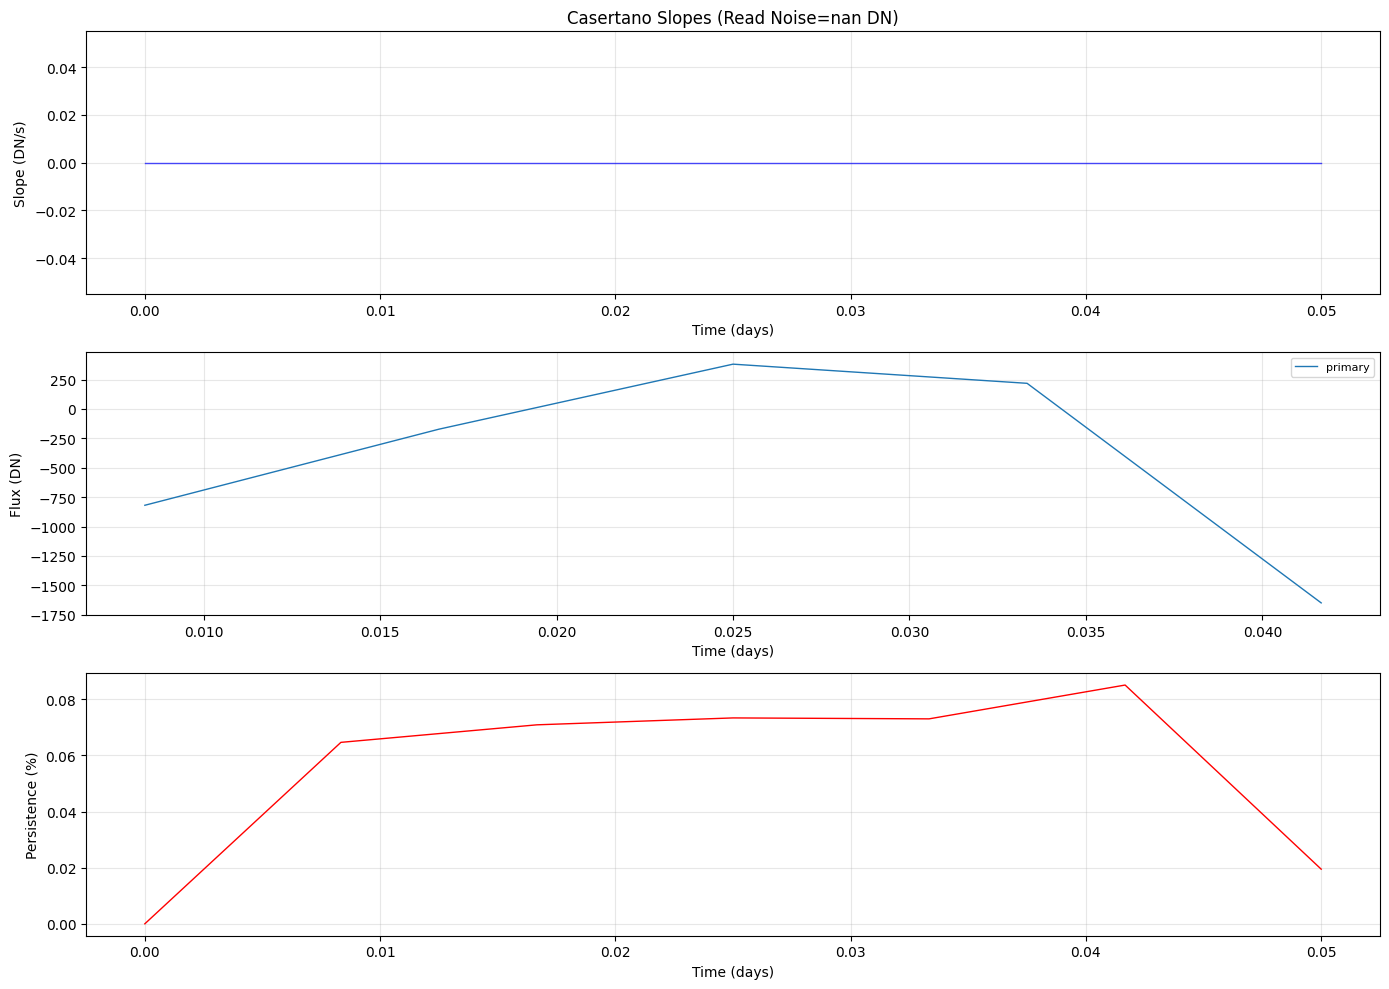

Photometry sources plotted: [np.int64(1)]
(Filtered to catalog sources only — id <= 2)


In [73]:
# ============================================================================
# Summary Plots
# ============================================================================
# Filter photometry to only the 5 catalog sources (id 1–5).
N_CATALOG_SOURCES = len(SOURCES)  # = 5
clean_phot = phot_df[phot_df['id'] <= N_CATALOG_SOURCES].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Panel 1: mean slope
axes[0].plot(l1_df['timestamp_days'], l1_df['mean_slope'],
             'b-', alpha=0.7, linewidth=1)
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Slope (DN/s)')
axes[0].set_title(
    f'Casertano Slopes (Read Noise={l1_df["read_noise_used"].iloc[0]:.2f} DN)')
axes[0].grid(True, alpha=0.3)

# Panel 2: per-source flux vs time
# Use timestamp_days from l1_df keyed on image_id for correct time axis
_time_map = l1_df.set_index('file_number')['timestamp_days'].to_dict()
source_labels = {i+1: s[0] for i, s in enumerate(SOURCES)}  # id → name
for sid in sorted(clean_phot['id'].unique()):
    sdata = clean_phot[clean_phot['id'] == sid].copy()
    sdata['time_days'] = sdata['image_id'].map(_time_map)
    sdata = sdata.dropna(subset=['time_days'])
    label = source_labels.get(sid, f'Source {sid}')
    axes[1].plot(sdata['time_days'], sdata['sum'],
                 label=label, linewidth=1)
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Flux (DN)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3: persistence
axes[2].plot(pers_df['timestamp_days'],
             pers_df['persistence_fraction'] * 100, 'r-', linewidth=1)
axes[2].set_xlabel('Time (days)')
axes[2].set_ylabel('Persistence (%)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    f'./{MAGNITUDE_FOLDER}/analysis_results/summary_plots_{MAG}.png', dpi=150)
plt.show()

print(f'Photometry sources plotted: {sorted(clean_phot["id"].unique())}')
print(f'(Filtered to catalog sources only — id <= {N_CATALOG_SOURCES})')


## Step 7: Uncertainty Summary

In [74]:
def create_uncertainty_summary(photometry_csv, mag):
    """Create uncertainty summary by image step."""
    
    # Load photometry data
    phot_df = pd.read_csv(photometry_csv)
    
    # Group by image_id and calculate statistics
    summary = phot_df.groupby('image_id').agg({
        'id': 'count',
        'flux_jy_err': ['mean', 'std', 'median'],
        'magnitude_err': ['mean', 'std', 'median'],
        'snr': ['mean', 'std', 'median']
    }).reset_index()
    
    # Flatten column names
    summary.columns = [
        'image_id', 
        'n_stars',
        'flux_err_mean', 'flux_err_std', 'flux_err_median',
        'mag_err_mean', 'mag_err_std', 'mag_err_median',
        'snr_mean', 'snr_std', 'snr_median'
    ]
    
    # Save
    output_csv = os.path.join(RESULTS_DIR, f'Uncertainty_Summary_by_Steps_Mag_{mag}.csv')
    summary.to_csv(output_csv, index=False)
    print(f"\n Created uncertainty summary: {output_csv}")
    
    return summary

# Create uncertainty summary
print(f"\nCreating uncertainty summary...")
create_uncertainty_summary(PHOTOMETRY_CSV, MAG)



Creating uncertainty summary...

 Created uncertainty summary: ./star_mag_mix_11.00/analysis_results/Uncertainty_Summary_by_Steps_Mag_11.csv


,image_id,n_stars,flux_err_mean,flux_err_std,flux_err_median,mag_err_mean,mag_err_std,mag_err_median,snr_mean,snr_std,snr_median
0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,5.239501e-22,NaN,5.239501e-22,NaN,NaN,NaN,-248.183236,NaN,-248.183236
2,3,1,5.461957e-22,NaN,5.461957e-22,NaN,NaN,NaN,-50.007066,NaN,-50.007066
3,4,1,6.542921e-22,NaN,6.542921e-22,0.011747,NaN,0.011747,92.420143,NaN,92.420143
4,5,1,5.865096e-22,NaN,5.865096e-22,0.018404,NaN,0.018404,58.992857,NaN,58.992857
5,6,1,4.926740e-22,NaN,4.926740e-22,NaN,NaN,NaN,-531.457699,NaN,-531.457699
6,7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Loading photometry data from ./star_mag_mix_11.00/analysis_results/Photometry_Mag_11.00.csv...
  Loaded 7 measurements from 7 images

Summary statistics by image:
   image_id  n_stars  flux_err_mean  flux_err_std  flux_err_median  \
0         1        1            NaN           NaN              NaN   
1         2        1            0.0           NaN              0.0   
2         3        1            0.0           NaN              0.0   
3         4        1            0.0           NaN              0.0   
4         5        1            0.0           NaN              0.0   
5         6        1            0.0           NaN              0.0   
6         7        1            NaN           NaN              NaN   

   mag_err_mean  mag_err_std  mag_err_median    snr_mean  snr_std  snr_median  
0           NaN          NaN             NaN         NaN      NaN         NaN  
1           NaN          NaN             NaN -248.183236      NaN -248.183236  
2           NaN          NaN        

/tmp/ipykernel_1085/1945051345.py:89: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax1.errorbar(summary_df['image_id'], summary_df['flux_err_mean'],
/tmp/ipykernel_1085/1945051345.py:92: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bs--" (-> color='b'). The keyword argument will take precedence.
  ax1.plot(summary_df['image_id'], summary_df['flux_err_median'], 'bs--',
/tmp/ipykernel_1085/1945051345.py:104: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax2.errorbar(summary_df['image_id'], summary_df['mag_err_mean'],
/tmp/ipykernel_1085/1945051345.py:107: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "rs--" (-> color='r'). The keyword argument will take precedence.
  a


Side-by-side uncertainty plot saved as: ./star_mag_mix_11.00/analysis_results/Uncertainty_SideBySide_Mag_11.png


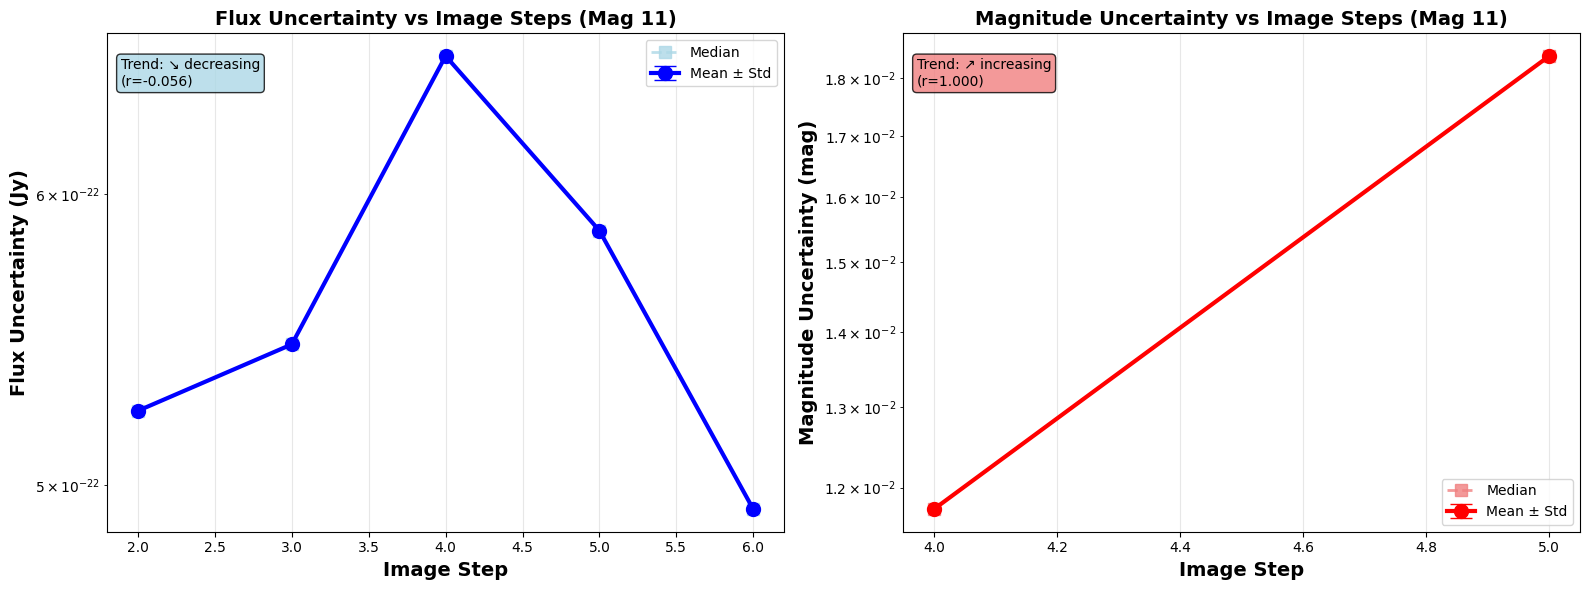


TREND ANALYSIS:
Flux uncertainty trend:
   Slope: -2.22e-24 Jy/step
   R-correlation: -0.056
   P-value: 0.928
   Overall trend: decreasing

Magnitude uncertainty trend:
   Slope: 0.0067 mag/step
   R-correlation: 1.000
   P-value: 0.000
   Overall trend: increasing

Summary statistics saved as: ./star_mag_mix_11.00/analysis_results/Uncertainty_Summary_by_Steps_Mag_11.csv


In [75]:
summary_df = plot_uncertainty_by_steps(
    f'./{MAGNITUDE_FOLDER}/analysis_results/Photometry_Mag_{MAG:.2f}.csv',
    mag=MAG,
    plot_style='side_by_side',
    output_dir=f'./{MAGNITUDE_FOLDER}/analysis_results'
)


#### Persistence Summary

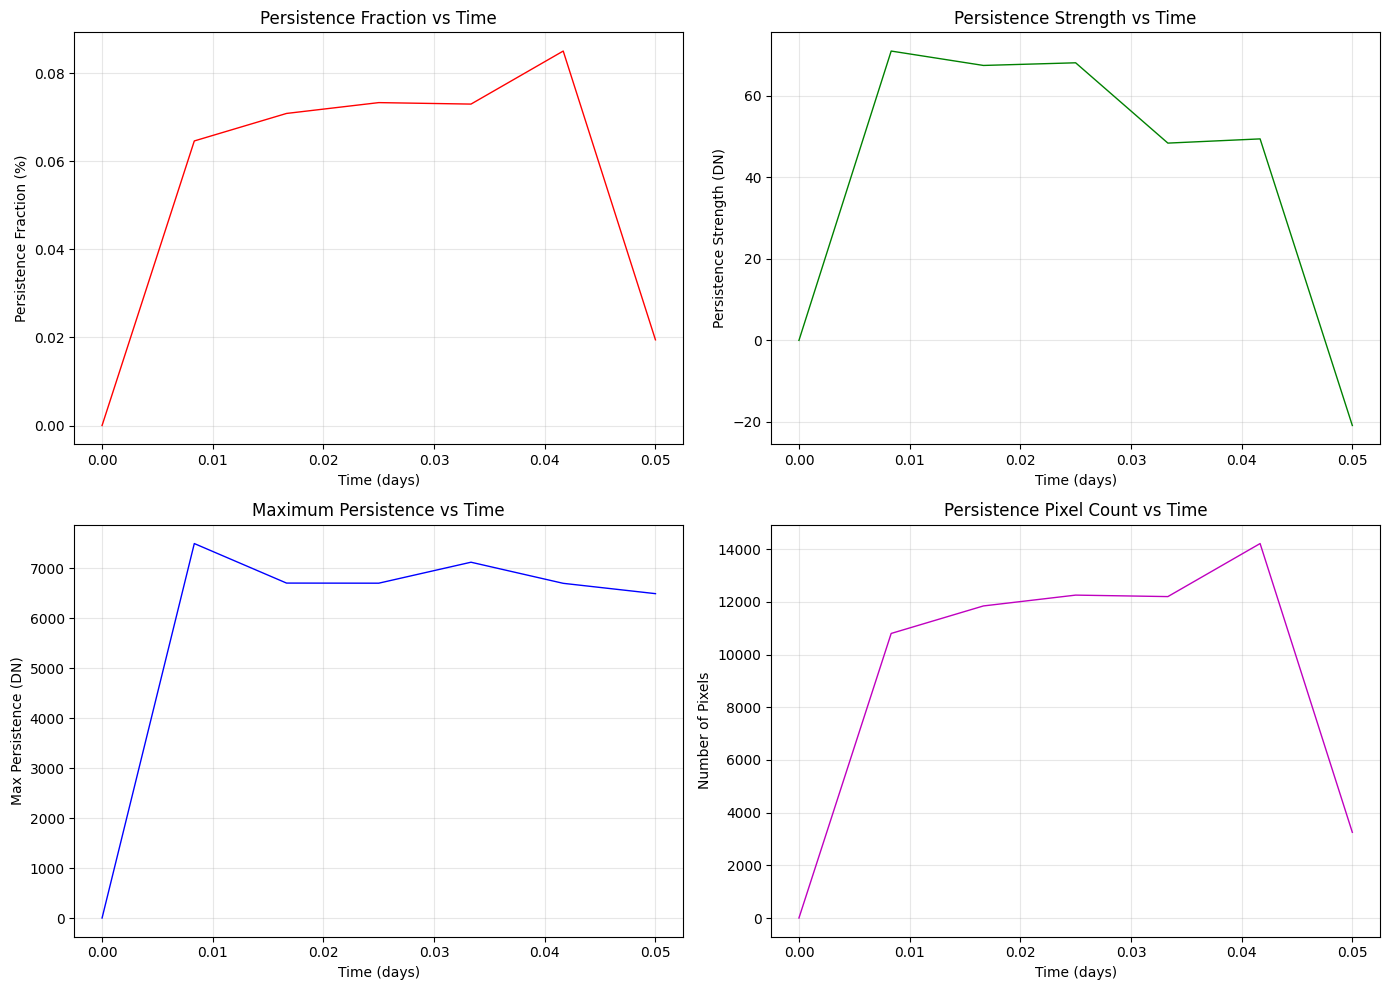

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(pers_df['timestamp_days'], pers_df['persistence_fraction']*100, 'r-', linewidth=1)
axes[0,0].set_xlabel('Time (days)')
axes[0,0].set_ylabel('Persistence Fraction (%)')
axes[0,0].set_title('Persistence Fraction vs Time')
axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(pers_df['timestamp_days'], pers_df['persistence_strength'], 'g-', linewidth=1)
axes[0,1].set_xlabel('Time (days)')
axes[0,1].set_ylabel('Persistence Strength (DN)')
axes[0,1].set_title('Persistence Strength vs Time')
axes[0,1].grid(True, alpha=0.3)
axes[1,0].plot(pers_df['timestamp_days'], pers_df['persistence_max'], 'b-', linewidth=1)
axes[1,0].set_xlabel('Time (days)')
axes[1,0].set_ylabel('Max Persistence (DN)')
axes[1,0].set_title('Maximum Persistence vs Time')
axes[1,0].grid(True, alpha=0.3)
axes[1,1].plot(pers_df['timestamp_days'], pers_df['n_persistence_pixels'], 'm-', linewidth=1)
axes[1,1].set_xlabel('Time (days)')
axes[1,1].set_ylabel('Number of Pixels')
axes[1,1].set_title('Persistence Pixel Count vs Time')
axes[1,1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'./{MAGNITUDE_FOLDER}/analysis_results/persistence_detailed_MAG_{MAG}.png', dpi=150)
plt.show()

NameError: name 'max_val' is not defined

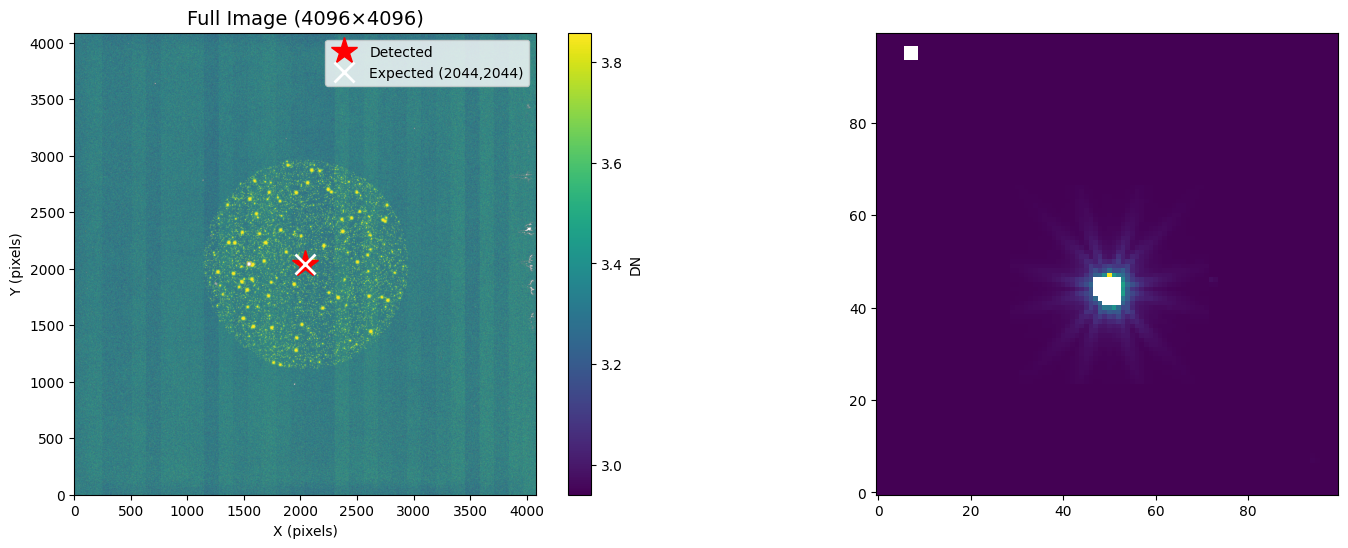

In [77]:
# Create visualization
l2_filename = f'roman_sim_F146_WFI01_L2_7.asdf'
l2_filepath = os.path.join(TEMP_L1_DIR, l2_filename)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

with asdf.open(f'./{MAGNITUDE_FOLDER}/temp_l1_processing/{l2_filename}') as af:
    data = af['roman']['data']
    
    # Full image
    im0 = axes[0].imshow(data, cmap='viridis', origin='lower',
                         vmin=np.nanpercentile(data, 1),
                         vmax=np.nanpercentile(data, 99))
    axes[0].plot(source_x, source_y, 'r*', markersize=20, label='Detected')
    axes[0].plot(2044, 2044, 'wx', markersize=15, mew=2, label='Expected (2044,2044)')
    axes[0].set_title('Full Image (4096×4096)', fontsize=14)
    axes[0].set_xlabel('X (pixels)')
    axes[0].set_ylabel('Y (pixels)')
    axes[0].legend()
    plt.colorbar(im0, ax=axes[0], label='DN')
    
    # 100×100 cutout around detected source
    cutout_size = 50
    y_c = slice(max(0, source_y-cutout_size), min(data.shape[0], source_y+cutout_size))
    x_c = slice(max(0, source_x-cutout_size), min(data.shape[1], source_x+cutout_size))
    #y_c = slice(max(0, 2000-cutout_size), min(data.shape[0], 2000+cutout_size))
    #x_c = slice(max(0, 1500-cutout_size), min(data.shape[1], 1500+cutout_size))
    cutout = data[y_c, x_c]
    
    im1 = axes[1].imshow(cutout, cmap='viridis', origin='lower')
    #axes[1].plot(cutout_size, cutout_size, 'r*', markersize=20)
    axes[1].set_title(f'100×100 Cutout\nPeak: {max_val:.1f} DN', fontsize=14)
    axes[1].set_xlabel('X (pixels)')
    axes[1].set_ylabel('Y (pixels)')
    plt.colorbar(im1, ax=axes[1], label='DN')
    
    plt.tight_layout()
    plt.show()


## Single Pixel Resultant 1 Variance Plot


ENSEMBLE MAGNITUDE - SATURATED VS UNSATURATED COMPARISON
 Only unsaturated CSV found - plotting single dataset

Unsaturated:
  Found 1681 ensemble pixels
  Valid measurements: 7
  Mean magnitude: 37.9428 mag
  Std deviation: 0.0947 mag
  Variance: 0.008970 mag²


/tmp/ipykernel_1085/1323765915.py:84: RuntimeWarning: divide by zero encountered in log10
  mag_all = -2.5 * np.log10(jy_all) + ZERO_POINT_AB
/opt/conda/envs/RomanNexus-2026.1/lib/python3.12/site-packages/numpy/_core/_methods.py:188: RuntimeWarning: invalid value encountered in subtract
  x = um.subtract(arr, arrmean, out=...)



 Saved: ./star_mag_mix_11.00/analysis_results/ensemble_magnitude_comparison.png


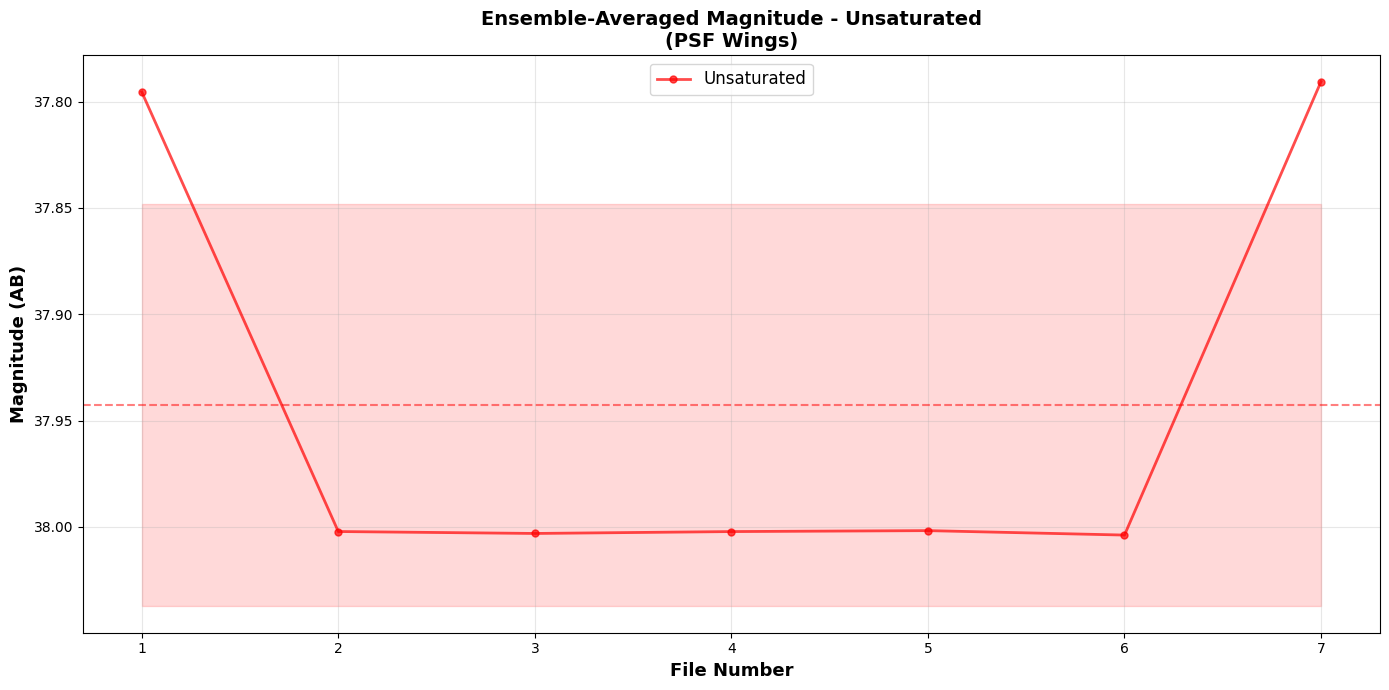

In [81]:
# ============================================================================
# COMPARISON PLOT: Ensemble Magnitude (Saturated vs Unsaturated)
# ============================================================================
print(f"\n{'='*80}")
print("ENSEMBLE MAGNITUDE - SATURATED VS UNSATURATED COMPARISON")
print(f"{'='*80}")

# Configuration
csv_unsat = os.path.join(RESULTS_DIR, 'multi_pixel_resultant1_unsat.csv')
csv_sat = os.path.join(RESULTS_DIR, 'multi_pixel_resultant1_sat.csv')

# Check which files exist
has_unsat = os.path.exists(csv_unsat)
has_sat = os.path.exists(csv_sat)

if not has_unsat and not has_sat:
    print(" No CSV files found!")
    print(f"   Expected: {csv_unsat}")
    print(f"         or: {csv_sat}")
else:
    # Determine which files to load
    if has_unsat and not has_sat:
        print(" Only unsaturated CSV found - plotting single dataset")
        csv_files = {'Unsaturated': csv_unsat}
        colors = {'Unsaturated': 'red'}
    elif has_sat and not has_unsat:
        print(" Only saturated CSV found - plotting single dataset")
        csv_files = {'Saturated': csv_sat}
        colors = {'Saturated': 'blue'}
    else:
        print(" Both CSV files found - plotting comparison")
        csv_files = {'Saturated': csv_sat, 'Unsaturated': csv_unsat}
        colors = {'Saturated': 'blue', 'Unsaturated': 'red'}


    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))

    all_stats = {}

    for label, csv_file in csv_files.items():
        df = pd.read_csv(csv_file)
        
        # Filter for ensemble pixels (psf_wing_*)
        df_ensemble = df[df['pixel_name'].str.startswith('psf_wing_')]
        
        if len(df_ensemble) == 0:
            print(f" No ensemble pixels in {label} CSV")
            print(f"   Looking for pixels starting with 'psf_wing_'")
            print(f"   Found pixel names: {df['pixel_name'].unique()[:5]}")
            continue
        
        print(f"\n{label}:")
        print(f"  Found {len(df_ensemble['pixel_name'].unique())} ensemble pixels")
        
        # Compute ensemble average for each file
        file_numbers = sorted(df_ensemble['file_number'].unique())
        ensemble_mags = []
        ensemble_stds = []
        
        for file_num in file_numbers:
            df_file = df_ensemble[df_ensemble['file_number'] == file_num]
            dn_values = df_file['resultant_DN'].values
            
            # Filter NaN
            valid_mask = np.isfinite(dn_values)
            dn_valid = dn_values[valid_mask]
            
            if len(dn_valid) == 0:
                continue
            
            # Ensemble average
            mean_dn = np.mean(dn_valid)
            
            # Convert to magnitude
            dn_per_sec = mean_dn / RESULTANT0_TIME
            jy = dn_per_sec * photfnu
            mag = -2.5 * np.log10(jy) + ZERO_POINT_AB
            ensemble_mags.append(mag)
            
            # Std from pixel scatter
            dn_per_sec_all = dn_valid / RESULTANT0_TIME
            jy_all = dn_per_sec_all * photfnu
            mag_all = -2.5 * np.log10(jy_all) + ZERO_POINT_AB
            ensemble_stds.append(np.std(mag_all))
        
        ensemble_mags = np.array(ensemble_mags)
        ensemble_stds = np.array(ensemble_stds)
        file_numbers = np.array(file_numbers[:len(ensemble_mags)])
        
        print(f"  Valid measurements: {len(ensemble_mags)}")
        
        if len(ensemble_mags) == 0:
            print(f"   All measurements are invalid")
            all_stats[label] = None
            continue
        
        # Statistics
        mean_mag = np.mean(ensemble_mags)
        std_mag = np.std(ensemble_mags)
        var_mag = np.var(ensemble_mags)
        
        all_stats[label] = {
            'mean': mean_mag,
            'std': std_mag,
            'var': var_mag,
            'n': len(ensemble_mags)
        }
        
        print(f"  Mean magnitude: {mean_mag:.4f} mag")
        print(f"  Std deviation: {std_mag:.4f} mag")
        print(f"  Variance: {var_mag:.6f} mag²")
        
        # Plot
        color = colors[label]
        ax.plot(file_numbers, ensemble_mags, 
               'o-', color=color, linewidth=2, markersize=5, alpha=0.7, label=label)
        
        # Mean line
        ax.axhline(mean_mag, color=color, linestyle='--', linewidth=1.5, alpha=0.5)
        
        # ±1σ band
        ax.fill_between(file_numbers, 
                       mean_mag - std_mag, mean_mag + std_mag,
                       alpha=0.15, color=color)

    # Formatting
    ax.set_xlabel('File Number', fontsize=13, fontweight='bold')
    ax.set_ylabel('Magnitude (AB)', fontsize=13, fontweight='bold')

    if len(csv_files) == 2:
        title = 'Ensemble-Averaged Magnitude Comparison\nSaturated vs Unsaturated (PSF Wings)'
    else:
        mode = list(csv_files.keys())[0]
        title = f'Ensemble-Averaged Magnitude - {mode}\n(PSF Wings)'

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12, loc='best')

    plt.tight_layout()

    # Save
    output_file = os.path.join(RESULTS_DIR, 'ensemble_magnitude_comparison.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\n Saved: {output_file}")

    plt.show()

    # Print comparison statistics
    if len(all_stats) == 2 and all(v is not None for v in all_stats.values()):
        print("\n" + "="*80)
        print("COMPARISON STATISTICS")
        print("="*80)
        
        sat_stats = all_stats.get('Saturated')
        unsat_stats = all_stats.get('Unsaturated')
        
        if sat_stats and unsat_stats:
            print(f"\n{'Metric':<20} {'Saturated':<20} {'Unsaturated':<20} {'Difference':<15}")
            print("-"*80)
            
            mean_diff = unsat_stats['mean'] - sat_stats['mean']
            var_diff = unsat_stats['var'] - sat_stats['var']
            std_diff = unsat_stats['std'] - sat_stats['std']
            
            print(f"{'Mean (mag)':<20} {sat_stats['mean']:<20.4f} {unsat_stats['mean']:<20.4f} {mean_diff:+.4f}")
            print(f"{'Std Dev (mag)':<20} {sat_stats['std']:<20.4f} {unsat_stats['std']:<20.4f} {std_diff:+.4f}")
            print(f"{'Variance (mag²)':<20} {sat_stats['var']:<20.6f} {unsat_stats['var']:<20.6f} {var_diff:+.6f}")
            print(f"{'N measurements':<20} {sat_stats['n']:<20d} {unsat_stats['n']:<20d} {unsat_stats['n']-sat_stats['n']:+d}")
            
            print("="*80)
            
            # Interpretation
            print("\n" + "="*80)
            print("INTERPRETATION")
            print("="*80)
            
            if abs(mean_diff) < 0.01:
                print(f"\n Means are virtually IDENTICAL ({abs(mean_diff):.4f} mag difference)")
                print("    Saturation removal does not affect ensemble mean brightness")
                print("    PSF wing pixels unaffected by saturation")
            else:
                print(f"\n Means differ by {abs(mean_diff):.3f} mag")
                if mean_diff > 0:
                    print("    Unsaturated is FAINTER")
                else:
                    print("    Saturated is FAINTER")
            
            if abs(var_diff) < 0.001:
                print(f"\n Variances are virtually IDENTICAL ({abs(var_diff):.6f} mag² difference)")
                print("    Saturation removal does not affect variance")
                print("    Ensemble tracking successfully avoids saturated regions")
            else:
                var_pct = (var_diff / sat_stats['var']) * 100
                print(f"\n Variance changed by {var_pct:+.1f}%")
                if var_diff > 0:
                    print("    Unsaturated shows MORE variance")
                else:
                    print("    Saturated shows MORE variance")

print(f"\n{'='*80}")


In [82]:
# ============================================================================
# SIMPLE VIEW: Individual Pixel Magnitude Plots
# ============================================================================
print(f"\n{'='*80}")
print("INDIVIDUAL PIXEL MAGNITUDE PLOTS")
print(f"{'='*80}")

# Load the data
if not os.path.exists(MULTI_PIXEL_CSV):
    print(f" CSV file not found: {MULTI_PIXEL_CSV}")
else:
# Setup correct timing for this resultant
    resultant_num = 0  # Using resultant 0
    resultant_time = RESULTANT_TIMES[resultant_num]  # MA table 1002 timing
    print(f"Using resultant {resultant_num} with timing {resultant_time:.3f}s")

    df = pd.read_csv(MULTI_PIXEL_CSV_FILES[0])
    
    pixel_names = df['pixel_name'].unique()
    print(f" Loaded data for {len(pixel_names)} pixels")
    
    # Select which pixels to plot (skip background for cleaner view)
    pixels_to_plot = ['star_core', 'near_core', 'psf_wing']
    colors = {'star_core': 'red', 'near_core': 'orange', 'psf_wing': 'blue'}
    
    # Filter for available pixels
    available_pixels = [p for p in pixels_to_plot if p in pixel_names]
    
    if len(available_pixels) == 0:
        print(" No pixel data found")
    else:
        # Create figure with 3 subplots
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle('Individual Pixel Magnitude Time Series\nResultant 1 (3.16 sec)',
                     fontsize=15, fontweight='bold', y=1.02)
        
        for idx, pixel_name in enumerate(available_pixels):
            df_pixel = df[df['pixel_name'] == pixel_name]
            
            if len(df_pixel) == 0:
                continue
            
            file_numbers = df_pixel['file_number'].values
            dn_values = df_pixel['resultant_DN'].values
            distance = df_pixel['distance_from_star'].iloc[0]
            
            # Convert to magnitude
            dn_per_sec = dn_values / RESULTANT0_TIME
            jy_values = dn_per_sec * photfnu
            
            with np.errstate(divide='ignore', invalid='ignore'):
                mag_values = -2.5 * np.log10(jy_values) + ZERO_POINT_AB
            
            # Filter finite values
            finite_mask = np.isfinite(mag_values)
            
            if not np.any(finite_mask):
                print(f" {pixel_name}: All NaN (saturated)")
                continue
            
            # Calculate statistics
            mean_mag = np.mean(mag_values[finite_mask])
            std_mag = np.std(mag_values[finite_mask])
            
            # Plot
            ax = axes[idx]
            color = colors.get(pixel_name)
            
            ax.plot(file_numbers[finite_mask], mag_values[finite_mask], 
                   'o-', color=color, linewidth=1.5, markersize=3, alpha=0.7)
            
            # Mean line
            ax.axhline(mean_mag, color='black', linestyle='--', linewidth=1.5,
                      label=f"Mean = {mean_mag:.2f} mag")
            
            # ±1σ band
            ax.fill_between(file_numbers[finite_mask], 
                           mean_mag - std_mag, mean_mag + std_mag,
                           alpha=0.2, color=color)
            
            ax.set_xlabel('File Number', fontsize=11, fontweight='bold')
            ax.set_ylabel('Magnitude (AB)', fontsize=11, fontweight='bold')
            ax.set_title(f"{pixel_name}", fontsize=12, fontweight='bold')
            ax.invert_yaxis()
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9)
            
            print(f"  {pixel_name}: Mean = {mean_mag:.4f} mag, Std = {std_mag:.4f} mag")
        
        plt.tight_layout()
        
        # Save
        output_file = os.path.join(RESULTS_DIR, 'individual_pixel_magnitudes_simple.png')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"\n Saved: {output_file}")
        
        plt.show()

print(f"{'='*80}")


INDIVIDUAL PIXEL MAGNITUDE PLOTS
Using resultant 0 with timing 3.162s
 Loaded data for 1681 pixels
 No pixel data found


#### Delta Mag Comparisons

In [83]:
# ============================================================================
# CELL 23: PIXEL-BY-PIXEL DELTA-MAG ANALYSIS (Professor's Method)
# ============================================================================

print("="*80)
print("PIXEL-BY-PIXEL PERSISTENCE ANALYSIS")
print("="*80)

CSV_FILE = os.path.join(RESULTS_DIR,
    'multi_pixel_resultant1_unsat.csv' if USE_SATURATION_REMOVAL
    else 'multi_pixel_resultant1_sat.csv')


def calculate_pixel_deltamag(csv_file):
    """Calculate Δm for each pixel across all exposures."""
    df = pd.read_csv(csv_file)
    print(f"  CSV shape: {df.shape}")
    print(f"  Columns:   {list(df.columns)}")
    print(f"  Exposures: {df['file_number'].nunique()}")
    print(f"  Pixels:    {df['pixel_name'].nunique()}")
    print(f"  NaN DN:    {df['resultant_DN'].isna().sum()} / {len(df)}")
    print(f"  DN range:  {df['resultant_DN'].min():.1f} – {df['resultant_DN'].max():.1f}")

    pixels  = df['pixel_name'].unique()
    results = []

    for pixel_name in pixels:
        df_pix       = df[df['pixel_name'] == pixel_name]
        dn_values    = df_pix['resultant_DN'].values
        file_numbers = df_pix['file_number'].values

        valid_mask  = np.isfinite(dn_values) & (dn_values > 0)
        dn_valid    = dn_values[valid_mask]
        files_valid = file_numbers[valid_mask]

        if len(dn_valid) < 2:
            continue

        flux = dn_valid / RESULTANT0_TIME * photfnu
        with np.errstate(divide='ignore', invalid='ignore'):
            mag = -2.5 * np.log10(flux) + ZERO_POINT_AB

        valid_mag = np.isfinite(mag)
        if valid_mag.sum() < 2:
            continue

        mag         = mag[valid_mag]
        files_valid = files_valid[valid_mag]
        mean_mag    = np.mean(mag)
        delta_mag   = mag - mean_mag
        rms_mmag    = np.std(delta_mag) * 1000

        results.append({
            'pixel_name':         pixel_name,
            'pixel_y':            df_pix['pixel_y'].iloc[0],
            'pixel_x':            df_pix['pixel_x'].iloc[0],
            'mean_mag':           mean_mag,
            'rms_mmag':           rms_mmag,
            'max_deviation_mmag': np.max(np.abs(delta_mag)) * 1000,
            'n_measurements':     len(dn_valid),
            'delta_mag':          delta_mag,
            'file_numbers':       files_valid,
        })

    return pd.DataFrame(results)


MULTI_PIX_CSV = os.path.join(RESULTS_DIR, 'multi_pixel_resultant1_unsat.csv')

# ── RUN ──────────────────────────────────────────────────────────────────────────────────────────────────────
if not os.path.exists(CSV_FILE):
    print(f"\nCSV file not found: {CSV_FILE}")
    print("Run the main pipeline first to generate the multi-pixel CSV.")
else:
    print(f"\nLoading: {CSV_FILE}")
    pixel_stats = calculate_pixel_deltamag(CSV_FILE)

    if pixel_stats.empty:
        print("\n  ERROR: No pixels had enough valid measurements.")
        print("  Likely causes:")
        print("    1. Only 1 exposure run so far — need at least 2 per pixel")
        print("    2. All DN values are NaN (saturation masking too aggressive)")
        print(f"    3. photfnu={photfnu:.3e} or RESULTANT0_TIME={RESULTANT0_TIME} is wrong")
        print("  Run more exposures then re-run this cell.")
    else:
        print(f"\n  Analyzed {len(pixel_stats)} pixels")
        print(f"  Mean RMS:   {pixel_stats['rms_mmag'].mean():.1f} mmag")
        print(f"  Median RMS: {pixel_stats['rms_mmag'].median():.1f} mmag")
        print(f"  Range:      {pixel_stats['rms_mmag'].min():.1f} – "
              f"{pixel_stats['rms_mmag'].max():.1f} mmag")


PIXEL-BY-PIXEL PERSISTENCE ANALYSIS

Loading: ./star_mag_mix_11.00/analysis_results/multi_pixel_resultant1_unsat.csv
  CSV shape: (11767, 7)
  Columns:   ['file_number', 'pixel_name', 'pixel_y', 'pixel_x', 'resultant_DN', 'timestamp_sec', 'distance_from_star']
  Exposures: 7
  Pixels:    1681
  NaN DN:    0 / 11767
  DN range:  0.0 – 41081.0

  Analyzed 1681 pixels
  Mean RMS:   97.5 mmag
  Median RMS: 53.0 mmag
  Range:      0.6 – 850.5 mmag


In [84]:
# ============================================================================
# DISTANCE-TRANSFORM OUTLIER DETECTION (Popowicz & Smolka)
# Uses distance_background_python.py
# ============================================================================
import sys
sys.path.insert(0, '.')
from distance_background_python import detect_foreground_score_map, postprocess_mask
from romanisim import parameters as romanisim_parameters

with asdf.open(l2_filepath) as af:
    l2_image = np.array(af['roman']['data'])


def find_outlier_pixels_distance_transform(l2_data, ensemble_pixels,
                                           window_size=21, k_sensitivity=1.0,
                                           gain_e_per_adu=1.0, read_noise_e=13.0,
                                           n_exposures=1.0, mask_dilation_radius=1,
                                           focus_field=None, pixel_stats_df=None,
                                           psf_exclusion_radius=0,
                                           star_y=None, star_x=None):
    """Score the full L2 frame with the Popowicz & Smolka distance-transform
    detector, then return one row per ensemble pixel that is flagged.

    Running on the full frame (rather than a crop around the ensemble pixels)
    ensures every pixel's local background window sits in true flat background
    and is not contaminated by the bright star PSF elsewhere in the field.

    Returns a DataFrame with columns:
        pixel_name, pixel_y, pixel_x, focus_mean_flux, neighbor_median,
        ratio, rms_mmag, focus_field, method, score
    """
    cols = ['pixel_name', 'pixel_y', 'pixel_x', 'focus_mean_flux',
            'neighbor_median', 'ratio', 'rms_mmag', 'focus_field',
            'method', 'score']

    if not ensemble_pixels:
        return pd.DataFrame(columns=cols)

    # NaNs (saturation-removal masking) would register as artificial deep
    # minima in the relaxation — fill with the frame's finite median instead.
    work_adu = np.asarray(l2_data, dtype=np.float64)
    finite = np.isfinite(work_adu)
    fill_value = float(np.median(work_adu[finite])) if finite.any() else 0.0
    work_adu = np.where(finite, work_adu, fill_value)

    work_e = work_adu * float(gain_e_per_adu)

    score = detect_foreground_score_map(
        image_e=work_e, window_size=int(window_size), k=float(k_sensitivity),
        read_noise_e=float(read_noise_e), n_exposures=float(n_exposures),
        use_numba=True,
    )
    mask = postprocess_mask(score, dilation_radius=int(mask_dilation_radius))

    r = int(window_size) // 2
    outliers = []
    for p in ensemble_pixels:
        y, x = p['y'], p['x']
        # Skip pixels within the PSF exclusion radius of the star center
        if (psf_exclusion_radius > 0 and star_y is not None and star_x is not None
                and np.sqrt((y - star_y)**2 + (x - star_x)**2) <= psf_exclusion_radius):
            continue
        if not mask[y, x]:
            continue

        wy0, wy1 = max(0, y - r), min(mask.shape[0], y + r + 1)
        wx0, wx1 = max(0, x - r), min(mask.shape[1], x + r + 1)
        local_adu  = work_adu[wy0:wy1, wx0:wx1]
        local_mask = mask[wy0:wy1, wx0:wx1]
        bg_pixels  = local_adu[~local_mask]
        neighbor_median = float(np.median(bg_pixels)) if bg_pixels.size else np.nan
        flux  = float(work_adu[y, x])
        ratio = flux / neighbor_median if neighbor_median and neighbor_median > 0 else np.nan

        rms_val = np.nan
        if pixel_stats_df is not None and len(pixel_stats_df):
            row = pixel_stats_df[pixel_stats_df['pixel_name'] == p['name']]
            if len(row):
                rms_val = float(row['rms_mmag'].values[0])

        outliers.append({
            'pixel_name': p['name'], 'pixel_y': y, 'pixel_x': x,
            'focus_mean_flux': flux, 'neighbor_median': neighbor_median,
            'ratio': ratio, 'rms_mmag': rms_val, 'focus_field': focus_field,
            'method': 'distance_transform', 'score': float(score[y, x]),
        })

    if not outliers:
        return pd.DataFrame(columns=cols)
    return pd.DataFrame(outliers).sort_values('score', ascending=False).reset_index(drop=True)


# ── RUN ──────────────────────────────────────────────────────────────────
GAIN_E_PER_ADU = romanisim_parameters.reference_data['gain']      # 2 e-/DN
READ_NOISE_E   = romanisim_parameters.reference_data['readnoise'] # 5.0 e-

WINDOW_SIZE          = 21   # odd; ~2x the persistence-blob diameter you expect
K_SENSITIVITY        = 1    # lower = more sensitive
DILATION_RADIUS      = 1
FOCUS_FIELD          = 1    # field with the saturating star — label only
PSF_EXCLUSION_RADIUS = 15   # pixels — skip ensemble pixels this close to the star

ensemble_pixels = select_ensemble_pixels(source_y, source_x, max_radius=ENSEMBLE_MAX_RADIUS)

outliers_m5 = find_outlier_pixels_distance_transform(
    l2_image, ensemble_pixels,
    window_size=WINDOW_SIZE, k_sensitivity=K_SENSITIVITY,
    gain_e_per_adu=GAIN_E_PER_ADU, read_noise_e=READ_NOISE_E,
    n_exposures=1.0, mask_dilation_radius=DILATION_RADIUS,
    focus_field=FOCUS_FIELD, pixel_stats_df=pixel_stats,
    psf_exclusion_radius=PSF_EXCLUSION_RADIUS,
    star_y=source_y, star_x=source_x,
)
print(f"Found {len(outliers_m5)} Method 5 outlier pixels")

outliers_combined = outliers_m5
print(f"Total flagged pixels: {len(outliers_combined)} (distance-transform only)")


2024
2065
2024
2065
Running numba-accelerated distance-transform detection...
Found 13 Method 5 outlier pixels
Total flagged pixels: 13 (distance-transform only)



Creating L2 flux map...
2024
2065
2024
2065


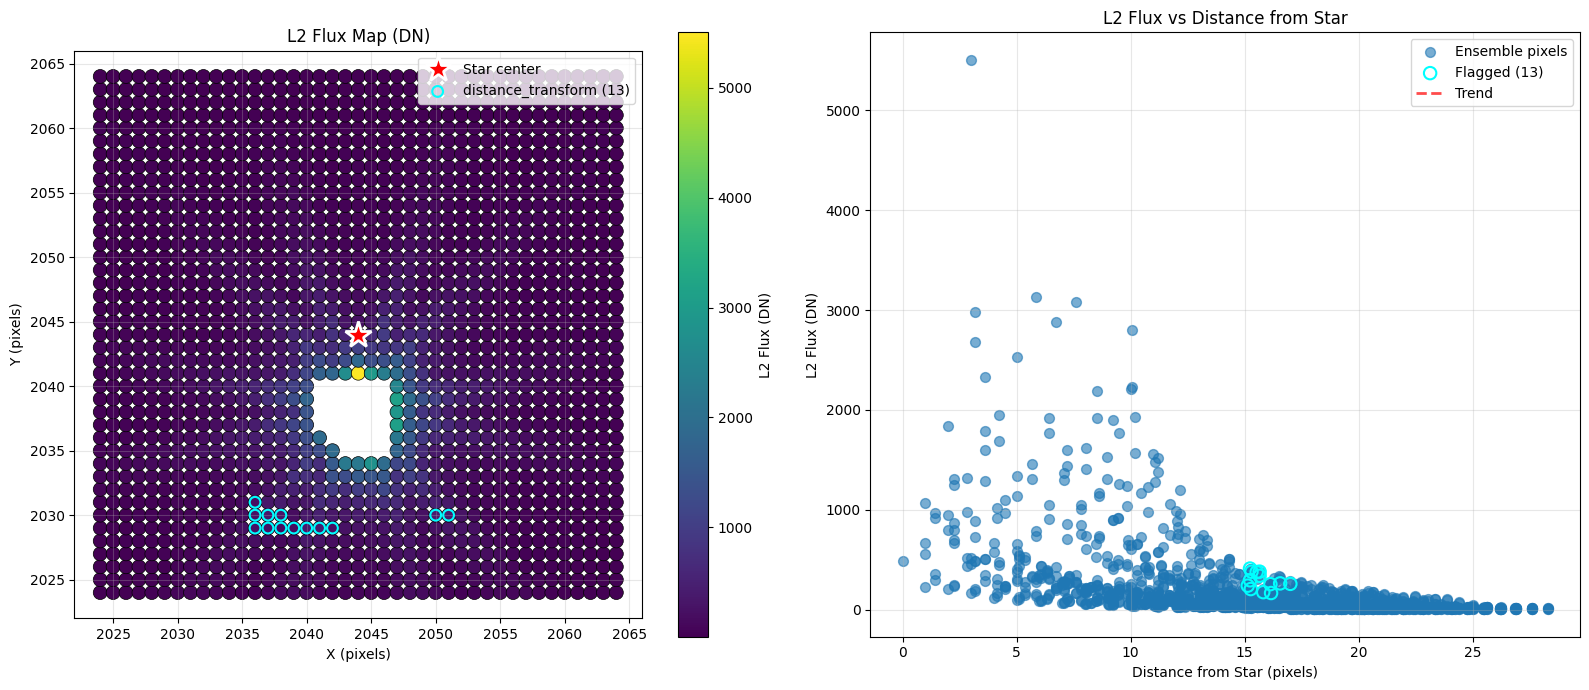

  Saved: pixel_flux_map.png

ANALYSIS SUMMARY

Pixels with 50–100 mmag variation: 387 / 1681 (23.0%)
High variation pixels (>100 mmag): 485
  These may show persistence effects:
    psf_wing_000265 | RMS= 102.2 mmag | r=14.0px
    psf_wing_000274 | RMS= 105.9 mmag | r=16.1px
    psf_wing_000306 | RMS= 114.3 mmag | r=13.0px
    psf_wing_000307 | RMS= 119.2 mmag | r=13.0px
    psf_wing_000314 | RMS= 109.2 mmag | r=14.8px

  Results saved to ./star_mag_mix_11.00/analysis_results/


In [85]:
if True:
    if True:  # Step 3: L2 flux map with outlier overlay
        print("\nCreating L2 flux map...")

        # ── Build ensemble pixel coordinate arrays ────────────────────────────
        # Pull y/x and L2 DN values directly from l2_image so the scatter
        # and the outlier flags are in the same image coordinate frame.
        ensemble_pixels = select_ensemble_pixels(source_y, source_x,
                                                 max_radius=ENSEMBLE_MAX_RADIUS)
        y_coords    = np.array([p['y'] for p in ensemble_pixels])
        x_coords    = np.array([p['x'] for p in ensemble_pixels])
        l2_values   = np.array([float(l2_image[p['y'], p['x']])
                                 for p in ensemble_pixels])
        distances   = np.sqrt((y_coords - source_y)**2 + (x_coords - source_x)**2)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        # ── Left: spatial flux map with flagged pixels overlaid ───────────────
        sc1 = ax1.scatter(x_coords, y_coords, c=l2_values,
                          s=100, cmap='viridis', edgecolors='black', linewidths=0.5)
        ax1.plot(source_x, source_y, '*', color='red', markersize=20,
                 markeredgecolor='white', markeredgewidth=2, label='Star center')

        method_colors = {'field_neighbor': 'red', 'distance_transform': 'cyan'}
        for method_name, group in outliers_combined.groupby('method'):
            ax1.scatter(group['pixel_x'], group['pixel_y'],
                        s=60, facecolors='none',
                        edgecolors=method_colors.get(method_name, 'orange'),
                        linewidths=1.5, zorder=3,
                        label=f'{method_name} ({len(group)})')

        ax1.set_xlabel('X (pixels)'); ax1.set_ylabel('Y (pixels)')
        ax1.set_title('L2 Flux Map (DN)')
        ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_aspect('equal')
        plt.colorbar(sc1, ax=ax1, label='L2 Flux (DN)')

        # ── Right: flux vs distance, flagged pixels highlighted ───────────────
        ax2.scatter(distances, l2_values, alpha=0.6, s=50, label='Ensemble pixels')

        # Overlay flagged pixels on the scatter plot too
        if len(outliers_combined) > 0:
            flag_ys = outliers_combined['pixel_y'].values
            flag_xs = outliers_combined['pixel_x'].values
            flag_flux = np.array([float(l2_image[y, x])
                                   for y, x in zip(flag_ys, flag_xs)])
            flag_dist = np.sqrt((flag_ys - source_y)**2 + (flag_xs - source_x)**2)
            ax2.scatter(flag_dist, flag_flux, s=80, facecolors='none',
                        edgecolors='cyan', linewidths=1.5, zorder=3,
                        label=f'Flagged ({len(outliers_combined)})')

        z = np.polyfit(distances, l2_values, 2)
        x_trend = np.linspace(distances.min(), distances.max(), 100)
        ax2.plot(x_trend, np.poly1d(z)(x_trend), 'r--', lw=2,
                 alpha=0.7, label='Trend')
        ax2.set_xlabel('Distance from Star (pixels)')
        ax2.set_ylabel('L2 Flux (DN)')
        ax2.set_title('L2 Flux vs Distance from Star')
        ax2.legend(); ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, 'pixel_flux_map.png'),
                    dpi=300, bbox_inches='tight')
        plt.show()
        print(f"  Saved: pixel_flux_map.png")

        # ── Summary ───────────────────────────────────────────────────────────
        print("\n" + "="*80)
        print("ANALYSIS SUMMARY")
        print("="*80)
        target_range = pixel_stats[pixel_stats['rms_mmag'].between(50, 100)]
        print(f"\nPixels with 50–100 mmag variation: {len(target_range)} / {len(pixel_stats)} "
              f"({len(target_range)/len(pixel_stats)*100:.1f}%)")
        high_var = pixel_stats[pixel_stats['rms_mmag'] > 100]
        print(f"High variation pixels (>100 mmag): {len(high_var)}")
        if len(high_var) > 0:
            print("  These may show persistence effects:")
            for idx, row in high_var.head().iterrows():
                dist = np.sqrt((row['pixel_y']-source_y)**2 + (row['pixel_x']-source_x)**2)
                print(f"    {row['pixel_name']:15s} | RMS={row['rms_mmag']:6.1f} mmag | r={dist:.1f}px")
        pixel_stats.to_csv(os.path.join(RESULTS_DIR, 'pixel_statistics.csv'), index=False)
        if len(outliers_combined) > 0:
            outliers_combined.to_csv(os.path.join(RESULTS_DIR, 'outlier_pixels.csv'), index=False)
        print(f"\n  Results saved to {RESULTS_DIR}/")
        print("="*80)


Running numba-accelerated distance-transform detection...
L2 flux region:
[[  29.6    25.1    20.7    20.58   21.59   28.7    47.61   78.73  113.35
    89.05   51.58   28.99   29.65   35.74   37.19   34.94   31.69   31.67
    61.71  107.9   116.21]
 [  43.95   34.6    28.36   23.7    24.34   28.85   47.21   76.78  119.45
   117.28   70.72   42.62   34.98   39.18   46.7    39.4    36.31   46.55
    85.67  133.63  113.93]
 [  70.73   51.38   44.33   31.24   27.46   29.13   46.27   82.17  120.35
   142.67   95.61   56.92   42.17   45.43   55.52   49.15   42.7    63.5
   114.51  151.8   117.44]
 [  87.04   84.34   65.44   52.07   33.97   33.75   46.08   84.67  126.23
   161.58  126.87   74.36   53.11   54.49   61.93   56.42   54.34   86.75
   149.06  165.2   117.16]
 [  76.27  107.2   103.12   81.11   65.36   44.38   43.49   78.41  138.16
   177.47  160.76  102.57   68.14   63.85   73.5    66.87   72.43  125.08
   182.48  174.85  116.71]
 [  58.21  101.56  131.52  119.73  101.06   73.37   

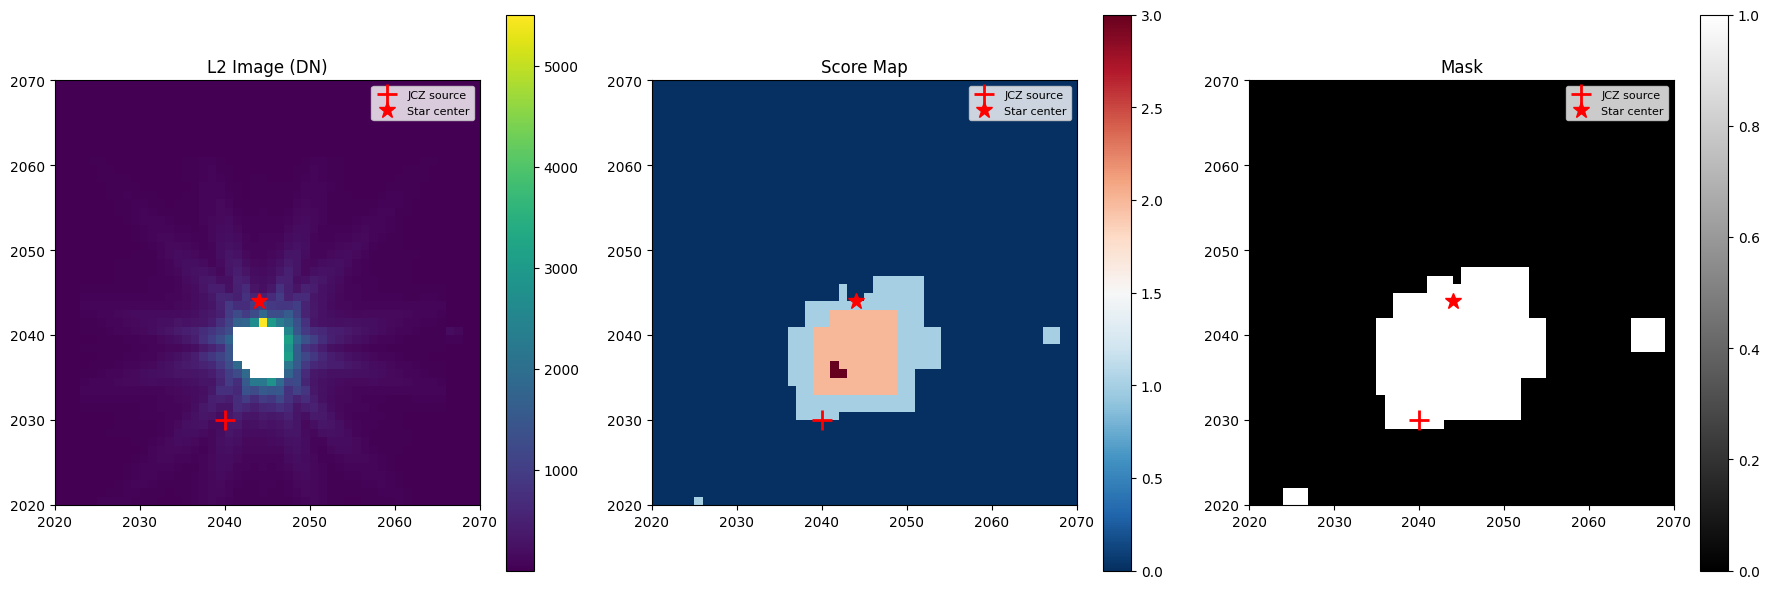

In [76]:
# Expose score and mask to notebook namespace for inspection
work_adu = np.asarray(l2_image, dtype=np.float64)
finite = np.isfinite(work_adu)
fill_value = float(np.median(work_adu[finite])) if finite.any() else 0.0
work_adu = np.where(finite, work_adu, fill_value)
work_e = work_adu * float(GAIN_E_PER_ADU)

score = detect_foreground_score_map(
    image_e=work_e, window_size=int(WINDOW_SIZE), k=float(K_SENSITIVITY),
    read_noise_e=float(READ_NOISE_E), n_exposures=1.0,
    use_numba=True,
)
mask = postprocess_mask(score, dilation_radius=int(DILATION_RADIUS))

# Inspect the region JCZ flagged
y_src, x_src = 2030, 2040
r = 10
print("L2 flux region:")
print(np.round(l2_image[y_src-r:y_src+r+1, x_src-r:x_src+r+1], 2))
print(f"\nScore at ({y_src},{x_src}): {score[y_src, x_src]:.4f}")
print(f"Mask at ({y_src},{x_src}): {mask[y_src, x_src]}")
print(f"\nScore map — region max: {score[y_src-r:y_src+r+1, x_src-r:x_src+r+1].max():.4f}")
print(f"Any masked pixels in region: {mask[y_src-r:y_src+r+1, x_src-r:x_src+r+1].any()}")

# Also visualize the score map over the full ensemble footprint
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

y0, y1 = 2020, 2070
x0, x1 = 2020, 2070

im0 = axes[0].imshow(l2_image[y0:y1, x0:x1], origin='lower',
                     extent=[x0, x1, y0, y1], cmap='viridis')
axes[0].set_title('L2 Image (DN)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(score[y0:y1, x0:x1], origin='lower',
                     extent=[x0, x1, y0, y1], cmap='RdBu_r')
axes[1].set_title('Score Map')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(mask[y0:y1, x0:x1], origin='lower',
                     extent=[x0, x1, y0, y1], cmap='gray')
axes[2].set_title('Mask')
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.plot(x_src, y_src, 'r+', markersize=15, markeredgewidth=2, label='JCZ source')
    ax.plot(2044, 2044, 'r*', markersize=12, label='Star center')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# ENSEMBLE PIXEL ANALYSIS - ALL RESULTANTS - Fractional Variation
# ============================================================================

print(f"\n{'='*80}")
print("ENSEMBLE PIXEL ANALYSIS - ALL RESULTANTS - FRACTIONAL VARIATION")
print(f"{'='*80}")

# Check if CSV files exist
missing_files = []
for resultant in range(len(RESULTANT_TIMES)):
    if not os.path.exists(MULTI_PIXEL_CSV_FILES[resultant]):
        missing_files.append(resultant)

if missing_files:
    print(f" Missing CSV files for resultants: {missing_files}")
else:
    print(" All 5 resultant CSV files found")
    
    # Load and process all resultants
    all_resultant_data = {}
    
    for resultant in range(len(RESULTANT_TIMES)):
        print(f"\n Processing Resultant {resultant} (t = {RESULTANT_TIMES[resultant]:.2f}s)...")
        
        # Load data
        df = pd.read_csv(MULTI_PIXEL_CSV_FILES[resultant])
        
        # Filter for PSF wing pixels only
        df_ensemble = df[df['pixel_name'].str.startswith('psf_wing_')]
        
        if len(df_ensemble) == 0:
            print(f"    No ensemble pixels found for resultant {resultant}")
            continue
            
        file_numbers = sorted(df_ensemble['file_number'].unique())
        pixels = df_ensemble['pixel_name'].unique()
        
        print(f"    {len(df_ensemble)} measurements, {len(pixels)} pixels, {len(file_numbers)} exposures")
        
        # Compute ensemble average for each file
        ensemble_results = []
        resultant_time = RESULTANT_TIMES[resultant]
        
        for file_num in file_numbers:
            df_file = df_ensemble[df_ensemble['file_number'] == file_num]
            
            # Get DN values
            dn_values = df_file['resultant_DN'].values
            
            # Filter valid values
            valid_mask = np.isfinite(dn_values) & (dn_values > 0)
            dn_valid = dn_values[valid_mask]
            
            if len(dn_valid) == 0:
                continue
            
            # Ensemble average
            mean_dn = np.mean(dn_valid)
            std_dn = np.std(dn_valid)
            
            # Convert to magnitude using correct exposure time
            dn_per_sec = mean_dn / resultant_time
            jy = dn_per_sec * photfnu
            mag = -2.5 * np.log10(jy) + ZERO_POINT_AB
            
            # Magnitude std from pixel scatter
            dn_per_sec_all = dn_valid / resultant_time
            jy_all = dn_per_sec_all * photfnu
            mag_all = -2.5 * np.log10(jy_all) + ZERO_POINT_AB
            std_mag = np.std(mag_all)
            
            ensemble_results.append({
                'file_number': file_num,
                'resultant': resultant,
                'exposure_time': resultant_time,
                'mean_DN': mean_dn,
                'std_DN': std_dn,
                'n_pixels': len(dn_valid),
                'magnitude': mag,
                'mag_std': std_mag
            })
        
        # Convert to DataFrame and store
        df_resultant = pd.DataFrame(ensemble_results)
        
        if len(df_resultant) > 0:
            # Compute fractional variation
            mean_mag = np.mean(df_resultant['magnitude'])
            df_resultant['delta_mag'] = df_resultant['magnitude'] - mean_mag
            rms_variation = np.sqrt(np.mean(df_resultant['delta_mag']**2))
            
            all_resultant_data[resultant] = {
                'data': df_resultant,
                'mean_mag': mean_mag,
                'rms_mmag': rms_variation * 1000,
                'exposure_time': resultant_time
            }
            
            print(f"    RMS = {rms_variation*1000:.2f} mmag, Mean = {mean_mag:.3f} mag")
        else:
            print(f"    No valid data for resultant {resultant}")
    
    if not all_resultant_data:
        print(" No valid data found for any resultant")
    else:
        # Create comprehensive plot
        n_resultants = len(all_resultant_data)
        fig, axes = plt.subplots(2, 4, figsize=(18, 12))
        axes = axes.flatten()
        
        colors = ['blue', 'green', 'red', 'purple', 'orange']
        
        # Plot each resultant
        for i, (resultant, data_dict) in enumerate(all_resultant_data.items()):
            df_data = data_dict['data']
            rms_mmag = data_dict['rms_mmag']
            mean_mag = data_dict['mean_mag']
            exp_time = data_dict['exposure_time']
            
            ax = axes[i]
            file_nums = df_data['file_number'].values
            delta_mag = df_data['delta_mag'].values
            
            # Fractional variation plot
            colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']
            
            ax.plot(file_nums, delta_mag * 1000, 'o-', color=colors[i], 
                   linewidth=2, markersize=3, alpha=0.7)
            ax.axhline(0, color='black', linestyle='--', linewidth=1)
            ax.fill_between(file_nums, -rms_mmag, rms_mmag, 
                          alpha=0.2, color=colors[i])
            
            ax.set_xlabel('File Number', fontsize=10, fontweight='bold')
            ax.set_ylabel('Δmag (mmag)', fontsize=10, fontweight='bold')
            ax.set_title(f'Resultant {resultant} (t={exp_time:.1f}s)\n' +
                        f'RMS = {rms_mmag:.2f} mmag',
                        fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
        
        # Summary comparison plot
        if len(all_resultant_data) > 1:
            ax = axes[6]  # Last subplot
            
            resultants = list(all_resultant_data.keys())
            rms_values = [all_resultant_data[r]['rms_mmag'] for r in resultants]
            exp_times = [all_resultant_data[r]['exposure_time'] for r in resultants]
            
            bars = ax.bar(resultants, rms_values, color=[colors[r] for r in resultants], alpha=0.7)
            ax.set_xlabel('Resultant Number', fontsize=10, fontweight='bold')
            ax.set_ylabel('RMS Variation (mmag)', fontsize=10, fontweight='bold')
            ax.set_title('RMS Comparison Across Resultants', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add exposure time labels on bars
            for i, (bar, exp_time) in enumerate(zip(bars, exp_times)):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{exp_time:.1f}s', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        
        # Save plot
        output_file = os.path.join(RESULTS_DIR, 'ensemble_fractional_variation_all_resultants.png')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"\n Saved: {output_file}")
        
        plt.show()
        
        # Create summary table
        summary_data = []
        for resultant, data_dict in all_resultant_data.items():
            df_data = data_dict['data']
            summary_data.append({
                'Resultant': resultant,
                'Exposure_Time_s': data_dict['exposure_time'],
                'Mean_Magnitude': data_dict['mean_mag'],
                'RMS_mmag': data_dict['rms_mmag'],
                'N_Exposures': len(df_data),
                'Mean_N_Pixels': np.mean(df_data['n_pixels'])
            })
        
        summary_df = pd.DataFrame(summary_data)
        
        # Save summary table
        summary_file = os.path.join(RESULTS_DIR, 'ensemble_analysis_all_resultants_summary.csv')
        summary_df.to_csv(summary_file, index=False)
        print(f" Saved summary: {summary_file}")
        
        # Print comprehensive statistics
        print("\n" + "="*80)
        print("ENSEMBLE ANALYSIS - ALL RESULTANTS SUMMARY")
        print("="*80)
        print(summary_df.to_string(index=False, float_format='%.3f'))
        print("="*80)
        
        # Find best precision resultant
        best_resultant = summary_df.loc[summary_df['RMS_mmag'].idxmin()]
        print(f"\n BEST PRECISION:")
        print(f"   Resultant {int(best_resultant['Resultant'])}: {best_resultant['RMS_mmag']:.2f} mmag")
        print(f"   Exposure time: {best_resultant['Exposure_Time_s']:.2f} seconds")
        
        # Save combined data for further analysis
        combined_df = pd.concat([data['data'] for data in all_resultant_data.values()], ignore_index=True)
        combined_file = os.path.join(RESULTS_DIR, 'ensemble_analysis_all_resultants_data.csv')
        combined_df.to_csv(combined_file, index=False)
        print(f" Saved combined data: {combined_file}")

print(f"{'='*80}")

#### Step : Flux Matrix Creation

In [38]:
"""
Flux Matrix Creator - ALL RESULTANTS with DISTANCE-ORDERED COLUMNS
Creates flux matrices for all 5 resultants with columns sorted by distance from star
"""
print("="*80)
print("CREATING FLUX MATRICES FOR ALL RESULTANTS - DISTANCE ORDERED COLUMNS")
print("="*80)

start_time = time.time()

def sort_pixels_by_distance_from_star(pixel_names, df_sample, star_y=source_y, star_x=source_x):
    """
    Sort pixel names by their distance from the star center.
    Returns pixel names sorted by distance (closest first).
    """
    print(" Sorting pixels by distance from star...")
    
    # Get pixel positions and calculate distances
    pixel_distances = []
    
    for pixel_name in pixel_names:
        # Get pixel position from the data
        pixel_row = df_sample[df_sample['pixel_name'] == pixel_name].iloc[0]
        y, x = pixel_row['pixel_y'], pixel_row['pixel_x']
        
        # Calculate distance from star
        distance = np.sqrt((y - star_y)**2 + (x - star_x)**2)
        
        pixel_distances.append({
            'name': pixel_name,
            'y': y,
            'x': x,
            'distance': distance
        })
    
    # Sort by distance (closest first)
    pixel_distances.sort(key=lambda p: p['distance'])
    
    # Extract sorted names
    sorted_names = [p['name'] for p in pixel_distances]
    
    print(f"    Sorted {len(sorted_names)} pixels by distance")
    print(f"    Closest: {pixel_distances[0]['name']} at {pixel_distances[0]['distance']:.1f}px")
    print(f"    Farthest: {pixel_distances[-1]['name']} at {pixel_distances[-1]['distance']:.1f}px")
    
    return sorted_names, pixel_distances

def process_resultant_with_distance_ordering(resultant):
    """Process a single resultant with distance-ordered columns."""
    input_csv = MULTI_PIXEL_CSV_FILES[resultant]
    resultant_time = RESULTANT_TIMES[resultant]
    
    print(f"\n Processing Resultant {resultant} (t = {resultant_time:.2f}s)...")
    
    if not os.path.exists(input_csv):
        print(f"    CSV file not found: {input_csv}")
        return None
    
    # Load data
    load_start = time.time()
    df = pd.read_csv(input_csv)
    load_time = time.time() - load_start
    print(f"Loaded {len(df):,} rows in {load_time:.1f}s")
    
    # Filter for PSF wing pixels only
    df_ensemble = df[df['pixel_name'].str.startswith('psf_wing_')].copy()
    
    # Remove duplicates
    n_before = len(df_ensemble)
    df_ensemble = df_ensemble.drop_duplicates(subset=['file_number', 'pixel_name'], keep='first')
    n_after = len(df_ensemble)
    if n_before != n_after:
        print(f"    Removed {n_before - n_after} duplicate entries")
    
    if len(df_ensemble) == 0:
        print(f"    No ensemble pixels found for resultant {resultant}")
        return None
    
    # Get file numbers and pixel names
    file_numbers = sorted(df_ensemble['file_number'].unique())
    pixel_names_unsorted = df_ensemble['pixel_name'].unique()
    
    print(f"{len(file_numbers)} exposures × {len(pixel_names_unsorted)} pixels")

    # JCZ commented out
    #  CRITICAL: Sort pixels by distance from star (closest first)
    # pixel_names_sorted, pixel_info = sort_pixels_by_distance_from_star(
    #     pixel_names_unsorted, df_ensemble
    # )
    
    # Convert DN to flux - vectorized operation
    conversion_start = time.time()
    df_ensemble['flux_jy'] = np.where(
        (df_ensemble['resultant_DN'].notna()) & (df_ensemble['resultant_DN'] > 0),
        (df_ensemble['resultant_DN'] / resultant_time) * photfnu,
        np.nan
    )
    conversion_time = time.time() - conversion_start
    print(f"    Converted {len(df_ensemble):,} values in {conversion_time:.2f}s")
    df_ensemble['pixel_name_alt'] = ["x{}y{}".format(x,y) for x, y in zip(df_ensemble['pixel_x'], df_ensemble['pixel_y'])]
    print(df_ensemble['pixel_name_alt'])
    # Create matrix using pivot
    pivot_start = time.time()
    flux_df = df_ensemble.pivot(
        index='file_number',
        columns='pixel_name_alt',  # JCZ changed to alt
        values='flux_jy'
    )
    # JCZ commented out
    #  CRITICAL: Reorder columns by distance (closest first)
    #flux_df = flux_df.reindex(columns=pixel_names_sorted)
    
    pivot_time = time.time() - pivot_start
    print(f"Created {flux_df.shape[0]} × {flux_df.shape[1]} matrix in {pivot_time:.2f}s")
    print(f"    Columns ordered by distance (closest to farthest)")
    
    # Reset index to make file_number a column
    flux_df = flux_df.reset_index()
    
    # Verify column ordering
    final_columns = flux_df.columns.tolist()[1:]  # Skip 'file_number'
    print(f"    First 5 columns: {[col[:15] for col in final_columns[:5]]}")
    print(f"    Last 5 columns: {[col[:15] for col in final_columns[-5:]]}")
    
    # Save with distance-ordered columns
    output_file = os.path.join(RESULTS_DIR, f'flux_matrix_resultant{resultant}_MAG_{MAG:.2f}.csv')
    save_start = time.time()
    flux_df.to_csv(output_file, index=False)
    save_time = time.time() - save_start
    print(f"    Saved: {os.path.basename(output_file)} in {save_time:.2f}s")
 
    # Calculate statistics
    flux_matrix = flux_df.drop(columns=['file_number']).values
    n_valid = np.sum(np.isfinite(flux_matrix))
    n_total = flux_matrix.size
    pct_valid = n_valid / n_total * 100
    
    result_stats = {
        'resultant': resultant,
        'exposure_time': resultant_time,
        'shape': flux_matrix.shape,
        'n_valid': n_valid,
        'n_total': n_total,
        'pct_valid': pct_valid,
        'flux_min': np.nanmin(flux_matrix),
        'flux_max': np.nanmax(flux_matrix),
        'flux_median': np.nanmedian(flux_matrix),
        'output_file': output_file,
        'processing_time': time.time() - load_start,
    }
    
    print(f"    {pct_valid:.1f}% valid data")
    
    return result_stats

# Check if all CSV files exist
missing_files = []
for resultant in range(len(RESULTANT_TIMES)):
    if not os.path.exists(MULTI_PIXEL_CSV_FILES[resultant]):
        missing_files.append(resultant)

print(len(PIXELS_TO_TRACK))
if missing_files:
    print(f" Missing CSV files for resultants: {missing_files}")
else:
    print(" All resultant CSV files found")
    
    # Process all resultants with distance ordering
    print(f"\n Processing all resultants with distance-ordered columns...")
    all_results = []
    
    for resultant in range(len(RESULTANT_TIMES)):
        print(resultant)
        result = process_resultant_with_distance_ordering(resultant)
        if result:
            all_results.append(result)
    
    if not all_results:
        print(" No valid results from any resultant")
    else:
        print(f"\n Successfully processed {len(all_results)} resultants")
        
        # Create comprehensive summary
        print("\n" + "="*80)
        print("DISTANCE-ORDERED FLUX MATRIX STATISTICS")
        print("="*80)
        
        summary_rows = []
        for result in all_results:
            summary_rows.append({
                'Resultant': result['resultant'],
                'Exp_Time_s': result['exposure_time'],
                'Shape': f"{result['shape'][0]}×{result['shape'][1]}",
                'Valid_%': f"{result['pct_valid']:.1f}%", 
                'Flux_Range': f"{result['flux_min']:.1e} - {result['flux_max']:.1e} Jy",
                'Time_s': f"{result['processing_time']:.1f}s"
            })
        
        summary_df = pd.DataFrame(summary_rows)
        print(summary_df.to_string(index=False))
        
        # Save summary table
        summary_file = os.path.join(RESULTS_DIR, f'flux_matrix_distance_ordered_summary_MAG_{MAG:.2f}.csv')
        summary_df.to_csv(summary_file, index=False)
        print(f"\n Summary: {summary_file}")
     
        print(f"\n SUCCESS! All flux matrices have distance-ordered columns")
        print(f"\n USAGE EXAMPLES:")
        print(f"   # Load any resultant")
        print(f"   df = pd.read_csv('flux_matrix_distance_ordered_resultant0_MAG_{MAG:.2f}.csv')")
        print(f"   # Get 50 closest pixels: df.iloc[:, 1:51]")
        print(f"   # Get single closest pixel: df.iloc[:, 1]")
        print(f"   # Get background pixels: df.iloc[:, -20:]")
        
        print("="*80)


CREATING FLUX MATRICES FOR ALL RESULTANTS - DISTANCE ORDERED COLUMNS
1681
 All resultant CSV files found

 Processing all resultants with distance-ordered columns...
0

 Processing Resultant 0 (t = 3.16s)...
Loaded 5,043 rows in 0.0s
3 exposures × 1681 pixels
    Converted 5,043 values in 0.00s
0       x2024y2024
1       x2025y2024
2       x2026y2024
3       x2027y2024
4       x2028y2024
           ...    
5038    x2060y2064
5039    x2061y2064
5040    x2062y2064
5041    x2063y2064
5042    x2064y2064
Name: pixel_name_alt, Length: 5043, dtype: str
Created 3 × 1681 matrix in 0.00s
    Columns ordered by distance (closest to farthest)
    First 5 columns: ['x2024y2024', 'x2024y2025', 'x2024y2026', 'x2024y2027', 'x2024y2028']
    Last 5 columns: ['x2064y2060', 'x2064y2061', 'x2064y2062', 'x2064y2063', 'x2064y2064']
    Saved: flux_matrix_resultant0_MAG_13.00.csv in 0.05s
    99.7% valid data
1

 Processing Resultant 1 (t = 6.32s)...
Loaded 5,043 rows in 0.0s
3 exposures × 1681 pixels
    Co

In [39]:
import pandas as pd
import numpy as np
print("="*80)
print("RMS DIAGNOSTIC CHECK")
print("="*80)
# Load CSV
df = pd.read_csv(f'./{MAGNITUDE_FOLDER}/analysis_results/multi_pixel_resultant1_unsat.csv')
# TEST 1: Data dimensions
print("\nTEST 1: Data dimensions")
print(f"  Total rows: {len(df):,}")
print(f"  Unique pixels: {len(df['pixel_name'].unique())}")
print(f"  Unique files: {len(df['file_number'].unique())}")
# TEST 2: Single pixel RMS (CRITICAL TEST!)
print("\nTEST 2: Single pixel RMS")
first_pixel = df['pixel_name'].iloc[0]
df_pixel = df[df['pixel_name'] == first_pixel]
flux = df_pixel['resultant_DN'].values / RESULTANT0_TIME * photfnu
mag = -2.5 * np.log10(flux) + 8.9
rms_single = np.std(mag) * 1000
print(f"  Pixel: {first_pixel}")
print(f"  RMS: {rms_single:.1f} mmag")
print(f"  Expected: 50-100 mmag")
if rms_single < 10:
    print("  WARNING: Too low! Something wrong!")
elif 50 <= rms_single <= 150:
    print("  CORRECT: Within expected range")
# TEST 3: Ensemble RMS (manual calculation)
print("\nTEST 3: Ensemble RMS (manual calculation)")
ensemble_mags = []
for file_num in sorted(df['file_number'].unique()):
    df_file = df[df['file_number'] == file_num]
    flux = df_file['resultant_DN'].values / RESULTANT0_TIME * photfnu
    valid = np.isfinite(flux)
    if np.sum(valid) > 0:
        mag = -2.5 * np.log10(flux[valid]) + 8.9
        ensemble_mags.append(np.mean(mag))
rms_ensemble = np.std(ensemble_mags) * 1000
print(f"  Ensemble RMS: {rms_ensemble:.2f} mmag")
print(f"  Your plot shows: 2.09 mmag")
if abs(rms_ensemble - 2.09) < 0.5:
    print(" MATCHES!")
else:
    print("  MISMATCH!")
# TEST 4: Noise reduction check
n_pixels = len(df['pixel_name'].unique())
expected_ensemble = rms_single / np.sqrt(n_pixels)
print(f"\nTEST 4: Expected vs Actual")
print(f"  Single pixel: {rms_single:.1f} mmag")
print(f"  N pixels: {n_pixels}")
print(f"  Expected: {expected_ensemble:.2f} mmag")
print(f"  Actual: {rms_ensemble:.2f} mmag")
print(f"  Ratio: {rms_ensemble/expected_ensemble:.2f} (should be ~1.0)")

RMS DIAGNOSTIC CHECK

TEST 1: Data dimensions
  Total rows: 5,043
  Unique pixels: 1681
  Unique files: 3

TEST 2: Single pixel RMS
  Pixel: psf_wing_000000
  RMS: 0.9 mmag
  Expected: 50-100 mmag

TEST 3: Ensemble RMS (manual calculation)
  Ensemble RMS: nan mmag
  Your plot shows: 2.09 mmag
  MISMATCH!

TEST 4: Expected vs Actual
  Single pixel: 0.9 mmag
  N pixels: 1681
  Expected: 0.02 mmag
  Actual: nan mmag
  Ratio: nan (should be ~1.0)


/tmp/ipykernel_544/3242848046.py:35: RuntimeWarning: divide by zero encountered in log10
  mag = -2.5 * np.log10(flux[valid]) + 8.9
/opt/conda/envs/RomanNexus-2026.1/lib/python3.12/site-packages/numpy/_core/_methods.py:188: RuntimeWarning: invalid value encountered in subtract
  x = um.subtract(arr, arrmean, out=...)
